In [16]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import correlate, correlation_lags
from skimage.metrics import structural_similarity as ssim
import os, sys
import torch
less_path = os.path.abspath(os.path.join("..", "LESS_ver_alpha"))
if less_path not in sys.path:
    sys.path.insert(0, less_path)
from less import denoise

import pandas as pd
import scipy as sp
import h5py
import cv2

from ipywidgets import HBox, VBox, IntSlider, Dropdown, Play, jslink, HTML

from skimage.draw import polygon2mask
from skimage.measure import find_contours

from scipy.signal import butter, sosfiltfilt
from matplotlib.ticker import MultipleLocator

# Plot 1: PSNR, SSIM & LFD Pre- and Post-Denoising on Synthetic Movie

In [17]:
def _to_THW(mov: np.ndarray) -> np.ndarray:
    """
    Ensure movie has shape (T, H, W).
    Accepts either (T, H, W) or (H, W, T).
    """
    if mov.ndim != 3:
        raise ValueError("Movie must be a 3D array.")
    # If first dim looks like H and last looks like T, move axis
    # (This is a conservative heuristic. If you always use (T,H,W), it will do nothing.)
    if mov.shape[0] != mov.shape[-1] and mov.shape[0] in (mov.shape[1], mov.shape[2]):
        # ambiguous, do nothing
        return mov
    # If last axis is clearly time-like (often much larger than H/W), move it
    if mov.shape[-1] > mov.shape[0] and mov.shape[-1] > mov.shape[1]:
        return np.moveaxis(mov, -1, 0)
    return mov


def mse_frame(a: np.ndarray, b: np.ndarray) -> float:
    """Mean squared error for 2D frames."""
    a = a.astype(np.float64, copy=False)
    b = b.astype(np.float64, copy=False)
    return float(np.mean((a - b) ** 2))


def psnr_frame(clean: np.ndarray, test: np.ndarray, data_range: float) -> float:
    """PSNR for one 2D frame."""
    m = mse_frame(clean, test)
    if m == 0:
        return np.inf
    return 10.0 * np.log10((data_range ** 2) / m)


def per_frame_psnr_ssim(
    clean_mov: np.ndarray,
    test_mov: np.ndarray,
    data_range: float,
) -> tuple[np.ndarray, np.ndarray]:
    """
    Compute PSNR and SSIM per frame, returning arrays of length T.

    clean_mov, test_mov: movies with shape (T, H, W) (preferred).
    data_range: range for PSNR/SSIM (for normalized movies, typically 1.0).
    """
    clean_mov = _to_THW(clean_mov)
    test_mov = _to_THW(test_mov)

    if clean_mov.shape != test_mov.shape:
        raise ValueError(f"Shape mismatch: clean {clean_mov.shape} vs test {test_mov.shape}")

    T = clean_mov.shape[0]
    psnr_t = np.empty(T, dtype=float)
    ssim_t = np.empty(T, dtype=float)

    for t in range(T):
        c = clean_mov[t]
        x = test_mov[t]
        psnr_t[t] = psnr_frame(c, x, data_range=data_range)
        ssim_t[t] = ssim(c, x, data_range=data_range)

    return psnr_t, ssim_t


def lfd_frame(clean: np.ndarray, test: np.ndarray) -> float:
    """
    Logarithmic Frequency Distance (LFD) for one 2D frame.

    We interpret S as an image and compare their power spectra:
      P = |FFT2(S)|^2

    LFD = log10( (1/HW) * sum_{u,v} |P_test(u,v) - P_clean(u,v)|^2 + 1 )

    The +1 ensures the log argument is >= 1.
    """
    # FFTs
    F_clean = np.fft.fft2(clean.astype(np.float64, copy=False))
    F_test  = np.fft.fft2(test.astype(np.float64, copy=False))

    diff2_mean = np.mean(np.abs(F_test - F_clean) ** 2)
    lfd = np.log10(diff2_mean + 1.0)
    
    return lfd 


def per_frame_lfd(clean_mov: np.ndarray, test_mov: np.ndarray) -> np.ndarray:
    """
    Compute LFD per frame, returning array of length T.
    Movies must be shape (T,H,W).
    """
    clean_mov = _to_THW(clean_mov)
    test_mov = _to_THW(test_mov)

    if clean_mov.shape != test_mov.shape:
        raise ValueError(f"Shape mismatch: clean {clean_mov.shape} vs test {test_mov.shape}")

    T = clean_mov.shape[0]
    lfd_t = np.empty(T, dtype=float)
    for t in range(T):
        lfd_t[t] = lfd_frame(clean_mov[t], test_mov[t])
    return lfd_t


def mean_and_sem(x: np.ndarray) -> tuple[float, float]:
    """
    Mean and standard error of the mean.
    """
    x = np.asarray(x, dtype=float)
    mu = float(np.mean(x))
    if x.size <= 1:
        return mu, 0.0
    sem = float(np.std(x, ddof=1) / np.sqrt(x.size))
    return mu, sem


def add_noise_gaussian(clean_mov: np.ndarray, sigma: float, rng: np.random.Generator) -> np.ndarray:
    """
    Add i.i.d. Gaussian noise with std = sigma.
    """
    return clean_mov + rng.normal(0.0, sigma, size=clean_mov.shape)


def run_input_output_metric_sweep(
    clean_mov: np.ndarray,
    sigmas: list[float],
    denoise_fn,
    *,
    rng_seed: int = 0,
    data_range: float | None = None,
    clip: tuple[float, float] | None = None,
    include_noise_recovery: bool = True,
) -> dict:
    """
    Sweep over noise levels and compute:

    Signal reconstruction metrics:
      - input vs clean
      - output vs clean

    Optional noise-recovery metrics:
      - residual noise (noisy - denoised) vs true injected noise (noisy - clean)

    Returns mean ± SEM across frames for each sigma.
    """
    clean_mov = _to_THW(clean_mov)

    # For signal metrics
    if data_range is None:
        lo = float(np.percentile(clean_mov, 0.1))
        hi = float(np.percentile(clean_mov, 99.9))
        data_range = max(hi - lo, 1e-12)

    rng = np.random.default_rng(rng_seed)

    results = {
        "sigmas": np.array(sigmas, dtype=float),

        # Signal reconstruction metrics
        "psnr_in_mean": [], "psnr_out_mean": [],
        "psnr_in_sem":  [], "psnr_out_sem":  [],

        "ssim_in_mean": [], "ssim_out_mean": [],
        "ssim_in_sem":  [], "ssim_out_sem":  [],

        "lfd_in_mean":  [], "lfd_out_mean":  [],
        "lfd_in_sem":   [], "lfd_out_sem":   [],
    }

    if include_noise_recovery:
        results.update({
            # Noise recovery metrics: compare residual noise to true noise
            "noise_psnr_mean": [],
            "noise_psnr_sem":  [],
            "noise_ssim_mean": [],
            "noise_ssim_sem":  [],
            "noise_lfd_mean":  [],
            "noise_lfd_sem":   [],
            "noise_data_range_used": [],
        })

    for sigma in sigmas:
        noisy = add_noise_gaussian(clean_mov, sigma, rng=rng)
        if clip is not None:
            noisy = np.clip(noisy, clip[0], clip[1])

        den = denoise_fn(noisy)
        if clip is not None:
            den = np.clip(den, clip[0], clip[1])

        # -----------------------------
        # Signal reconstruction metrics
        # -----------------------------
        psnr_in_t, ssim_in_t = per_frame_psnr_ssim(
            clean_mov, noisy, data_range=data_range
        )
        psnr_out_t, ssim_out_t = per_frame_psnr_ssim(
            clean_mov, den, data_range=data_range
        )

        lfd_in_t = per_frame_lfd(clean_mov, noisy)
        lfd_out_t = per_frame_lfd(clean_mov, den)

        mu, se = mean_and_sem(psnr_in_t)
        results["psnr_in_mean"].append(mu)
        results["psnr_in_sem"].append(se)

        mu, se = mean_and_sem(psnr_out_t)
        results["psnr_out_mean"].append(mu)
        results["psnr_out_sem"].append(se)

        mu, se = mean_and_sem(ssim_in_t)
        results["ssim_in_mean"].append(mu)
        results["ssim_in_sem"].append(se)

        mu, se = mean_and_sem(ssim_out_t)
        results["ssim_out_mean"].append(mu)
        results["ssim_out_sem"].append(se)

        mu, se = mean_and_sem(lfd_in_t)
        results["lfd_in_mean"].append(mu)
        results["lfd_in_sem"].append(se)

        mu, se = mean_and_sem(lfd_out_t)
        results["lfd_out_mean"].append(mu)
        results["lfd_out_sem"].append(se)

        # -----------------------------
        # Noise recovery metrics
        # -----------------------------
        if include_noise_recovery:
            noise_metrics = per_frame_noise_recovery_metrics(
                clean_mov,
                noisy,
                den,
                data_range=None,  # compute from true-noise range for each sigma
            )

            mu, se = mean_and_sem(noise_metrics["psnr_t"])
            results["noise_psnr_mean"].append(mu)
            results["noise_psnr_sem"].append(se)

            mu, se = mean_and_sem(noise_metrics["ssim_t"])
            results["noise_ssim_mean"].append(mu)
            results["noise_ssim_sem"].append(se)

            mu, se = mean_and_sem(noise_metrics["lfd_t"])
            results["noise_lfd_mean"].append(mu)
            results["noise_lfd_sem"].append(se)

            results["noise_data_range_used"].append(noise_metrics["data_range_used"])

    # Convert lists to arrays
    for k, v in list(results.items()):
        if isinstance(v, list):
            results[k] = np.array(v, dtype=float)

    results["data_range_used"] = float(data_range)
    results["rng_seed"] = int(rng_seed)
    results["clip_used"] = clip
    results["include_noise_recovery"] = bool(include_noise_recovery)

    return results


def compute_true_and_residual_noise(
    clean_mov: np.ndarray,
    noisy_mov: np.ndarray,
    denoised_mov: np.ndarray,
) -> tuple[np.ndarray, np.ndarray]:
    """
    Compute:
      - true injected noise      = noisy - clean
      - estimated removed noise  = noisy - denoised

    All movies must have the same shape (T, H, W) or be convertible via _to_THW.
    """
    clean_mov = _to_THW(clean_mov)
    noisy_mov = _to_THW(noisy_mov)
    denoised_mov = _to_THW(denoised_mov)

    if not (clean_mov.shape == noisy_mov.shape == denoised_mov.shape):
        raise ValueError(
            f"Shape mismatch: clean {clean_mov.shape}, noisy {noisy_mov.shape}, "
            f"denoised {denoised_mov.shape}"
        )

    true_noise = noisy_mov - clean_mov
    residual_noise = noisy_mov - denoised_mov

    return true_noise, residual_noise


def per_frame_noise_recovery_metrics(
    clean_mov: np.ndarray,
    noisy_mov: np.ndarray,
    denoised_mov: np.ndarray,
    *,
    data_range: float | None = None,
) -> dict[str, np.ndarray]:
    """
    Compare residual noise (noisy - denoised) to true noise (noisy - clean)
    using per-frame PSNR, SSIM, and LFD.

    Returns
    -------
    dict with keys:
        'true_noise'
        'residual_noise'
        'psnr_t'
        'ssim_t'
        'lfd_t'
        'data_range_used'
    """
    true_noise, residual_noise = compute_true_and_residual_noise(
        clean_mov, noisy_mov, denoised_mov
    )

    if data_range is None:
        lo = float(np.percentile(true_noise, 0.1))
        hi = float(np.percentile(true_noise, 99.9))
        data_range = max(hi - lo, 1e-12)

    psnr_t, ssim_t = per_frame_psnr_ssim(
        true_noise,
        residual_noise,
        data_range=data_range,
    )
    lfd_t = per_frame_lfd(true_noise, residual_noise)

    return {
        "true_noise": true_noise,
        "residual_noise": residual_noise,
        "psnr_t": psnr_t,
        "ssim_t": ssim_t,
        "lfd_t": lfd_t,
        "data_range_used": float(data_range),
    }


def plot_raw_and_denoised_input_vs_output(
    results: dict,
    *,
    title: str | None = None,
    label_raw: str = "Raw data",
    label_denoised: str = "LESS",
    connect_pairs: bool = True,
    connector_color: str = "0.75",
    connector_alpha: float = 0.8,
    connector_lw: float = 0.9,
    diag_ls: str = "--",
    diag_lw: float = 1.0,
    diag_alpha: float = 0.45,   # more transparent
):
    """
    Three-panel plot:
      1) PSNR: input vs output
      2) SSIM: input vs output
      3) LFD:  input vs output

    Style:
      - Raw points at (x, x)
      - Denoised points at (x, y)
      - Vertical dashed connectors (lighter grey)
      - Diagonal y=x dashed blue line drawn only over the x-range of the points
      - No error bars
    """
    fig, axes = plt.subplots(1, 3, figsize=(14, 4), constrained_layout=True)

    def _panel(ax, x_mean, y_mean, xlabel, ylabel):
        x_mean = np.asarray(x_mean, dtype=float)
        y_mean = np.asarray(y_mean, dtype=float)

        # Diagonal y=x reference line, only across the x-range of the points
        x0 = float(np.nanmin(x_mean))
        x1 = float(np.nanmax(x_mean))
        ax.plot([x0, x1], [x0, x1],
                color='mediumpurple', linestyle=diag_ls, linewidth=diag_lw, alpha=diag_alpha, zorder=1)

        # Raw points lie on y=x
        ax.plot(x_mean, x_mean, "o", label=label_raw, zorder=3, color='mediumpurple')

        # Denoised points
        ax.plot(x_mean, y_mean, "o", label=label_denoised, zorder=4, color='mediumseagreen')

        # Vertical dashed connectors
        if connect_pairs:
            for i in range(len(x_mean)):
                ax.plot(
                    [x_mean[i], x_mean[i]],
                    [x_mean[i], y_mean[i]],
                    linestyle="--",
                    linewidth=connector_lw,
                    color=connector_color,
                    alpha=connector_alpha,
                    zorder=2,
                )

        ax.set_xlabel(xlabel)
        ax.set_ylabel(ylabel)
        ax.grid(True, alpha=0.3)

    # PSNR
    _panel(
        axes[0],
        x_mean=results["psnr_in_mean"],
        y_mean=results["psnr_out_mean"],
        xlabel="Input PSNR (dB)",
        ylabel="Output PSNR (dB)",
    )

    # SSIM
    _panel(
        axes[1],
        x_mean=results["ssim_in_mean"],
        y_mean=results["ssim_out_mean"],
        xlabel="Input SSIM",
        ylabel="Output SSIM",
    )

    # LFD
    _panel(
        axes[2],
        x_mean=results["lfd_in_mean"],
        y_mean=results["lfd_out_mean"],
        xlabel="Input LFD",
        ylabel="Output LFD",
    )

    axes[2].legend(frameon=True)

    if title is not None:
        fig.suptitle(title)

    return fig, axes


def plot_validation_3panel(results: dict, title: str | None = None):
    """
    3-panel validation plot:
      - PSNR, SSIM, LFD: input (x) vs output (y)
      - Raw data plotted at (x, x) in cornflowerblue
      - Denoised data plotted at (x, y) in tomato
      - Light grey dashed vertical arrows from raw to denoised
      - Dashed y=x line in cornflowerblue, drawn only over x-range of points
      - No error bars
    """
    # Hardcoded style choices
    RAW_COLOR = "mediumpurple"
    DENOISED_COLOR = "mediumseagreen"
    CONNECTOR_COLOR = "0.75"   # light grey
    CONNECTOR_LW = 0.9
    CONNECTOR_ALPHA = 0.8
    DIAG_ALPHA = 0.35
    MARKER_SIZE = 6
    SHRINK_B_PTS = 4

    fig, axes = plt.subplots(1, 3, figsize=(14, 4), constrained_layout=True)

    def _panel(ax, x, y, xlabel, ylabel):
        x = np.asarray(x, dtype=float)
        y = np.asarray(y, dtype=float)

        # y=x reference line (only over x-range of points)
        x0 = float(np.nanmin(x))
        x1 = float(np.nanmax(x))
        ax.plot([x0, x1], [x0, x1], linestyle="--", linewidth=1.0,
                color=RAW_COLOR, alpha=DIAG_ALPHA, zorder=1)

        # Vertical dashed arrows: from raw (x, x) to denoised (x, y)
        for i in range(len(x)):
            ax.annotate(
                "",
                xy=(x[i], y[i]),        # arrow head at denoised point
                xytext=(x[i], x[i]),    # tail at raw point
                arrowprops=dict(
                    arrowstyle="-|>",
                    linestyle="--",
                    linewidth=CONNECTOR_LW,
                    color=CONNECTOR_COLOR,
                    alpha=CONNECTOR_ALPHA,
                    shrinkA=0,
                    shrinkB=SHRINK_B_PTS,
                    mutation_scale=10,   # arrowhead size
                ),
                zorder=2,
            )

        # Raw points (x, x)
        ax.plot(x, x, "o", color=RAW_COLOR, markersize=MARKER_SIZE, label="Raw Data", zorder=3)

        # Denoised points (x, y)
        ax.plot(x, y, "o", color=DENOISED_COLOR, markersize=MARKER_SIZE, label="LESS Denoised", zorder=4)

        ax.set_xlabel(xlabel)
        ax.set_ylabel(ylabel)
        ax.grid(True, alpha=0.3)

    # Panel 1: PSNR
    _panel(
        axes[0],
        x=results["psnr_in_mean"],
        y=results["psnr_out_mean"],
        xlabel="Input PSNR (dB)",
        ylabel="Output PSNR (dB)",
    )

    # Panel 2: SSIM
    _panel(
        axes[1],
        x=results["ssim_in_mean"],
        y=results["ssim_out_mean"],
        xlabel="Input SSIM",
        ylabel="Output SSIM",
    )

    # Panel 3: LFD
    _panel(
        axes[2],
        x=results["lfd_in_mean"],
        y=results["lfd_out_mean"],
        xlabel="Input LFD",
        ylabel="Output LFD",
    )

    # Legend on first panel
    axes[0].legend(frameon=True)

    if title is not None:
        fig.suptitle(title)

    return fig, axes


def plot_noise_recovery_3panel(results: dict, title: str | None = None):
    """
    Plot how well the residual noise matches the true injected noise
    as a function of input noise sigma.

    Panels:
      1) Noise PSNR
      2) Noise SSIM
      3) Noise LFD

    x-axis is input noise sigma.
    """
    if "noise_psnr_mean" not in results:
        raise ValueError("results does not contain noise recovery metrics.")

    sigmas = np.asarray(results["sigmas"], dtype=float)

    fig, axes = plt.subplots(1, 3, figsize=(14, 4), constrained_layout=True)

    # PSNR
    axes[0].plot(sigmas, results["noise_psnr_mean"], "o-", color="mediumseagreen")
    axes[0].set_xlabel("Input noise std")
    axes[0].set_ylabel("Residual-vs-True Noise PSNR (dB)")
    axes[0].grid(True, alpha=0.3)

    # SSIM
    axes[1].plot(sigmas, results["noise_ssim_mean"], "o-", color="mediumseagreen")
    axes[1].set_xlabel("Input noise std")
    axes[1].set_ylabel("Residual-vs-True Noise SSIM")
    axes[1].grid(True, alpha=0.3)

    # LFD
    axes[2].plot(sigmas, results["noise_lfd_mean"], "o-", color="mediumseagreen")
    axes[2].set_xlabel("Input noise std")
    axes[2].set_ylabel("Residual-vs-True Noise LFD")
    axes[2].grid(True, alpha=0.3)

    if title is not None:
        fig.suptitle(title)

    return fig, axes


def run_less_denoising(movie_np: np.ndarray,
                           patch_size: int = 16,
                           top_k: int = 18,
                           window_size: int = 37,
                           stride: int = 4,
                           pat: int = 5,
                           seed: int = 42,
                           verbose: bool = False) -> np.ndarray:
    """
    Run LESS denoising on a NumPy movie array.

    Parameters:
        movie_np (np.ndarray): Input movie of shape (T, H, W)
        patch_size (int): Patch size
        top_k (int): Number of best-matching patches
        window_size (int): Search window size
        stride (int): Stride for patch selection
        pat (int): Temporal patch size (number of adjacent frames)
        seed (int): Random seed
        verbose (bool): Whether to print progress

    Returns:
        np.ndarray: Denoised movie of shape (T, H, W)
    """
    assert movie_np.ndim == 3, "Input movie must have shape (T, H, W)"

    movie_tensor = torch.from_numpy(movie_np).float()

    denoised_tensor = denoise(
        data=movie_tensor,
        cuda=False,               # Force CPU
        patch_size=patch_size,
        top_k=top_k,
        window_size=window_size,
        stride=stride,
        pat=pat,
        verbose=verbose
    )

    return denoised_tensor.numpy()


def make_mock_movie(
    T: int = 150,
    H: int = 128,
    W: int = 128,
    fps: float = 100.0,
    wave_freq_hz: float = 2.0,
    wave_speed_px_per_s: float = 80.0,
    wave_angle_deg: float = 35.0,
    bump_freq_hz: float = 25.0,
    bump_sigma_px: float = 20.0,
    bump_amp: float = 1.00,
    wave_amp: float = 0.25,
    drift_amp: float = 0.20,
    rng_seed: int = 0,
) -> np.ndarray:
    """
    Create a synthetic "signal-like" movie (T,H,W), normalized to [0,1].

    Components:
      1) Traveling plane wave (low frequency)
      2) Localized oscillatory Gaussian bump (e.g. gamma-like)
      3) Slow global drift 

    Returns
    -------
    clean_mov : np.ndarray, shape (T,H,W), float32, in [0,1]
    """
    rng = np.random.default_rng(rng_seed)

    # Space grids (centered)
    yy, xx = np.mgrid[0:H, 0:W].astype(np.float32)
    yy = yy - (H - 1) / 2.0
    xx = xx - (W - 1) / 2.0

    # Unit direction for plane wave propagation
    theta = np.deg2rad(wave_angle_deg)
    kx = np.cos(theta)
    ky = np.sin(theta)

    # Convert wave speed to phase advance per frame
    # Plane wave: sin(2π f t - 2π * (distance traveled) / wavelength)
    # We can define an effective spatial wavelength from speed and frequency: lambda = v / f
    lam = wave_speed_px_per_s / max(wave_freq_hz, 1e-6)
    spatial_phase = 2.0 * np.pi * (kx * xx + ky * yy) / max(lam, 1e-6)

    # Local bump center (slightly off-center)
    cx = 0#W - (W - 1) / 2.0
    cy = 0#H - (H - 1) / 2.0
    r2 = (xx - cx) ** 2 + (yy - cy) ** 2
    bump_profile = np.exp(-0.5 * r2 / (bump_sigma_px ** 2)).astype(np.float32)

    # Mild static shading (like illumination / vasculature-ish low frequency)
    #shading = 0.15 * (xx / (W / 2.0)) + 0.10 * (yy / (H / 2.0))
    #shading += 0.05 * np.sin(2 * np.pi * (xx / (W * 0.9)))
    #shading = shading.astype(np.float32)

    # Time vector
    t = (np.arange(T, dtype=np.float32) / fps)

    # Build movie
    mov = np.empty((T, H, W), dtype=np.float32)

    # Randomize bump phase a bit so it is not perfectly aligned to wave
    bump_phase0 = float(rng.uniform(0, 2 * np.pi))

    for i in range(T):
        # Traveling plane wave
        wave = wave_amp * np.sin(2.0 * np.pi * wave_freq_hz * t[i] - spatial_phase)

        # Localized high frequency oscillation
        bump = bump_amp * bump_profile * np.sin(2.0 * np.pi * bump_freq_hz * t[i] + bump_phase0)

        # Slow global drift
        drift = drift_amp * np.sin(2.0 * np.pi * 0.15 * t[i])

        frame = wave + bump + drift #+ shading
        mov[i] = frame

    # Normalize to [0,1] robustly (avoid outliers dominating scaling)
    lo = np.percentile(mov, 0.5)
    hi = np.percentile(mov, 99.5)
    mov = (mov - lo) / max(hi - lo, 1e-12)
    mov = np.clip(mov, 0.0, 1.0).astype(np.float32)

    return mov

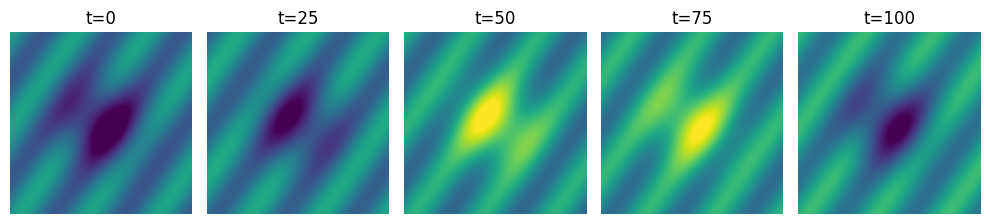

In [18]:
clean_mov = make_mock_movie(T=150, H=128, W=128, fps=100)

plt.figure(figsize=(10, 3))
for j, tt in enumerate([0, 25, 50, 75, 100]):
    ax = plt.subplot(1, 5, j + 1)
    ax.imshow(clean_mov[tt], vmin=0, vmax=1)
    ax.set_title(f"t={tt}")
    ax.axis("off")
plt.tight_layout()
plt.show()

In [229]:
sigmas = [0.02, 0.04, 0.06, 0.08, 0.10, 0.2, 0.4, 0.8]#, 1.0]

results = run_input_output_metric_sweep(
    clean_mov=clean_mov,
    sigmas=sigmas,
    denoise_fn=run_less_denoising,
    rng_seed=0,
    data_range=1.0,
    clip=(0.0, 1.0),
)

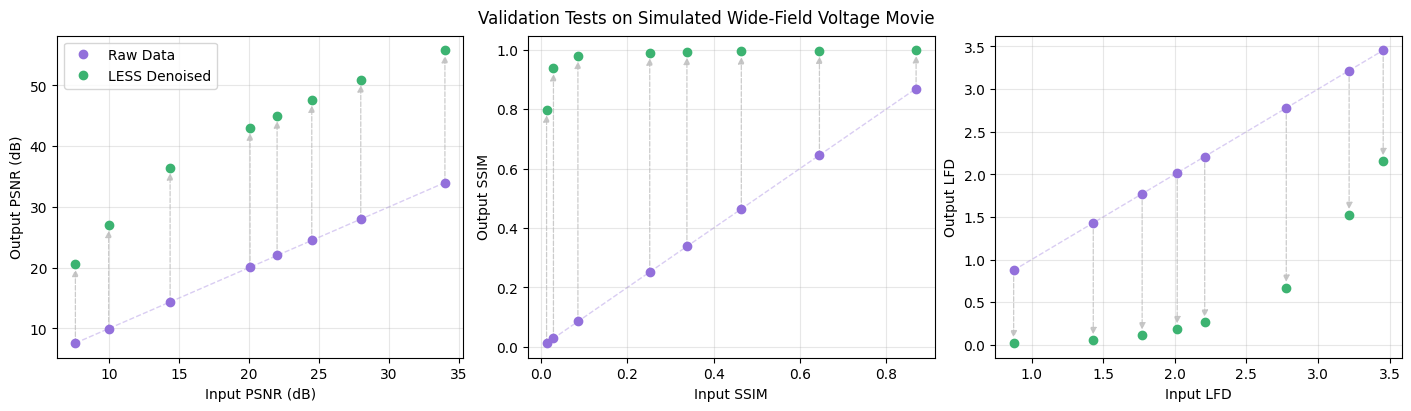

In [234]:
fig, axes = plot_validation_3panel(results, title="Validation Tests on Simulated Wide-Field Voltage Movie")
plt.show()

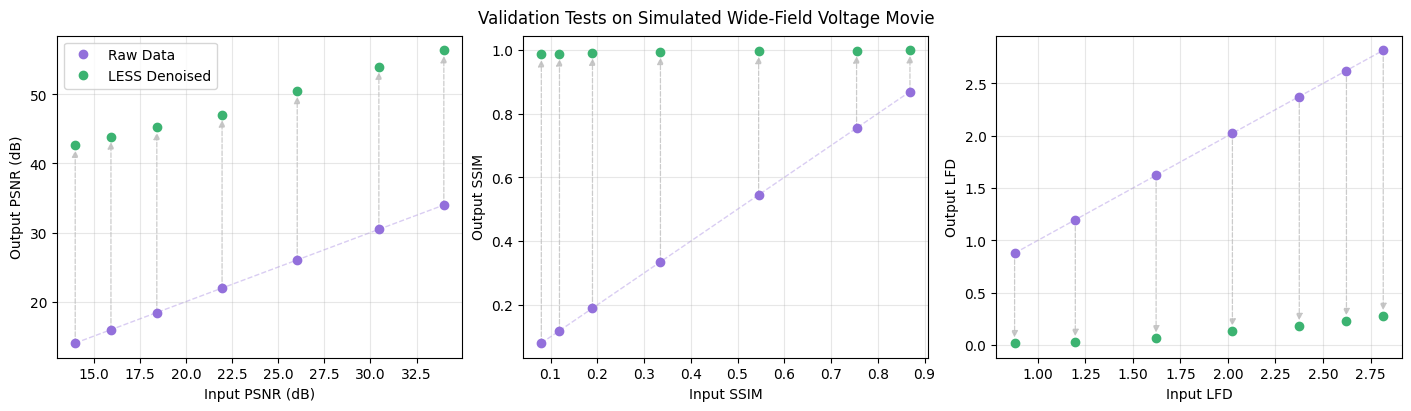

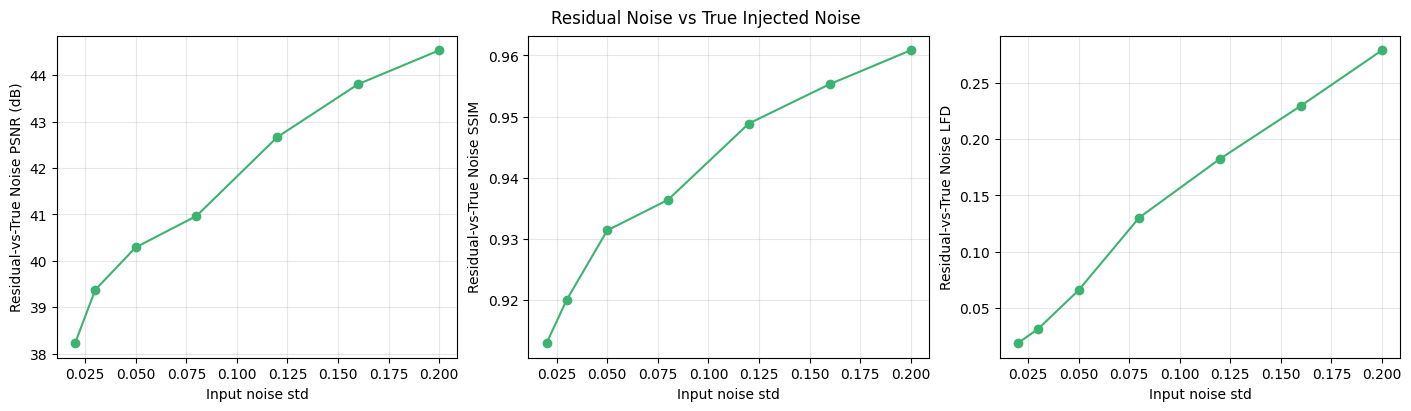

In [4]:
clean_mov = make_mock_movie(T=150, H=128, W=128, fps=100)

sigmas = [0.02, 0.03, 0.05, 0.08, 0.12, 0.16, 0.20]

results = run_input_output_metric_sweep(
    clean_mov=clean_mov,
    sigmas=sigmas,
    denoise_fn=run_less_denoising,
    rng_seed=0,
    include_noise_recovery=True,
)

fig1, axes1 = plot_validation_3panel(
    results,
    title="Validation Tests on Simulated Wide-Field Voltage Movie",
)

fig2, axes2 = plot_noise_recovery_3panel(
    results,
    title="Residual Noise vs True Injected Noise",
)

In [19]:
def mse_movie(a: np.ndarray, b: np.ndarray) -> float:
    """
    Mean squared error over an entire movie.
    Movies must have the same shape.
    """
    a = _to_THW(a).astype(np.float64, copy=False)
    b = _to_THW(b).astype(np.float64, copy=False)

    if a.shape != b.shape:
        raise ValueError(f"Shape mismatch: {a.shape} vs {b.shape}")

    return float(np.mean((a - b) ** 2))


def per_frame_mse(clean_mov: np.ndarray, test_mov: np.ndarray) -> np.ndarray:
    """
    Per-frame MSE between two movies.
    Returns array of length T.
    """
    clean_mov = _to_THW(clean_mov).astype(np.float64, copy=False)
    test_mov = _to_THW(test_mov).astype(np.float64, copy=False)

    if clean_mov.shape != test_mov.shape:
        raise ValueError(f"Shape mismatch: {clean_mov.shape} vs {test_mov.shape}")

    return np.mean((clean_mov - test_mov) ** 2, axis=(1, 2))


def run_noise_tracking_sweep(
    clean_mov: np.ndarray,
    sigmas: list[float],
    denoise_fn,
    *,
    rng_seed: int = 0,
    clip: tuple[float, float] | None = None,
) -> dict:
    """
    Sweep over input Gaussian noise levels and quantify:

    1) removed-vs-true noise MSE
       true_noise   = noisy - clean
       removed_noise = noisy - denoised

    2) leftover noise MSE
       leftover_noise = denoised - clean

    Returns mean ± SEM across frames for each sigma.
    """
    clean_mov = _to_THW(clean_mov)
    rng = np.random.default_rng(rng_seed)

    results = {
        "sigmas": np.array(sigmas, dtype=float),

        # How accurately the removed component matches the true noise
        "removed_vs_true_mse_mean": [],
        "removed_vs_true_mse_sem": [],

        # How much noise/artifact remains in the denoised movie
        "leftover_mse_mean": [],
        "leftover_mse_sem": [],

        # Optional helpful reference: input noise power
        "true_noise_mse_mean": [],
        "true_noise_mse_sem": [],
    }

    for sigma in sigmas:
        noisy = add_noise_gaussian(clean_mov, sigma, rng=rng)
        if clip is not None:
            noisy = np.clip(noisy, clip[0], clip[1])

        den = denoise_fn(noisy)
        if clip is not None:
            den = np.clip(den, clip[0], clip[1])

        true_noise = noisy - clean_mov
        removed_noise = noisy - den
        leftover_noise = den - clean_mov

        removed_vs_true_mse_t = per_frame_mse(true_noise, removed_noise)
        leftover_mse_t = np.mean(leftover_noise.astype(np.float64) ** 2, axis=(1, 2))
        true_noise_mse_t = np.mean(true_noise.astype(np.float64) ** 2, axis=(1, 2))

        mu, se = mean_and_sem(removed_vs_true_mse_t)
        results["removed_vs_true_mse_mean"].append(mu)
        results["removed_vs_true_mse_sem"].append(se)

        mu, se = mean_and_sem(leftover_mse_t)
        results["leftover_mse_mean"].append(mu)
        results["leftover_mse_sem"].append(se)

        mu, se = mean_and_sem(true_noise_mse_t)
        results["true_noise_mse_mean"].append(mu)
        results["true_noise_mse_sem"].append(se)

    for k, v in list(results.items()):
        if isinstance(v, list):
            results[k] = np.array(v, dtype=float)

    results["rng_seed"] = int(rng_seed)
    results["clip_used"] = clip
    return results


def plot_noise_tracking_mse(
    results: dict,
    *,
    title: str | None = None,
    show_leftover: bool = True,
    show_true_noise_reference: bool = False,
):
    """
    Plot MSE vs input noise level.

    Main curve:
      removed_vs_true_mse_mean
        Measures how closely LESS removed the actual injected noise.

    Optional curve:
      leftover_mse_mean
        Measures how much error/noise remains in the denoised movie.

    Optional reference:
      true_noise_mse_mean
        Average power of the injected noise itself.
    """
    sigmas = np.asarray(results["sigmas"], dtype=float)

    fig, ax = plt.subplots(figsize=(6, 4), constrained_layout=True)

    ax.plot(
        sigmas,
        results["removed_vs_true_mse_mean"],
        "o-",
        color="mediumseagreen",
        label="MSE: removed noise vs true noise",
    )

    if show_leftover:
        ax.plot(
            sigmas,
            results["leftover_mse_mean"],
            "o-",
            color="mediumpurple",
            label="MSE: denoised movie vs clean movie",
        )

    if show_true_noise_reference:
        ax.plot(
            sigmas,
            results["true_noise_mse_mean"],
            "--",
            color="0.5",
            label="Injected noise power",
        )

    ax.set_xlabel("Input noise std")
    ax.set_ylabel("Mean squared error")
    ax.grid(True, alpha=0.3)
    ax.legend(frameon=True)

    if title is not None:
        ax.set_title(title)

    return fig, ax


def per_frame_mean_power(movie: np.ndarray) -> np.ndarray:
    """
    Per-frame mean squared value, i.e. average power per frame.

    Parameters
    ----------
    movie : np.ndarray
        Movie of shape (T, H, W) or convertible via _to_THW.

    Returns
    -------
    power_t : np.ndarray
        Array of length T containing mean(movie[t]**2).
    """
    movie = _to_THW(movie).astype(np.float64, copy=False)
    return np.mean(movie**2, axis=(1, 2))


def per_frame_fraction_noise_remaining(
    clean_mov: np.ndarray,
    noisy_mov: np.ndarray,
    denoised_mov: np.ndarray,
    eps: float = 1e-12,
) -> np.ndarray:
    """
    Compute the per-frame fraction of injected noise power that remains
    after denoising.

    fraction_t = mean((denoised - clean)^2) / mean((noisy - clean)^2)

    Parameters
    ----------
    clean_mov : np.ndarray
        Clean ground-truth movie.
    noisy_mov : np.ndarray
        Noisy input movie.
    denoised_mov : np.ndarray
        Denoised output movie.
    eps : float
        Small constant to avoid divide-by-zero.

    Returns
    -------
    frac_t : np.ndarray
        Array of length T. Lower is better.
    """
    clean_mov = _to_THW(clean_mov).astype(np.float64, copy=False)
    noisy_mov = _to_THW(noisy_mov).astype(np.float64, copy=False)
    denoised_mov = _to_THW(denoised_mov).astype(np.float64, copy=False)

    if not (clean_mov.shape == noisy_mov.shape == denoised_mov.shape):
        raise ValueError(
            f"Shape mismatch: clean {clean_mov.shape}, "
            f"noisy {noisy_mov.shape}, denoised {denoised_mov.shape}"
        )

    true_noise = noisy_mov - clean_mov
    leftover_noise = denoised_mov - clean_mov

    true_noise_power_t = per_frame_mean_power(true_noise)
    leftover_noise_power_t = per_frame_mean_power(leftover_noise)

    frac_t = leftover_noise_power_t / np.maximum(true_noise_power_t, eps)
    return frac_t

def run_fraction_noise_remaining_sweep(
    clean_mov: np.ndarray,
    sigmas: list[float],
    denoise_fn,
    *,
    rng_seed: int = 0,
    clip: tuple[float, float] | None = None,
) -> dict:
    """
    Sweep over input noise levels and compute the fraction of injected
    noise power remaining after denoising.

    For each sigma:
        true_noise     = noisy - clean
        leftover_noise = denoised - clean

        fraction remaining =
            mean((leftover_noise)^2) / mean((true_noise)^2)

    Returns mean ± SEM across frames.
    """
    clean_mov = _to_THW(clean_mov)
    rng = np.random.default_rng(rng_seed)

    results = {
        "sigmas": np.array(sigmas, dtype=float),
        "fraction_remaining_mean": [],
        "fraction_remaining_sem": [],
        "true_noise_power_mean": [],
        "true_noise_power_sem": [],
        "leftover_noise_power_mean": [],
        "leftover_noise_power_sem": [],
    }

    for sigma in sigmas:
        noisy = add_noise_gaussian(clean_mov, sigma, rng=rng)
        if clip is not None:
            noisy = np.clip(noisy, clip[0], clip[1])

        den = denoise_fn(noisy)
        if clip is not None:
            den = np.clip(den, clip[0], clip[1])

        true_noise = noisy - clean_mov
        leftover_noise = den - clean_mov

        frac_t = per_frame_fraction_noise_remaining(clean_mov, noisy, den)
        true_noise_power_t = per_frame_mean_power(true_noise)
        leftover_noise_power_t = per_frame_mean_power(leftover_noise)

        mu, se = mean_and_sem(frac_t)
        results["fraction_remaining_mean"].append(mu)
        results["fraction_remaining_sem"].append(se)

        mu, se = mean_and_sem(true_noise_power_t)
        results["true_noise_power_mean"].append(mu)
        results["true_noise_power_sem"].append(se)

        mu, se = mean_and_sem(leftover_noise_power_t)
        results["leftover_noise_power_mean"].append(mu)
        results["leftover_noise_power_sem"].append(se)

    for k, v in list(results.items()):
        if isinstance(v, list):
            results[k] = np.array(v, dtype=float)

    results["rng_seed"] = int(rng_seed)
    results["clip_used"] = clip
    return results


def plot_fraction_noise_remaining(
    results: dict,
    *,
    title: str | None = None,
    color: str = "mediumseagreen",
    add_one_line: bool = True,
):
    """
    Plot fraction of noise remaining vs input noise std.

    y = 1  : no denoising
    y = 0  : perfect denoising
    lower is better
    """
    sigmas = np.asarray(results["sigmas"], dtype=float)
    frac_mean = np.asarray(results["fraction_remaining_mean"], dtype=float)
    frac_sem = np.asarray(results["fraction_remaining_sem"], dtype=float)

    fig, ax = plt.subplots(figsize=(6, 4), constrained_layout=True)

    ax.plot(sigmas, frac_mean, "o-", color=color, label="Fraction of noise remaining")
    ax.fill_between(sigmas, frac_mean - frac_sem, frac_mean + frac_sem,
                    color=color, alpha=0.2)

    if add_one_line:
        ax.axhline(1.0, linestyle="--", color="0.5", alpha=0.7, linewidth=1.0,
                   label="No denoising")

    ax.set_xlabel("Input noise std")
    ax.set_ylabel("Fraction of noise remaining")
    ax.grid(True, alpha=0.3)
    ax.legend(frameon=True)

    if title is not None:
        ax.set_title(title)

    return fig, ax


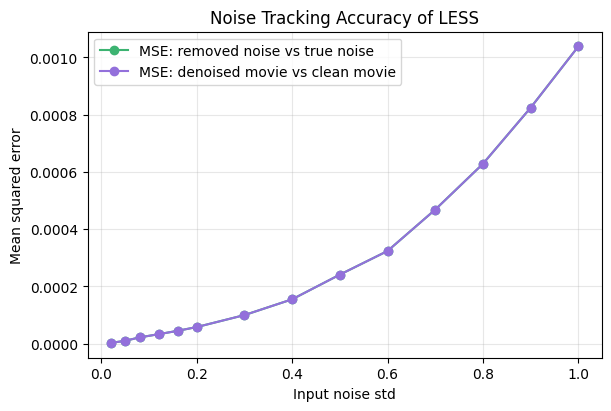

In [6]:
clean_mov = make_mock_movie(T=150, H=128, W=128, fps=100)

noise_results = run_noise_tracking_sweep(
    clean_mov=clean_mov,
    sigmas=[0.02, 0.05, 0.08, 0.12, 0.16, 0.20, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1],
    denoise_fn=run_less_denoising,
    rng_seed=0,
)

fig, ax = plot_noise_tracking_mse(
    noise_results,
    title="Noise Tracking Accuracy of LESS",
    show_leftover=True,
    show_true_noise_reference=False,
)

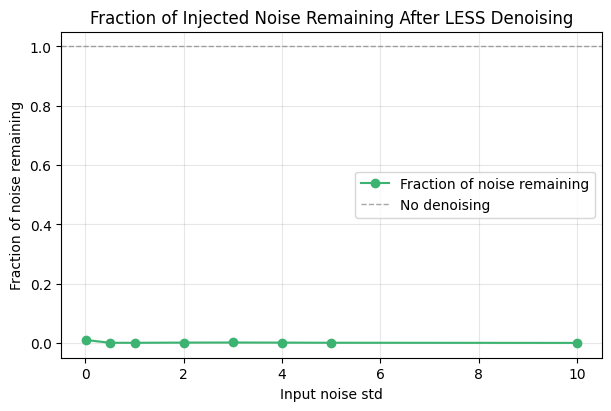

In [11]:
clean_mov = make_mock_movie(T=150, H=128, W=128, fps=100)

sigmas = [0.01, 0.5, 1, 2, 3, 4, 5, 10]

frac_results = run_fraction_noise_remaining_sweep(
    clean_mov=clean_mov,
    sigmas=sigmas,
    denoise_fn=run_less_denoising,
    rng_seed=0,
)

fig, ax = plot_fraction_noise_remaining(
    frac_results,
    title="Fraction of Injected Noise Remaining After LESS Denoising",
)

# Validating on Wave Parameter Accuracy

In [20]:
def make_plane_wave_movie(
    T=150,
    H=96,
    W=96,
    fps=100.0,
    speed_px_per_s=80.0,
    direction_deg=35.0,
    freq_hz=4.0,
    amplitude=1.0,
    baseline=0.0,
    phase0=0.0,
    envelope_center_s=None,
    envelope_sigma_s=0.35,
):
    """
    Generate a synthetic plane-wave movie of shape (T, H, W).

    Signal model:
        V(x, y, t) = envelope(t) * sin(2π f t - k·r + phase0)

    with |k| chosen so that wave speed = f * wavelength.

    Parameters
    ----------
    speed_px_per_s : float
        True propagation speed.
    direction_deg : float
        True propagation direction in degrees, measured from +x toward +y.
    freq_hz : float
        Temporal frequency.
    envelope_center_s : float or None
        Center of temporal Gaussian envelope. If None, use middle of movie.
    envelope_sigma_s : float
        Temporal width of envelope in seconds.
    """
    yy, xx = np.mgrid[0:H, 0:W].astype(float)
    t = np.arange(T, dtype=float) / fps

    if envelope_center_s is None:
        envelope_center_s = 0.5 * (T - 1) / fps

    # Wave direction unit vector
    theta = np.deg2rad(direction_deg)
    ux = np.cos(theta)
    uy = np.sin(theta)

    # Spatial wavelength from v = f * lambda
    wavelength_px = speed_px_per_s / freq_hz
    k_mag = 2.0 * np.pi / wavelength_px

    spatial_phase = k_mag * (ux * xx + uy * yy)

    envelope = np.exp(-0.5 * ((t - envelope_center_s) / envelope_sigma_s) ** 2)

    mov = np.empty((T, H, W), dtype=np.float32)
    for i, ti in enumerate(t):
        mov[i] = baseline + amplitude * envelope[i] * np.sin(2.0 * np.pi * freq_hz * ti - spatial_phase + phase0)

    return mov

def add_gaussian_noise(movie, sigma, rng):
    """Add i.i.d. Gaussian noise."""
    return movie + rng.normal(0.0, sigma, size=movie.shape)

def normalized_xcorr_1d(x, y, max_lag):
    """
    Compute normalized cross-correlation between two 1D traces over a bounded lag window.

    Returns
    -------
    lags : np.ndarray
        Integer lags in samples.
    xcorr_norm : np.ndarray
        Normalized cross-correlation values at those lags.

    Notes
    -----
    We standardize both traces first, then compute full correlation and divide by length.
    This is a practical normalized cross-correlation implementation for equal-length traces.
    """
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    x = x - np.mean(x)
    y = y - np.mean(y)

    sx = np.std(x)
    sy = np.std(y)

    if sx < 1e-12 or sy < 1e-12:
        lags = np.arange(-max_lag, max_lag + 1)
        return lags, np.full_like(lags, np.nan, dtype=float)

    xz = x / sx
    yz = y / sy

    corr_full = correlate(yz, xz, mode="full", method="auto") / len(xz)
    lags_full = correlation_lags(len(yz), len(xz), mode="full")

    keep = (lags_full >= -max_lag) & (lags_full <= max_lag)
    return lags_full[keep], corr_full[keep]

def estimate_delay_and_corr_maps(movie, seed_xy=None, max_lag=15):
    """
    Estimate, for every pixel, the lag of maximum normalized cross-correlation
    relative to a seed pixel.

    Parameters
    ----------
    movie : np.ndarray
        Shape (T, H, W)
    seed_xy : tuple[int, int] or None
        Seed pixel as (x, y). If None, use center pixel.
    max_lag : int
        Maximum lag (in frames) to search in either direction.

    Returns
    -------
    lag_map_frames : np.ndarray, shape (H, W)
        Lag (frames) at which correlation is maximal.
    peak_corr_map : np.ndarray, shape (H, W)
        Peak normalized cross-correlation value.
    seed_xy : tuple[int, int]
        Actual seed used.
    """
    T, H, W = movie.shape

    if seed_xy is None:
        seed_xy = (W // 2, H // 2)

    seed_x, seed_y = seed_xy
    seed_trace = movie[:, seed_y, seed_x]

    lag_map_frames = np.full((H, W), np.nan, dtype=float)
    peak_corr_map = np.full((H, W), np.nan, dtype=float)

    for y in range(H):
        for x in range(W):
            trace = movie[:, y, x]
            lags, xcorr_norm = normalized_xcorr_1d(seed_trace, trace, max_lag=max_lag)

            if np.all(np.isnan(xcorr_norm)):
                continue

            idx = np.nanargmax(xcorr_norm)
            lag_map_frames[y, x] = lags[idx]
            peak_corr_map[y, x] = xcorr_norm[idx]

    return lag_map_frames, peak_corr_map, seed_xy

def fit_delay_plane(delay_map_s, peak_corr_map, xmin=0.7):
    """
    Fit tau(x, y) = A x + B y + C using only pixels with peak_corr > xmin.

    Parameters
    ----------
    delay_map_s : np.ndarray, shape (H, W)
        Delay map in seconds.
    peak_corr_map : np.ndarray, shape (H, W)
        Peak cross-correlation map.
    xmin : float
        Correlation threshold.

    Returns
    -------
    fit : dict
        Contains A, B, C, valid_mask, n_valid, success
    """
    H, W = delay_map_s.shape
    yy, xx = np.mgrid[0:H, 0:W].astype(float)

    valid = np.isfinite(delay_map_s) & np.isfinite(peak_corr_map) & (peak_corr_map > xmin)

    if np.count_nonzero(valid) < 3:
        return {
            "A": np.nan,
            "B": np.nan,
            "C": np.nan,
            "valid_mask": valid,
            "n_valid": int(np.count_nonzero(valid)),
            "success": False,
        }

    X = np.column_stack([
        xx[valid].ravel(),
        yy[valid].ravel(),
        np.ones(np.count_nonzero(valid)),
    ])
    y = delay_map_s[valid].ravel()

    coeffs, *_ = np.linalg.lstsq(X, y, rcond=None)
    A, B, C = coeffs

    return {
        "A": float(A),
        "B": float(B),
        "C": float(C),
        "valid_mask": valid,
        "n_valid": int(np.count_nonzero(valid)),
        "success": True,
    }

def velocity_from_plane_fit(A, B):
    """
    Convert plane-fit coefficients into estimated speed and direction.

    Returns
    -------
    speed_px_per_s : float
    direction_deg : float
        Angle of gradient vector [A, B], in degrees from +x toward +y.
    """
    grad_mag = np.sqrt(A**2 + B**2)
    if not np.isfinite(grad_mag) or grad_mag < 1e-12:
        return np.nan, np.nan

    speed = 1.0 / grad_mag
    direction_deg = np.rad2deg(np.arctan2(B, A)) % 360.0
    return float(speed), float(direction_deg)

def angular_error_deg(est_deg, true_deg):
    """
    Smallest angular difference between two directions, in [0, 180].
    """
    d = abs((est_deg - true_deg) % 360.0)
    return min(d, 360.0 - d)

def angular_error_mod180_deg(est_deg, true_deg):
    """
    Direction error with 180-degree sign ambiguity removed, in [0, 90].
    """
    d = angular_error_deg(est_deg, true_deg)
    return min(d, abs(180.0 - d))

def estimate_wave_velocity_from_movie(
    movie,
    fps,
    seed_xy=None,
    max_lag=15,
    xmin=0.7,
):
    """
    Full paper-style estimation pipeline on one movie.

    Returns
    -------
    result : dict
        Includes lag map, peak corr map, plane fit, speed, direction, etc.
    """
    lag_map_frames, peak_corr_map, seed_xy = estimate_delay_and_corr_maps(
        movie, seed_xy=seed_xy, max_lag=max_lag
    )

    delay_map_s = lag_map_frames / fps

    fit = fit_delay_plane(delay_map_s, peak_corr_map, xmin=xmin)

    if not fit["success"]:
        return {
            "success": False,
            "seed_xy": seed_xy,
            "lag_map_frames": lag_map_frames,
            "delay_map_s": delay_map_s,
            "peak_corr_map": peak_corr_map,
            "A": np.nan,
            "B": np.nan,
            "C": np.nan,
            "speed_px_per_s": np.nan,
            "direction_deg": np.nan,
            "n_valid": fit["n_valid"],
            "valid_mask": fit["valid_mask"],
        }

    speed, direction = velocity_from_plane_fit(fit["A"], fit["B"])

    return {
        "success": True,
        "seed_xy": seed_xy,
        "lag_map_frames": lag_map_frames,
        "delay_map_s": delay_map_s,
        "peak_corr_map": peak_corr_map,
        "A": fit["A"],
        "B": fit["B"],
        "C": fit["C"],
        "speed_px_per_s": speed,
        "direction_deg": direction,
        "n_valid": fit["n_valid"],
        "valid_mask": fit["valid_mask"],
    }

def mean_and_sem(x):
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    if len(x) == 0:
        return np.nan, np.nan
    if len(x) == 1:
        return float(np.mean(x)), 0.0
    return float(np.mean(x)), float(np.std(x, ddof=1) / np.sqrt(len(x)))

def run_wave_recovery_sweep(
    sigmas,
    n_movies_per_sigma=3,
    show_clean=False,
    rng_seed=0,
    *,
    T=150,
    H=96,
    W=96,
    fps=100.0,
    speed_px_per_s=80.0,
    direction_deg=35.0,
    freq_hz=4.0,
    amplitude=1.0,
    max_lag=15,
    xmin=0.7,
):
    """
    Run the wave-speed/direction recovery experiment over noise levels.

    Returns
    -------
    results : dict
        Aggregated means/SEMs plus per-movie raw records.
    """
    rng = np.random.default_rng(rng_seed)

    results = {
        "sigmas": np.asarray(sigmas, dtype=float),
        "show_clean": bool(show_clean),

        # Relative speed error (%)
        "raw_speed_rel_err_mean": [], "raw_speed_rel_err_sem": [],
        "less_speed_rel_err_mean": [], "less_speed_rel_err_sem": [],
        "clean_speed_rel_err_mean": [], "clean_speed_rel_err_sem": [],

        # Absolute speed error (px/s)
        "raw_speed_abs_err_mean": [], "raw_speed_abs_err_sem": [],
        "less_speed_abs_err_mean": [], "less_speed_abs_err_sem": [],
        "clean_speed_abs_err_mean": [], "clean_speed_abs_err_sem": [],

        # Direction error (mod 180, deg)
        "raw_dir_err_mean": [], "raw_dir_err_sem": [],
        "less_dir_err_mean": [], "less_dir_err_sem": [],
        "clean_dir_err_mean": [], "clean_dir_err_sem": [],

        # Debug/support
        "raw_valid_frac_mean": [], "less_valid_frac_mean": [], "clean_valid_frac_mean": [],
        "records": [],
    }

    for sigma in sigmas:
        raw_speed_rel_errs = []
        less_speed_rel_errs = []
        clean_speed_rel_errs = []

        raw_speed_abs_errs = []
        less_speed_abs_errs = []
        clean_speed_abs_errs = []

        raw_dir_errs = []
        less_dir_errs = []
        clean_dir_errs = []

        raw_valid_fracs = []
        less_valid_fracs = []
        clean_valid_fracs = []

        for m in range(n_movies_per_sigma):
            phase0 = rng.uniform(0, 2 * np.pi)

            clean_movie = make_plane_wave_pulse_movie(
                T=T, H=H, W=W, fps=fps,
                speed_px_per_s=speed_px_per_s,
                direction_deg=direction_deg,
                freq_hz=freq_hz,
                amplitude=amplitude
            )

            noisy_movie = add_gaussian_noise(clean_movie, sigma=sigma, rng=rng)

            # LESS
            less_movie = run_less_denoising(noisy_movie.astype(np.float32))

            # Estimate on raw / less / clean
            raw_est = estimate_wave_velocity_from_movie(
                noisy_movie, fps=fps, seed_xy=None, max_lag=max_lag, xmin=xmin
            )
            less_est = estimate_wave_velocity_from_movie(
                less_movie, fps=fps, seed_xy=None, max_lag=max_lag, xmin=xmin
            )

            clean_est = None
            if show_clean:
                clean_est = estimate_wave_velocity_from_movie(
                    clean_movie, fps=fps, seed_xy=None, max_lag=max_lag, xmin=xmin
                )

            # Helper for collecting errors
            def collect(est, speed_abs_list, speed_rel_list, dir_list, valid_list):
                if est is None or not est["success"] or not np.isfinite(est["speed_px_per_s"]):
                    speed_abs_list.append(np.nan)
                    speed_rel_list.append(np.nan)
                    dir_list.append(np.nan)
                    valid_list.append(np.nan)
                    return

                speed_abs_err = abs(est["speed_px_per_s"] - speed_px_per_s)
                speed_rel_err = 100.0 * speed_abs_err / speed_px_per_s

                # Main plotted direction metric: modulo-180 angular error
                dir_err = angular_error_mod180_deg(est["direction_deg"], direction_deg)

                valid_frac = est["n_valid"] / (H * W)

                speed_abs_list.append(speed_abs_err)
                speed_rel_list.append(speed_rel_err)
                dir_list.append(dir_err)
                valid_list.append(valid_frac)

            collect(raw_est, raw_speed_abs_errs, raw_speed_rel_errs, raw_dir_errs, raw_valid_fracs)
            collect(less_est, less_speed_abs_errs, less_speed_rel_errs, less_dir_errs, less_valid_fracs)
            if show_clean:
                collect(clean_est, clean_speed_abs_errs, clean_speed_rel_errs, clean_dir_errs, clean_valid_fracs)

            results["records"].append({
                "sigma": sigma,
                "movie_index": m,
                "true_speed_px_per_s": speed_px_per_s,
                "true_direction_deg": direction_deg,
                "raw_est": raw_est,
                "less_est": less_est,
                "clean_est": clean_est,
            })

        # Aggregate this sigma
        for prefix, vals in [
            ("raw_speed_rel_err", raw_speed_rel_errs),
            ("less_speed_rel_err", less_speed_rel_errs),
            ("clean_speed_rel_err", clean_speed_rel_errs),

            ("raw_speed_abs_err", raw_speed_abs_errs),
            ("less_speed_abs_err", less_speed_abs_errs),
            ("clean_speed_abs_err", clean_speed_abs_errs),

            ("raw_dir_err", raw_dir_errs),
            ("less_dir_err", less_dir_errs),
            ("clean_dir_err", clean_dir_errs),
        ]:
            mu, se = mean_and_sem(vals)
            results[f"{prefix}_mean"].append(mu)
            results[f"{prefix}_sem"].append(se)

        results["raw_valid_frac_mean"].append(np.nanmean(raw_valid_fracs) if len(raw_valid_fracs) else np.nan)
        results["less_valid_frac_mean"].append(np.nanmean(less_valid_fracs) if len(less_valid_fracs) else np.nan)
        results["clean_valid_frac_mean"].append(np.nanmean(clean_valid_fracs) if len(clean_valid_fracs) else np.nan)

    # Convert lists to arrays where appropriate
    for k, v in list(results.items()):
        if isinstance(v, list) and k != "records":
            results[k] = np.asarray(v, dtype=float)

    return results

def plot_wave_recovery_results(results, show_clean=False, title=None):
    """
    Plot:
      - direction error (deg) vs noise std
      - relative speed error (%) vs noise std

    Curves:
      - Raw
      - LESS
      - optional Clean
    """
    fig, axes = plt.subplots(1, 2, figsize=(10, 4), constrained_layout=True)

    raw_color = "mediumpurple"
    less_color = "mediumseagreen"
    clean_color = "black"

    sigmas = results["sigmas"]

    # Panel 1: direction error
    ax = axes[0]
    ax.plot(sigmas, results["raw_dir_err_mean"], "o-", color=raw_color, label="Raw data")
    ax.plot(sigmas, results["less_dir_err_mean"], "o-", color=less_color, label="LESS")
    if show_clean:
        ax.plot(sigmas, results["clean_dir_err_mean"], "o--", fillstyle='none', color=clean_color, lw=0.8, label="Clean")

    ax.set_xlabel("Noise std")
    ax.set_ylabel("Direction error (deg)")
    ax.grid(True, alpha=0.3)

    # Panel 2: relative speed error
    ax = axes[1]
    ax.plot(sigmas, results["raw_speed_rel_err_mean"], "o-", color=raw_color, label="Raw data")
    ax.plot(sigmas, results["less_speed_rel_err_mean"], "o-", color=less_color, label="LESS")
    if show_clean:
        ax.plot(sigmas, results["clean_speed_rel_err_mean"], "o--", color=clean_color, fillstyle='none', lw=0.8, label="Clean")

    ax.set_xlabel("Noise std")
    ax.set_ylabel("Relative speed error (%)")
    ax.set_yscale("log")
    ax.grid(True, alpha=0.3)
    
    axes[0].legend(frameon=True)

    if title is not None:
        fig.suptitle(title)

    return fig, axes

def make_plane_wave_pulse_movie(
    T=150,
    H=96,
    W=96,
    fps=100.0,
    speed_px_per_s=80.0,
    direction_deg=35.0,
    freq_hz=4.0,
    amplitude=1.0,
    t0_s=0.75,
    sigma_t_s=0.18,
    seed_xy=None,
):
    yy, xx = np.mgrid[0:H, 0:W].astype(float)

    if seed_xy is None:
        seed_xy = (W // 2, H // 2)

    seed_x, seed_y = seed_xy

    # Coordinates relative to seed
    xx_rel = xx - seed_x
    yy_rel = yy - seed_y

    t = np.arange(T, dtype=float) / fps

    theta = np.deg2rad(direction_deg)
    ux = np.cos(theta)
    uy = np.sin(theta)

    tau = (ux * xx_rel + uy * yy_rel) / speed_px_per_s

    mov = np.empty((T, H, W), dtype=np.float32)
    for i, ti in enumerate(t):
        tt = ti - tau - t0_s
        mov[i] = amplitude * np.exp(-0.5 * (tt / sigma_t_s) ** 2) * np.sin(2.0 * np.pi * freq_hz * tt)

    return mov



In [104]:
sigmas = [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]

wave_results = run_wave_recovery_sweep(
    sigmas=sigmas,
    n_movies_per_sigma=20,   
    show_clean=True,
    rng_seed=0,
    T=150,
    H=96,
    W=96,
    fps=100.0,
    speed_px_per_s=80.0,
    direction_deg=35.0,
    freq_hz=2.0,
    amplitude=1.0,
    max_lag=100,
    xmin=0.3,
)


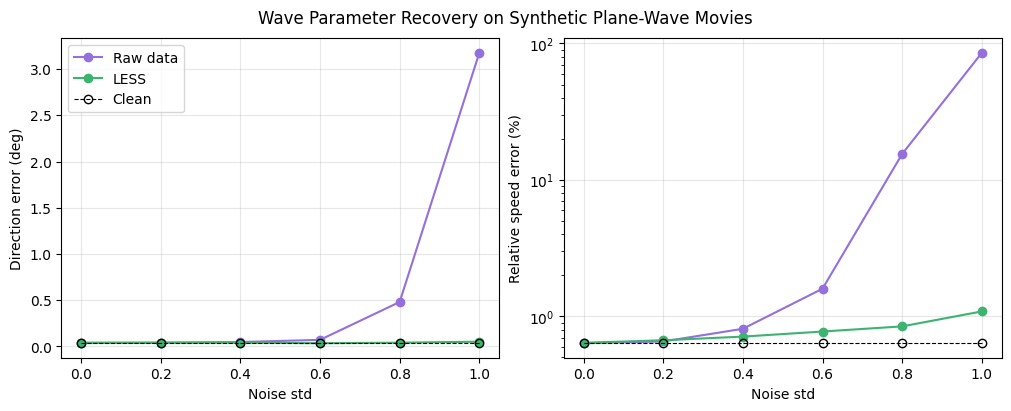

In [236]:
fig, axes = plot_wave_recovery_results(
    wave_results,
    show_clean=True,
    title="Wave Parameter Recovery on Synthetic Plane-Wave Movies",
)
plt.show()

# Validating on Real Data

In [21]:
def mask_movie(movie, raw_mask, binning, flip=True):
    raw_mask = np.ascontiguousarray(raw_mask.astype(np.float32))

    mask = cv2.resize(
        raw_mask,
        (0, 0),
        fx=1/binning,
        fy=1/binning,
        interpolation=cv2.INTER_LINEAR
    )

    mask = mask[:movie.shape[1], :movie.shape[2]] > 0.5

    if flip:
        mask = np.flipud(mask)

    out = movie.astype(float).copy()
    out[:, ~mask] = np.nan
    return out, mask


def load_movie(path, flip=False):
    with h5py.File(path, 'r') as mov_file:
        specs = mov_file["specs"]
        fps = specs['fps'][()].squeeze()
        raw_mask = specs["extra_specs"]["mask"][()].squeeze()
        binning = specs["binning"][()].squeeze()
        spaceorigin = specs["spaceorigin"][()].squeeze()  

        mov = mov_file['mov'][:10000]
        movie = np.nan_to_num(mov)
        if flip:
            movie = np.flip(movie, axis=1)

        movie_masked, mask = mask_movie(movie, raw_mask, binning, flip=True)

    return movie_masked, mask, binning


def bandpass_movie(movie, low=30, high=60, fs=157, order=4):
    """
    Bandpass filter a voltage imaging movie along the time axis.
    
    Parameters
    ----------
    movie : np.ndarray
        Shape (t, y, x).
    lowcut, highcut : float
        Frequency band (Hz).
    fs : float
        Sampling rate (Hz).
    order : int
        Filter order.
    """
    sos = butter(order, [low, high], btype='band', fs=fs, output='sos')
    filtered = sosfiltfilt(sos, movie, axis=0)
    return filtered

In [6]:
path_noisy = "Y:/Voltage/VisualConsciousness/Analysis/Visual/cfm005mjr/20251202/meas01/cG_unmixedTR_dFF.h5"
path_denoised = "Y:/Voltage/VisualConsciousness/Analysis/Visual/cfm005mjr/20251202/meas01/cG_unmixedTR_dFF_denoised.h5"

movie_noisy, _, _ = load_movie(path_noisy, flip=True)
movie_denoised, mask, binning = load_movie(path_denoised)

In [7]:
movie_noisy.shape

(10000, 213, 160)

In [121]:
file_path_noisy = 'Y:/Voltage/Code/Katie/Figure_4_Panels_D_R_m45_20211118_meas01_m45_d211118_s01KX_fast_300um-fps300-cG_umcnv.h5'
file_path_denoised = 'Y:/Voltage/Code/Katie/Figure4_denoised.h5'

with h5py.File(file_path_noisy, 'r') as mov_file:
        movie_noisy_300 = mov_file['mov'][:2000]

with h5py.File(file_path_denoised, 'r') as mov_file:
        movie_denoised_300 = mov_file['mov'][:2000]

Movie Shape: x, y, = 213, 84
FOV Size: 8 x 2.7 mm
Pixel Size: 0.0376, 0.032

In [124]:
movie_noisy_gamma = bandpass_movie(movie_noisy_300[1000:2000], fs=300, low=30, high=60)
movie_denoised_gamma = bandpass_movie(movie_denoised_300[1000:2000], fs=300, low=30, high=60)

### Frame Comparison Images

In [22]:
def plot_movie_frames(
    movie,
    frame_start=0,
    frame_end=None,
    every_n=1,
    xlim=None,
    ylim=None,
    vlims=None,
    cmap="seismic",
    colorbar=True,
    titles=True,
    plot_simple=False,
    pixel_size_mm=None,
    add_scalebar=False,
    scalebar_length_mm=1.0,
):
    """
    Plot selected frames from a movie as individual figures.

    Parameters
    ----------
    movie : np.ndarray
        Movie with shape (t, x, y).
    frame_start : int, optional
        First frame index to plot.
    frame_end : int or None, optional
        End frame index (exclusive). If None, plot through the last frame.
    every_n : int, optional
        Plot every n-th frame. Default is 1 (plot every frame).
    xlim : tuple[int, int] or None, optional
        Crop range in x as (x_start, x_end), using standard Python slicing.
        If None, use the full x range.
    ylim : tuple[int, int] or None, optional
        Crop range in y as (y_start, y_end), using standard Python slicing.
        If None, use the full y range.
    vlims : tuple[float, float] or None, optional
        Color limits as (vmin, vmax). If None, each frame uses its own min/max.
    cmap : str, optional
        Matplotlib colormap.
    colorbar : bool, optional
        If True, add a colorbar to each figure.
    titles : bool, optional
        If True, label each figure with the frame number and crop info.
    plot_simple : bool, optional
        If True, show only the image itself with no axes, title, or colorbar.
    pixel_size_mm : float or None, optional
        Pixel size in mm. Required if `add_scalebar=True`.
    add_scalebar : bool, optional
        If True, add a 2 mm scalebar to the first plotted image only.
    scalebar_length_mm : float, optional
        Scalebar length in mm. Default is 2.0.

    Returns
    -------
    None

    Notes
    -----
    The input movie is assumed to have shape (t, x, y). Since `imshow` expects
    image-like arrays in (rows, cols), each displayed frame is transposed before
    plotting so that the horizontal axis corresponds to x and the vertical axis
    corresponds to y.
    """
    movie = np.asarray(movie)

    if movie.ndim != 3:
        raise ValueError("`movie` must have shape (t, x, y).")

    if every_n < 1:
        raise ValueError("`every_n` must be >= 1.")

    if add_scalebar and (pixel_size_mm is None or pixel_size_mm <= 0):
        raise ValueError("`pixel_size_mm` must be provided and > 0 when `add_scalebar=True`.")

    t, x_size, y_size = movie.shape

    if frame_end is None:
        frame_end = t

    if not (0 <= frame_start < t):
        raise ValueError(f"`frame_start` must be in [0, {t-1}].")
    if not (frame_start < frame_end <= t):
        raise ValueError(f"`frame_end` must satisfy {frame_start} < frame_end <= {t}.")

    # Default full crop
    if xlim is None:
        xlim = (0, x_size)
    if ylim is None:
        ylim = (0, y_size)

    x0, x1 = xlim
    y0, y1 = ylim

    if not (0 <= x0 < x1 <= x_size):
        raise ValueError(f"`xlim` must satisfy 0 <= x0 < x1 <= {x_size}.")
    if not (0 <= y0 < y1 <= y_size):
        raise ValueError(f"`ylim` must satisfy 0 <= y0 < y1 <= {y_size}.")

    frame_indices = range(frame_start, frame_end, every_n)

    for j, i in enumerate(frame_indices):
        frame = movie[i, x0:x1, y0:y1]

        fig, ax = plt.subplots(figsize=(5, 5))

        im = ax.imshow(
            frame.T,
            cmap=cmap,
            origin="lower",
            vmin=None if vlims is None else vlims[0],
            vmax=None if vlims is None else vlims[1],
            aspect="equal",
        )

        # Add scalebar to the first plotted frame only
        if add_scalebar and j == 0:
            scalebar_len_px = scalebar_length_mm / pixel_size_mm

            # place near bottom-left in displayed coordinates
            y_pixels, x_pixels = frame.T.shape
            x_start_bar = 0.06 * x_pixels
            x_end_bar = x_start_bar + scalebar_len_px
            y_bar = 0.08 * y_pixels

            if x_end_bar > 0.94 * x_pixels:
                raise ValueError(
                    "Scalebar is too long for the cropped image. "
                    "Use a smaller crop or check `pixel_size_mm`."
                )

            ax.plot(
                [x_start_bar, x_end_bar],
                [y_bar, y_bar],
                color="white",
                linewidth=4,
                solid_capstyle="butt",
            )

        if plot_simple:
            ax.set_axis_off()
            fig.subplots_adjust(left=0, right=1, bottom=0, top=1)
        else:
            if titles:
                ax.set_title(f"Frame {i}   x:[{x0}:{x1}]   y:[{y0}:{y1}]")

            ax.set_xlabel("x")
            ax.set_ylabel("y")

            if colorbar:
                plt.colorbar(im, ax=ax)

        plt.show()

In [23]:
plot_movie_frames(
    movie_denoised_gamma,
    frame_start=637,
    frame_end=642,
    every_n=1,
    xlim=(7, 100),
    ylim=(2, 82),
    vlims=(-0.002, 0.002),
    pixel_size_mm=0.035,
    add_scalebar=True,
)

#plot_movie_frames(
    movie_denoised_gamma,
    frame_start=637,
    frame_end=642,
    every_n=1,
    xlim=(7, 100),
    ylim=(2, 82),
    vlims=(-0.002, 0.002),
    plot_simple=True,
    pixel_size_mm=0.035,
    add_scalebar=True,
)

#plot_movie_frames(
    movie_noisy_gamma,
    frame_start=637,
    frame_end=642,
    every_n=1,
    xlim=(7, 100),
    ylim=(2, 82),
    vlims=(-0.002, 0.002),
    plot_simple=True,
    pixel_size_mm=0.035,
    add_scalebar=True,
)

IndentationError: unexpected indent (2582184153.py, line 14)

In [24]:
def compute_frame_difference_metrics(movie):
    """
    Compute frame-to-frame difference metrics for a movie.

    Parameters
    ----------
    movie : np.ndarray
        Movie of shape (T, X, Y)

    Returns
    -------
    metrics : dict
        Contains one value per adjacent frame pair (length T-1):
            - diff_rms
            - diff_std
            - diff_robust_std
    """
    movie = np.asarray(movie, dtype=float)
    movie = np.nan_to_num(movie)

    if movie.ndim != 3:
        raise ValueError("movie must have shape (T, X, Y)")

    # Consecutive frame differences: shape (T-1, X, Y)
    diffs = np.diff(movie, axis=0)

    diff_rms = np.sqrt(np.mean(diffs**2, axis=(1, 2)))
    diff_std = np.std(diffs, axis=(1, 2))

    # Robust std via MAD for each diff frame
    diff_robust_std = np.empty(diffs.shape[0], dtype=float)
    for t in range(diffs.shape[0]):
        d = diffs[t].ravel()
        med = np.median(d)
        mad = np.median(np.abs(d - med))
        diff_robust_std[t] = 1.4826 * mad

    return {
        "diff_rms": diff_rms,
        "diff_std": diff_std,
        "diff_robust_std": diff_robust_std,
    }


def print_metric_summary(name, values):
    """
    Print summary statistics for a 1D metric array.
    """
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values)]

    print(f"{name}:")
    print(f"  n        = {len(values)}")
    print(f"  mean     = {np.mean(values):.6g}")
    print(f"  median   = {np.median(values):.6g}")
    print(f"  std      = {np.std(values, ddof=1):.6g}" if len(values) > 1 else "  std      = 0")
    print(f"  min/max  = {np.min(values):.6g} / {np.max(values):.6g}")


def plot_frame_difference_proxy(
    movie_noisy,
    movie_denoised,
    metric="diff_robust_std",
    bins=30,
):
    """
    Compare frame-to-frame difference distributions for raw and denoised movies.

    Parameters
    ----------
    movie_noisy : np.ndarray
        Raw/noisy movie, shape (T, X, Y)
    movie_denoised : np.ndarray
        Denoised movie, shape (T, X, Y)
    metric : str
        One of:
            - "diff_rms"
            - "diff_std"
            - "diff_robust_std"
    bins : int
        Number of histogram bins

    Returns
    -------
    noisy_vals, denoised_vals, fig, ax
    """
    noisy_metrics = compute_frame_difference_metrics(movie_noisy)
    denoised_metrics = compute_frame_difference_metrics(movie_denoised)

    if metric not in noisy_metrics:
        raise ValueError(f"metric must be one of {list(noisy_metrics.keys())}")

    noisy_vals = noisy_metrics[metric]
    denoised_vals = denoised_metrics[metric]

    noisy_vals = noisy_vals[np.isfinite(noisy_vals)]
    denoised_vals = denoised_vals[np.isfinite(denoised_vals)]

    all_vals = np.concatenate([noisy_vals, denoised_vals])
    bin_edges = np.linspace(np.min(all_vals), np.max(all_vals), bins + 1)

    # Convert counts to percent frequency
    weights_noisy = np.ones_like(noisy_vals) * (100.0 / len(noisy_vals))
    weights_denoised = np.ones_like(denoised_vals) * (100.0 / len(denoised_vals))

    fig, ax = plt.subplots(figsize=(7, 4), constrained_layout=True)

    ax.hist(
        noisy_vals,
        bins=bin_edges,
        weights=weights_noisy,
        color="lightgray",
        edgecolor="black",
        linewidth=0.8,
        alpha=0.8,
        label="Raw",
    )

    ax.hist(
        denoised_vals,
        bins=bin_edges,
        weights=weights_denoised,
        color="steelblue",
        edgecolor="black",
        linewidth=0.8,
        alpha=0.65,
        label="LESS",
    )

    label_map = {
        "diff_rms": "Frame-to-frame difference RMS",
        "diff_std": "Frame-to-frame difference STD",
        "diff_robust_std": "Frame-to-frame difference robust STD",
    }

    ax.set_xlabel(label_map[metric])
    ax.set_ylabel("Frequency (%)")
    ax.grid(True, alpha=0.25)
    ax.legend(frameon=False)

    #print_metric_summary(f"Raw {metric}", noisy_vals)
    #print_metric_summary(f"LESS {metric}", denoised_vals)

    return noisy_vals, denoised_vals, fig, ax


def compute_frame_difference_spatial_map(movie, metric="diff_robust_std"):
    """
    Compute a spatial map of frame-to-frame fluctuation magnitude.

    Parameters
    ----------
    movie : np.ndarray
        Movie of shape (T, X, Y).
    metric : str, optional
        One of:
            - "diff_rms"
            - "diff_std"
            - "diff_robust_std"

    Returns
    -------
    metric_map : np.ndarray
        2D array of shape (X, Y) containing the chosen frame-difference metric
        computed independently at each pixel across time.

    Notes
    -----
    For each pixel, this function computes consecutive-frame differences
    across time, then summarizes those differences with the requested metric.
    """
    movie = np.asarray(movie, dtype=float)

    if movie.ndim != 3:
        raise ValueError("movie must have shape (T, X, Y)")

    diffs = np.diff(movie, axis=0)  # shape (T-1, X, Y)

    if metric == "diff_rms":
        metric_map = np.sqrt(np.nanmean(diffs**2, axis=0))

    elif metric == "diff_std":
        metric_map = np.nanstd(diffs, axis=0)

    elif metric == "diff_robust_std":
        # Robust std via MAD at each pixel across time
        med = np.nanmedian(diffs, axis=0)
        mad = np.nanmedian(np.abs(diffs - med[None, :, :]), axis=0)
        metric_map = 1.4826 * mad

    else:
        raise ValueError("metric must be one of: 'diff_rms', 'diff_std', 'diff_robust_std'")

    return metric_map


def plot_frame_difference_spatial_map(
    movie,
    metric="diff_robust_std",
    title=None,
    cmap="magma",
    log_scale=False,
    vmin=None,
    vmax=None,
):
    """
    Plot a spatial map of frame-to-frame fluctuation magnitude.

    Parameters
    ----------
    movie : np.ndarray
        Movie of shape (T, X, Y).
    metric : str, optional
        One of:
            - "diff_rms"
            - "diff_std"
            - "diff_robust_std"
    title : str or None, optional
        Plot title. If None, a default title is used.
    cmap : str, optional
        Matplotlib colormap.
    log_scale : bool, optional
        If True, plot log10 of the metric map.
    vmin, vmax : float or None, optional
        Color limits passed to imshow.

    Returns
    -------
    metric_map : np.ndarray
        2D metric map.
    fig, ax
        Matplotlib figure and axes.
    """
    metric_map = compute_frame_difference_spatial_map(movie, metric=metric)

    plot_map = metric_map.copy()

    if log_scale:
        plot_map = np.where(plot_map > 0, np.log10(plot_map), np.nan)

    label_map = {
        "diff_rms": "Frame-to-frame difference RMS",
        "diff_std": "Frame-to-frame difference STD",
        "diff_robust_std": "Frame-to-frame difference robust STD",
    }

    if title is None:
        title = label_map[metric]
        if log_scale:
            title += " (log10)"

    fig, ax = plt.subplots(figsize=(5, 4))
    im = ax.imshow(plot_map, cmap=cmap, vmin=vmin, vmax=vmax)
    ax.set_title(title)
    ax.axis("off")

    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label(title)

    fig.tight_layout()

    return metric_map, fig, ax


def plot_frame_difference_spatial_comparison(
    movie_noisy,
    movie_denoised,
    metric="diff_robust_std",
    cmap="magma",
    log_scale=True,
    shared_limits=True,
    robust_percentiles=(1, 99),
):
    """
    Plot side-by-side spatial maps of frame-to-frame fluctuation magnitude
    for raw and LESS-denoised movies.

    Parameters
    ----------
    movie_noisy : np.ndarray
        Raw/noisy movie of shape (T, X, Y).
    movie_denoised : np.ndarray
        Denoised movie of shape (T, X, Y).
    metric : str, optional
        One of:
            - "diff_rms"
            - "diff_std"
            - "diff_robust_std"
    cmap : str, optional
        Matplotlib colormap.
    log_scale : bool, optional
        If True, display log10 of the maps.
    shared_limits : bool, optional
        If True, use the same color limits for both panels.
        If False, each panel gets its own color limits.
    robust_percentiles : tuple, optional
        Percentiles used to define color limits robustly.

    Returns
    -------
    noisy_map : np.ndarray
        Spatial metric map for raw movie.
    denoised_map : np.ndarray
        Spatial metric map for denoised movie.
    fig, axes
        Matplotlib figure and axes.
    """
    noisy_map = compute_frame_difference_spatial_map(movie_noisy, metric=metric)
    denoised_map = compute_frame_difference_spatial_map(movie_denoised, metric=metric)

    plot_noisy = noisy_map.copy()
    plot_denoised = denoised_map.copy()

    if log_scale:
        plot_noisy = np.where(plot_noisy > 0, np.log10(plot_noisy), np.nan)
        plot_denoised = np.where(plot_denoised > 0, np.log10(plot_denoised), np.nan)

    label_map = {
        "diff_rms": "Frame-to-frame difference RMS",
        "diff_std": "Frame-to-frame difference STD",
        "diff_robust_std": "Frame-to-frame difference robust STD",
    }

    cbar_label = label_map[metric]
    if log_scale:
        cbar_label += " (log10)"

    # Robust color limits
    if shared_limits:
        all_vals = np.concatenate([
            plot_noisy[np.isfinite(plot_noisy)],
            plot_denoised[np.isfinite(plot_denoised)],
        ])
        vmin, vmax = np.nanpercentile(all_vals, robust_percentiles)
        vmins = [vmin, vmin]
        vmaxs = [vmax, vmax]
    else:
        vmins = [
            np.nanpercentile(plot_noisy[np.isfinite(plot_noisy)], robust_percentiles[0]),
            np.nanpercentile(plot_denoised[np.isfinite(plot_denoised)], robust_percentiles[0]),
        ]
        vmaxs = [
            np.nanpercentile(plot_noisy[np.isfinite(plot_noisy)], robust_percentiles[1]),
            np.nanpercentile(plot_denoised[np.isfinite(plot_denoised)], robust_percentiles[1]),
        ]

    fig, axes = plt.subplots(
        1, 2,
        figsize=(5, 4.6),
        constrained_layout=True
    )

    im0 = axes[0].imshow(plot_noisy, cmap=cmap, vmin=vmins[0], vmax=vmaxs[0])
    axes[0].set_title("Raw")
    axes[0].axis("off")

    im1 = axes[1].imshow(plot_denoised, cmap=cmap, vmin=vmins[1], vmax=vmaxs[1])
    axes[1].set_title("LESS-denoised")
    axes[1].axis("off")

    if shared_limits:
        cbar = fig.colorbar(im1, ax=axes, shrink=0.9, pad=0.02)
        cbar.set_label(cbar_label)
    else:
        cbar0 = fig.colorbar(im0, ax=axes[0], shrink=0.9, pad=0.02)
        cbar0.set_label(cbar_label)

        cbar1 = fig.colorbar(im1, ax=axes[1], shrink=0.9, pad=0.02)
        cbar1.set_label(cbar_label)

    fig.suptitle(label_map[metric])

    return noisy_map, denoised_map, fig, axes


def plot_frame_difference_spatial_ratio(
    movie_noisy,
    movie_denoised,
    metric="diff_robust_std",
    cmap="magma",
    log_scale=True,
):
    """
    Plot the pixelwise ratio of denoised to raw frame-difference metric.

    Parameters
    ----------
    movie_noisy : np.ndarray
        Raw/noisy movie of shape (T, X, Y).
    movie_denoised : np.ndarray
        Denoised movie of shape (T, X, Y).
    metric : str, optional
        One of:
            - "diff_rms"
            - "diff_std"
            - "diff_robust_std"
    cmap : str, optional
        Matplotlib colormap.
    log_scale : bool, optional
        If True, display log10(denoised/raw). If False, display denoised/raw.

    Returns
    -------
    ratio_map : np.ndarray
        Pixelwise ratio map.
    fig, ax
        Matplotlib figure and axes.
    """
    noisy_map = compute_frame_difference_spatial_map(movie_noisy, metric=metric)
    denoised_map = compute_frame_difference_spatial_map(movie_denoised, metric=metric)

    ratio_map = np.full_like(noisy_map, np.nan, dtype=float)
    valid = noisy_map > 0
    ratio_map[valid] = denoised_map[valid] / noisy_map[valid]

    plot_map = ratio_map.copy()
    cbar_label = "LESS / Raw"

    if log_scale:
        plot_map = np.where(plot_map > 0, np.log10(plot_map), np.nan)
        cbar_label = "log10(LESS / Raw)"

    label_map = {
        "diff_rms": "Frame-to-frame difference RMS",
        "diff_std": "Frame-to-frame difference STD",
        "diff_robust_std": "Frame-to-frame difference robust STD",
    }

    fig, ax = plt.subplots(figsize=(5, 4))
    im = ax.imshow(plot_map, cmap=cmap)
    ax.set_title(f"{label_map[metric]} ratio")
    ax.axis("off")

    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label(cbar_label)

    fig.tight_layout()

    return ratio_map, fig, ax

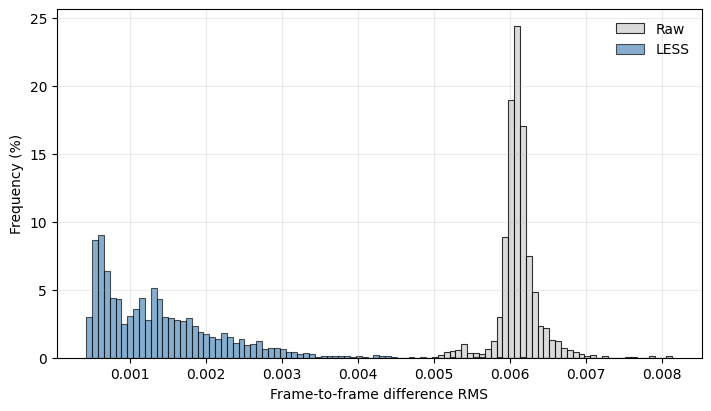

In [126]:
noisy_vals, denoised_vals, fig, ax = plot_frame_difference_proxy(
    movie_noisy_300,
    movie_denoised_300,
    metric="diff_rms",
    bins=100,
)
plt.show()

C:\Users\Katie\AppData\Local\Temp\ipykernel_41032\2865551509.py:180: RuntimeWarning: Mean of empty slice
  metric_map = np.sqrt(np.nanmean(diffs**2, axis=0))


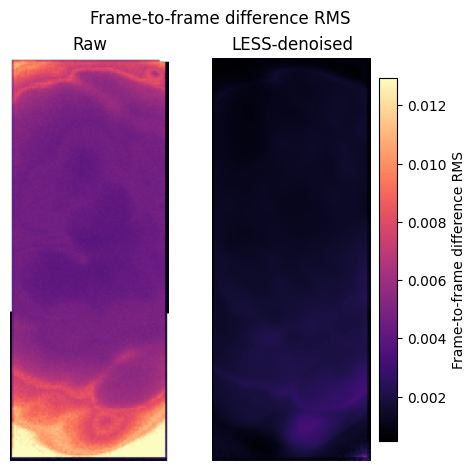

In [134]:
noisy_map, denoised_map, fig, axes = plot_frame_difference_spatial_comparison(
    movie_noisy_300,
    movie_denoised_300,
    metric="diff_rms",
    cmap="magma",
    log_scale=False,
    shared_limits=True,        
    robust_percentiles=(1, 99),
)
plt.show()


### PSD Comparison Plot

In [42]:
def _flatten_valid_pixels(movie, mask=None, min_std=1e-12):
    """
    Reshape a movie from (t, x, y) to (t, n_pixels) and keep only valid pixels.

    Parameters
    ----------
    movie : np.ndarray
        Movie array with shape (t, x, y).
    mask : np.ndarray or None, optional
        Boolean spatial mask with shape (x, y), where True means keep pixel.
        If None, all pixels are considered initially.
    min_std : float, optional
        Minimum temporal standard deviation required for a pixel to be kept.

    Returns
    -------
    pixel_traces : np.ndarray
        Array of shape (t, n_valid_pixels) containing only valid pixel traces.
    valid_mask_flat : np.ndarray
        Boolean mask of shape (x*y,) indicating which flattened pixels were kept.
    """
    if movie.ndim != 3:
        raise ValueError(f"`movie` must have shape (t, x, y), got {movie.shape}")

    t, x, y = movie.shape
    movie_flat = movie.reshape(t, x * y)

    if mask is None:
        valid_mask_flat = np.ones(x * y, dtype=bool)
    else:
        if mask.shape != (x, y):
            raise ValueError(f"`mask` must have shape {(x, y)}, got {mask.shape}")
        valid_mask_flat = mask.reshape(-1).astype(bool)

    finite_mask = np.all(np.isfinite(movie_flat), axis=0)
    std_mask = np.std(movie_flat, axis=0) > min_std

    valid_mask_flat &= finite_mask
    valid_mask_flat &= std_mask

    pixel_traces = movie_flat[:, valid_mask_flat]
    return pixel_traces, valid_mask_flat


def _compute_movie_std_for_valid_pixels(movie, mask=None, min_std=1e-12):
    """
    Compute the global standard deviation across all valid pixel values in a movie,
    using the same valid-pixel logic as the PSD pipeline.
    """
    pixel_traces, _ = _flatten_valid_pixels(movie, mask=mask, min_std=min_std)

    if pixel_traces.shape[1] == 0:
        raise ValueError("No valid pixels found for movie std calculation.")

    return np.std(pixel_traces)


def _generate_std_matched_gaussian_movie(movie_reference, mask=None, min_std=1e-12, random_seed=0):
    """
    Generate Gaussian white-noise movie with same shape as `movie_reference`,
    scaled so its global std across valid pixels matches the reference movie.
    """
    rng = np.random.default_rng(random_seed)
    gaussian_movie = rng.standard_normal(movie_reference.shape)

    ref_std = _compute_movie_std_for_valid_pixels(
        movie_reference,
        mask=mask,
        min_std=min_std,
    )

    gauss_std = _compute_movie_std_for_valid_pixels(
        gaussian_movie,
        mask=mask,
        min_std=min_std,
    )

    if gauss_std == 0:
        raise ValueError("Generated Gaussian movie has zero std; cannot rescale.")

    gaussian_movie = gaussian_movie * (ref_std / gauss_std)
    return gaussian_movie


def compute_mean_pixel_psd(
    movie,
    fps,
    mask=None,
    nperseg=None,
    noverlap=None,
    detrend="constant",
    window="hann",
    max_pixels=None,
    random_seed=0,
):
    """
    Compute the mean pixelwise PSD of a movie using Welch's method.

    Parameters
    ----------
    movie : np.ndarray
        Movie array with shape (t, x, y).
    fps : float
        Sampling rate in Hz.
    mask : np.ndarray or None, optional
        Boolean spatial mask with shape (x, y). True = include pixel.
    nperseg : int or None, optional
        Segment length for Welch PSD. If None, uses min(1024, n_timepoints).
    noverlap : int or None, optional
        Overlap between Welch segments. If None, defaults to nperseg // 2.
    detrend : str or callable, optional
        Detrending passed to scipy.signal.welch.
    window : str or tuple or array_like, optional
        Window passed to scipy.signal.welch.
    max_pixels : int or None, optional
        If provided, randomly subsample up to this many valid pixels.
    random_seed : int, optional
        Random seed used if `max_pixels` is not None.

    Returns
    -------
    freqs : np.ndarray
        Frequency axis in Hz.
    mean_psd : np.ndarray
        Mean PSD across valid pixels.
    sem_psd : np.ndarray
        Standard error of the mean PSD across valid pixels.
    n_pixels : int
        Number of pixels used.
    """
    pixel_traces, _ = _flatten_valid_pixels(movie, mask=mask)

    if pixel_traces.shape[1] == 0:
        raise ValueError("No valid pixels found for PSD calculation.")

    if max_pixels is not None and pixel_traces.shape[1] > max_pixels:
        rng = np.random.default_rng(random_seed)
        keep_idx = rng.choice(pixel_traces.shape[1], size=max_pixels, replace=False)
        pixel_traces = pixel_traces[:, keep_idx]

    n_time = pixel_traces.shape[0]

    if nperseg is None:
        nperseg = min(1024, n_time)

    if noverlap is None:
        noverlap = nperseg // 2

    freqs, psd = sp.signal.welch(
        pixel_traces,
        fs=fps,
        window=window,
        nperseg=nperseg,
        noverlap=noverlap,
        detrend=detrend,
        axis=0,
        scaling="density",
    )

    mean_psd = np.mean(psd, axis=1)
    sem_psd = np.std(psd, axis=1, ddof=1) / np.sqrt(psd.shape[1])

    return freqs, mean_psd, sem_psd, psd.shape[1]


def compute_psd_comparison(
    movie_noisy,
    movie_denoised,
    fps,
    mask=None,
    nperseg=None,
    noverlap=None,
    detrend="constant",
    window="hann",
    max_pixels=None,
    random_seed=0,
):
    """
    Compute mean PSDs for noisy movie, denoised movie, residual, and
    std-matched Gaussian white noise.

    Parameters
    ----------
    movie_noisy : np.ndarray
        Raw/noisy movie with shape (t, x, y).
    movie_denoised : np.ndarray
        Denoised movie with shape (t, x, y).
    fps : float
        Sampling rate in Hz.
    mask : np.ndarray or None, optional
        Boolean spatial mask with shape (x, y). True = include pixel.
    nperseg, noverlap, detrend, window, max_pixels, random_seed
        Passed to `compute_mean_pixel_psd`.

    Returns
    -------
    results : dict
        Dictionary containing frequency axis and PSD summaries for all movies.
    """
    if movie_noisy.shape != movie_denoised.shape:
        raise ValueError(
            f"`movie_noisy` and `movie_denoised` must have the same shape, "
            f"got {movie_noisy.shape} and {movie_denoised.shape}"
        )

    movie_residual = movie_noisy - movie_denoised
    movie_gaussian = _generate_std_matched_gaussian_movie(
        movie_residual,
        mask=mask,
        random_seed=random_seed,
    )

    freqs, mean_psd_noisy, sem_psd_noisy, n_pixels_noisy = compute_mean_pixel_psd(
        movie_noisy,
        fps=fps,
        mask=mask,
        nperseg=nperseg,
        noverlap=noverlap,
        detrend=detrend,
        window=window,
        max_pixels=max_pixels,
        random_seed=random_seed,
    )

    freqs2, mean_psd_denoised, sem_psd_denoised, n_pixels_denoised = compute_mean_pixel_psd(
        movie_denoised,
        fps=fps,
        mask=mask,
        nperseg=nperseg,
        noverlap=noverlap,
        detrend=detrend,
        window=window,
        max_pixels=max_pixels,
        random_seed=random_seed,
    )

    freqs3, mean_psd_residual, sem_psd_residual, n_pixels_residual = compute_mean_pixel_psd(
        movie_residual,
        fps=fps,
        mask=mask,
        nperseg=nperseg,
        noverlap=noverlap,
        detrend=detrend,
        window=window,
        max_pixels=max_pixels,
        random_seed=random_seed,
    )

    freqs4, mean_psd_gaussian, sem_psd_gaussian, n_pixels_gaussian = compute_mean_pixel_psd(
        movie_gaussian,
        fps=fps,
        mask=mask,
        nperseg=nperseg,
        noverlap=noverlap,
        detrend=detrend,
        window=window,
        max_pixels=max_pixels,
        random_seed=random_seed,
    )

    if not (
        np.allclose(freqs, freqs2)
        and np.allclose(freqs, freqs3)
        and np.allclose(freqs, freqs4)
    ):
        raise RuntimeError("Frequency axes do not match across PSD calculations.")

    return {
        "freqs": freqs,
        "mean_psd_noisy": mean_psd_noisy,
        "sem_psd_noisy": sem_psd_noisy,
        "n_pixels_noisy": n_pixels_noisy,
        "mean_psd_denoised": mean_psd_denoised,
        "sem_psd_denoised": sem_psd_denoised,
        "n_pixels_denoised": n_pixels_denoised,
        "mean_psd_residual": mean_psd_residual,
        "sem_psd_residual": sem_psd_residual,
        "n_pixels_residual": n_pixels_residual,
        "mean_psd_gaussian": mean_psd_gaussian,
        "sem_psd_gaussian": sem_psd_gaussian,
        "n_pixels_gaussian": n_pixels_gaussian,
    }


def plot_psd_comparison(
    psd_results,
    fmin=0,
    fmax=None,
    show_sem=False,
    logy=True,
    title="Mean pixelwise PSD",
    ax=None,
    plot_residual=False,
    plot_gaussian=False,
):
    """
    Plot the mean PSD comparison for noisy and denoised movies, with optional
    residual and Gaussian white-noise baseline.

    Parameters
    ----------
    psd_results : dict
        Output from `compute_psd_comparison`.
    fmin : float, optional
        Minimum frequency to display.
    fmax : float or None, optional
        Maximum frequency to display. If None, uses full range.
    show_sem : bool, optional
        If True, add shaded SEM bands.
    logy : bool, optional
        If True, use a log scale for the y-axis.
    title : str, optional
        Plot title.
    ax : matplotlib.axes.Axes or None, optional
        Existing axes to plot on. If None, a new figure is created.
    plot_residual : bool, optional
        If True, plot PSD of residual movie (noisy - denoised).
    plot_gaussian : bool, optional
        If True, plot PSD of std-matched Gaussian white noise.

    Returns
    -------
    fig, ax : matplotlib Figure and Axes
    """
    freqs = psd_results["freqs"]

    keep = freqs >= fmin
    if fmax is not None:
        keep &= freqs <= fmax

    freqs_plot = freqs[keep]

    noisy_plot = psd_results["mean_psd_noisy"][keep]
    noisy_sem_plot = psd_results["sem_psd_noisy"][keep]

    den_plot = psd_results["mean_psd_denoised"][keep]
    den_sem_plot = psd_results["sem_psd_denoised"][keep]

    if plot_residual:
        residual_plot = psd_results["mean_psd_residual"][keep]
        residual_sem_plot = psd_results["sem_psd_residual"][keep]

    if plot_gaussian:
        gaussian_plot = psd_results["mean_psd_gaussian"][keep]
        gaussian_sem_plot = psd_results["sem_psd_gaussian"][keep]

    if ax is None:
        fig, ax = plt.subplots(figsize=(7, 4.5))
    else:
        fig = ax.figure

    ax.plot(freqs_plot, noisy_plot, linewidth=2, label="Raw", c="grey")
    ax.plot(freqs_plot, den_plot, linewidth=2, label="LESS-denoised", c="cornflowerblue")

    if plot_residual:
        ax.plot(freqs_plot, residual_plot, linewidth=2, label="Residual", c="mediumseagreen")

    if plot_gaussian:
        ax.plot(freqs_plot, gaussian_plot, linewidth=2, label="Gaussian", c="black", ls=':')

    if show_sem:
        ax.fill_between(freqs_plot, noisy_plot - noisy_sem_plot, noisy_plot + noisy_sem_plot, alpha=0.2)
        ax.fill_between(freqs_plot, den_plot - den_sem_plot, den_plot + den_sem_plot, alpha=0.2)

        if plot_residual:
            ax.fill_between(
                freqs_plot,
                residual_plot - residual_sem_plot,
                residual_plot + residual_sem_plot,
                alpha=0.2,
            )

        if plot_gaussian:
            ax.fill_between(
                freqs_plot,
                gaussian_plot - gaussian_sem_plot,
                gaussian_plot + gaussian_sem_plot,
                alpha=0.2,
            )

    ax.set_xlabel("Frequency (Hz)")
    ax.set_ylabel("Power spectral density")
    ax.set_title(title)
    ax.legend(frameon=False)

    if logy:
        ax.set_yscale("log")

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    fig.tight_layout()

    return fig, ax

In [43]:
psd_results = compute_psd_comparison(
    movie_noisy=movie_noisy,
    movie_denoised=movie_denoised,
    fps=157,
    mask=mask,        # or your boolean spatial mask
    nperseg=1024,
    noverlap=512,
    detrend="constant",
    window="hann",
    max_pixels=None,
    random_seed=0,
)

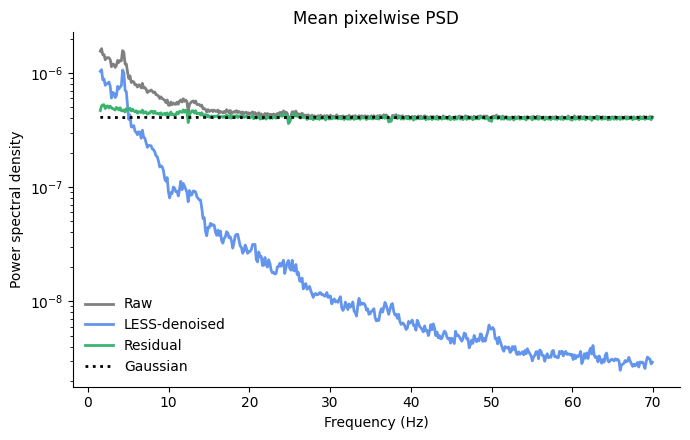

In [44]:
fig, ax = plot_psd_comparison(
    psd_results,
    fmin=1.5,
    fmax=70,
    show_sem=True,
    logy=True,
    title="Mean pixelwise PSD",
    plot_residual=True,
    plot_gaussian=True,
)
plt.show()

### Band-Specific SNR
Should I eventually plot this as a scatterplot over a bunch of denoised recordings??

In [49]:
def make_default_snr_bands():
    """
    Return a default set of biological frequency bands and nearby reference bands.

    Returns
    -------
    bands : dict
        Dictionary of the form:
        {
            "band_name": {
                "signal": (f_low, f_high),
                "reference": (f_low, f_high),
            },
            ...
        }

    Notes
    -----
    These are reasonable starting points for voltage imaging data, but you
    should adjust them as needed for your dataset and manuscript conventions.

    The reference bands are chosen to be nearby while avoiding overlap with
    the signal band. The gamma reference avoids the 60 Hz line-noise region.
    """
    return {
        "Delta": {"signal": (1.5, 5), "reference": (5, 7)},
        "Theta": {"signal": (8, 12),   "reference": (13, 15)},
        "Beta":  {"signal": (15, 30), "reference": (31, 38)},
        "Gamma": {"signal": (38, 60), "reference": (62, 70)},
    }


def _mean_power_in_band(freqs, psd, band):
    """
    Compute the mean PSD within a frequency band.

    Parameters
    ----------
    freqs : np.ndarray
        Frequency axis in Hz.
    psd : np.ndarray
        PSD values corresponding to `freqs`.
    band : tuple
        Frequency range (f_low, f_high) in Hz.

    Returns
    -------
    mean_power : float
        Mean PSD within the band.

    Raises
    ------
    ValueError
        If the band contains no frequency samples.
    """
    f_low, f_high = band
    keep = (freqs >= f_low) & (freqs <= f_high)

    if not np.any(keep):
        raise ValueError(f"No frequency samples found in band {band}.")

    return np.mean(psd[keep])


def compute_band_snr_from_psd(psd_results, bands=None):
    """
    Compute band-specific spectral SNR for raw and LESS-denoised movies.

    Parameters
    ----------
    psd_results : dict
        Output from `compute_psd_comparison`.
    bands : dict or None, optional
        Dictionary defining signal and reference bands. If None, uses
        `make_default_snr_bands()`.

    Returns
    -------
    snr_results : dict
        Dictionary containing per-band results for raw and LESS-denoised data.

    Notes
    -----
    Spectral SNR is defined here as:

        mean power in signal band / mean power in reference band

    This is a relative spectral contrast measure, not a conventional
    additive-noise SNR in absolute units.
    """
    if bands is None:
        bands = make_default_snr_bands()

    freqs = psd_results["freqs"]
    psd_raw = psd_results["mean_psd_noisy"]
    psd_denoised = psd_results["mean_psd_denoised"]

    results = {
        "band_names": [],
        "snr_raw": [],
        "snr_denoised": [],
        "raw_signal_power": [],
        "raw_reference_power": [],
        "denoised_signal_power": [],
        "denoised_reference_power": [],
        "bands": bands,
    }

    for band_name, band_def in bands.items():
        signal_band = band_def["signal"]
        reference_band = band_def["reference"]

        raw_signal = _mean_power_in_band(freqs, psd_raw, signal_band)
        raw_reference = _mean_power_in_band(freqs, psd_raw, reference_band)

        den_signal = _mean_power_in_band(freqs, psd_denoised, signal_band)
        den_reference = _mean_power_in_band(freqs, psd_denoised, reference_band)

        results["band_names"].append(band_name)
        results["snr_raw"].append(raw_signal / raw_reference)
        results["snr_denoised"].append(den_signal / den_reference)
        results["raw_signal_power"].append(raw_signal)
        results["raw_reference_power"].append(raw_reference)
        results["denoised_signal_power"].append(den_signal)
        results["denoised_reference_power"].append(den_reference)

    # Convert to arrays for convenience
    results["snr_raw"] = np.asarray(results["snr_raw"])
    results["snr_denoised"] = np.asarray(results["snr_denoised"])
    results["raw_signal_power"] = np.asarray(results["raw_signal_power"])
    results["raw_reference_power"] = np.asarray(results["raw_reference_power"])
    results["denoised_signal_power"] = np.asarray(results["denoised_signal_power"])
    results["denoised_reference_power"] = np.asarray(results["denoised_reference_power"])

    return results


def plot_band_snr_comparison(
    snr_results,
    title="Band-specific spectral SNR",
    raw_color="grey",
    denoised_color="cornflowerblue",
    ax=None,
):
    """
    Plot band-specific spectral SNR for raw and LESS-denoised movies.

    Parameters
    ----------
    snr_results : dict
        Output from `compute_band_snr_from_psd`.
    title : str, optional
        Plot title.
    raw_color : str, optional
        Color for raw data.
    denoised_color : str, optional
        Color for LESS-denoised data.
    ax : matplotlib.axes.Axes or None, optional
        Existing axes to plot on. If None, a new figure is created.

    Returns
    -------
    fig, ax : matplotlib Figure and Axes
    """
    band_names = snr_results["band_names"]
    snr_raw = snr_results["snr_raw"]
    snr_denoised = snr_results["snr_denoised"]

    x = np.arange(len(band_names))
    width = 0.36

    if ax is None:
        fig, ax = plt.subplots(figsize=(6.5, 4.5))
    else:
        fig = ax.figure

    ax.bar(x - width / 2, snr_raw, width=width, color=raw_color, label="Raw")
    ax.bar(x + width / 2, snr_denoised, width=width, color=denoised_color, label="LESS-denoised")

    ax.set_xticks(x)
    ax.set_xticklabels(band_names)
    ax.set_ylabel("Spectral SNR\n(signal band / reference band)")
    ax.set_title(title)
    ax.legend(frameon=False)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    fig.tight_layout()

    return fig, ax


def print_band_definitions(bands):
    """
    Print signal and reference band definitions in a readable format.

    Parameters
    ----------
    bands : dict
        Band definition dictionary.
    """
    for band_name, band_def in bands.items():
        signal = band_def["signal"]
        reference = band_def["reference"]
        print(
            f"{band_name:>6s}: "
            f"signal = {signal[0]}-{signal[1]} Hz, "
            f"reference = {reference[0]}-{reference[1]} Hz"
        )

In [ ]:
# Define the signal and reference bands you want to use
bands = make_default_snr_bands()

# Optional: inspect the exact definitions
print_band_definitions(bands)

# Compute band-specific spectral SNR from the PSD results
snr_results = compute_band_snr_from_psd(psd_results, bands=bands)

# Plot raw vs LESS-denoised spectral SNR
fig, ax = plot_band_snr_comparison(
    snr_results,
    title="Band-specific spectral SNR",
    raw_color="grey",
    denoised_color="cornflowerblue",
)
plt.show()

In [51]:
def compute_pixelwise_psd(
    movie,
    fps,
    mask=None,
    nperseg=None,
    noverlap=None,
    detrend="constant",
    window="hann",
    max_pixels=None,
    random_seed=0,
    min_std=1e-12,
):
    """
    Compute a Welch PSD for each valid pixel in a movie.

    Parameters
    ----------
    movie : np.ndarray
        Movie array with shape (t, x, y).
    fps : float
        Sampling rate in Hz.
    mask : np.ndarray or None, optional
        Boolean spatial mask with shape (x, y). True = include pixel.
    nperseg : int or None, optional
        Segment length for Welch PSD. If None, uses min(1024, n_timepoints).
    noverlap : int or None, optional
        Overlap between Welch segments. If None, defaults to nperseg // 2.
    detrend : str or callable, optional
        Detrending passed to scipy.signal.welch.
    window : str or tuple or array_like, optional
        Window passed to scipy.signal.welch.
    max_pixels : int or None, optional
        If provided, randomly subsample up to this many valid pixels.
    random_seed : int, optional
        Random seed used if `max_pixels` is not None.
    min_std : float, optional
        Minimum temporal standard deviation required for a pixel to be kept.

    Returns
    -------
    freqs : np.ndarray
        Frequency axis in Hz.
    psd : np.ndarray
        Pixelwise PSD array with shape (n_freqs, n_pixels).
    valid_mask_flat : np.ndarray
        Boolean mask of shape (x*y,) indicating which flattened pixels were used.
    """
    pixel_traces, valid_mask_flat = _flatten_valid_pixels(movie, mask=mask, min_std=min_std)

    if pixel_traces.shape[1] == 0:
        raise ValueError("No valid pixels found for PSD calculation.")

    if max_pixels is not None and pixel_traces.shape[1] > max_pixels:
        rng = np.random.default_rng(random_seed)
        keep_idx = rng.choice(pixel_traces.shape[1], size=max_pixels, replace=False)
        pixel_traces = pixel_traces[:, keep_idx]

        valid_indices = np.flatnonzero(valid_mask_flat)
        keep_flat_indices = valid_indices[keep_idx]

        new_valid_mask_flat = np.zeros_like(valid_mask_flat, dtype=bool)
        new_valid_mask_flat[keep_flat_indices] = True
        valid_mask_flat = new_valid_mask_flat

    n_time = pixel_traces.shape[0]

    if nperseg is None:
        nperseg = min(1024, n_time)

    if noverlap is None:
        noverlap = nperseg // 2

    freqs, psd = sp.signal.welch(
        pixel_traces,
        fs=fps,
        window=window,
        nperseg=nperseg,
        noverlap=noverlap,
        detrend=detrend,
        axis=0,
        scaling="density",
    )

    return freqs, psd, valid_mask_flat


def compute_pixelwise_psd_comparison(
    movie_noisy,
    movie_denoised,
    fps,
    mask=None,
    nperseg=None,
    noverlap=None,
    detrend="constant",
    window="hann",
    max_pixels=None,
    random_seed=0,
    min_std=1e-12,
):
    """
    Compute per-pixel PSDs for a raw movie and its LESS-denoised version.
    """
    if movie_noisy.shape != movie_denoised.shape:
        raise ValueError(
            f"`movie_noisy` and `movie_denoised` must have the same shape, "
            f"got {movie_noisy.shape} and {movie_denoised.shape}"
        )

    freqs_raw, psd_raw, valid_mask_raw = compute_pixelwise_psd(
        movie_noisy,
        fps=fps,
        mask=mask,
        nperseg=nperseg,
        noverlap=noverlap,
        detrend=detrend,
        window=window,
        max_pixels=max_pixels,
        random_seed=random_seed,
        min_std=min_std,
    )

    freqs_den, psd_den, valid_mask_den = compute_pixelwise_psd(
        movie_denoised,
        fps=fps,
        mask=mask,
        nperseg=nperseg,
        noverlap=noverlap,
        detrend=detrend,
        window=window,
        max_pixels=max_pixels,
        random_seed=random_seed,
        min_std=min_std,
    )

    if not np.allclose(freqs_raw, freqs_den):
        raise RuntimeError("Frequency axes do not match between raw and denoised PSDs.")

    if not np.array_equal(valid_mask_raw, valid_mask_den):
        raise RuntimeError("Valid pixel sets do not match between raw and denoised movies.")

    return {
        "freqs": freqs_raw,
        "psd_raw": psd_raw,
        "psd_denoised": psd_den,
        "valid_mask_flat": valid_mask_raw,
        "n_pixels": psd_raw.shape[1],
    }


def _band_mean_power_per_pixel(freqs, psd, band):
    """
    Compute mean power in a frequency band for each pixel.

    Parameters
    ----------
    freqs : np.ndarray
        Frequency axis in Hz.
    psd : np.ndarray
        PSD array with shape (n_freqs, n_pixels).
    band : tuple
        Frequency range (f_low, f_high) in Hz.

    Returns
    -------
    band_power : np.ndarray
        Mean power in the band for each pixel, shape (n_pixels,).

    Raises
    ------
    ValueError
        If the band contains no frequency samples.
    """
    f_low, f_high = band
    keep = (freqs >= f_low) & (freqs <= f_high)

    if not np.any(keep):
        raise ValueError(f"No frequency samples found in band {band}.")

    return np.mean(psd[keep, :], axis=0)


def compute_pixelwise_band_snr(psd_pixelwise_results, bands=None, min_reference_power=1e-20):
    """
    Compute per-pixel band-specific spectral SNR for raw and LESS-denoised data.

    Parameters
    ----------
    psd_pixelwise_results : dict
        Output from `compute_pixelwise_psd_comparison`.
    bands : dict or None, optional
        Dictionary defining signal and reference bands. If None, uses
        `make_default_snr_bands()`.
    min_reference_power : float, optional
        Minimum reference-band power required to compute a valid SNR.
        Pixels below this threshold are set to NaN for that band.

    Returns
    -------
    results : dict
        Dictionary containing per-pixel SNR values for each band.
    """
    if bands is None:
        bands = make_default_snr_bands()

    freqs = psd_pixelwise_results["freqs"]
    psd_raw = psd_pixelwise_results["psd_raw"]
    psd_denoised = psd_pixelwise_results["psd_denoised"]

    results = {
        "band_names": [],
        "snr_raw": {},
        "snr_denoised": {},
        "signal_power_raw": {},
        "reference_power_raw": {},
        "signal_power_denoised": {},
        "reference_power_denoised": {},
        "valid_snr_mask_raw": {},
        "valid_snr_mask_denoised": {},
        "bands": bands,
        "valid_mask_flat": psd_pixelwise_results["valid_mask_flat"],
    }

    for band_name, band_def in bands.items():
        signal_band = band_def["signal"]
        reference_band = band_def["reference"]

        raw_signal = _band_mean_power_per_pixel(freqs, psd_raw, signal_band)
        raw_reference = _band_mean_power_per_pixel(freqs, psd_raw, reference_band)

        den_signal = _band_mean_power_per_pixel(freqs, psd_denoised, signal_band)
        den_reference = _band_mean_power_per_pixel(freqs, psd_denoised, reference_band)

        raw_valid = np.isfinite(raw_signal) & np.isfinite(raw_reference) & (raw_reference > min_reference_power)
        den_valid = np.isfinite(den_signal) & np.isfinite(den_reference) & (den_reference > min_reference_power)

        raw_snr = np.full(raw_signal.shape, np.nan, dtype=float)
        den_snr = np.full(den_signal.shape, np.nan, dtype=float)

        raw_snr[raw_valid] = raw_signal[raw_valid] / raw_reference[raw_valid]
        den_snr[den_valid] = den_signal[den_valid] / den_reference[den_valid]

        results["band_names"].append(band_name)
        results["signal_power_raw"][band_name] = raw_signal
        results["reference_power_raw"][band_name] = raw_reference
        results["signal_power_denoised"][band_name] = den_signal
        results["reference_power_denoised"][band_name] = den_reference
        results["snr_raw"][band_name] = raw_snr
        results["snr_denoised"][band_name] = den_snr
        results["valid_snr_mask_raw"][band_name] = raw_valid
        results["valid_snr_mask_denoised"][band_name] = den_valid

    return results


def summarize_pixelwise_band_snr(snr_pixelwise_results):
    """
    Compute mean and SEM of per-pixel band-specific spectral SNR, ignoring NaNs.
    """
    band_names = snr_pixelwise_results["band_names"]

    mean_raw = []
    sem_raw = []
    mean_denoised = []
    sem_denoised = []
    n_raw = []
    n_denoised = []

    for band_name in band_names:
        raw_vals = snr_pixelwise_results["snr_raw"][band_name]
        den_vals = snr_pixelwise_results["snr_denoised"][band_name]

        raw_vals = raw_vals[np.isfinite(raw_vals)]
        den_vals = den_vals[np.isfinite(den_vals)]

        if raw_vals.size == 0 or den_vals.size == 0:
            raise ValueError(
                f"No valid SNR values found for band '{band_name}'. "
                "This usually means the reference band has near-zero power "
                "for all included pixels."
            )

        mean_raw.append(np.mean(raw_vals))
        sem_raw.append(np.std(raw_vals, ddof=1) / np.sqrt(raw_vals.size))
        mean_denoised.append(np.mean(den_vals))
        sem_denoised.append(np.std(den_vals, ddof=1) / np.sqrt(den_vals.size))
        n_raw.append(raw_vals.size)
        n_denoised.append(den_vals.size)

    return {
        "band_names": band_names,
        "mean_raw": np.asarray(mean_raw),
        "sem_raw": np.asarray(sem_raw),
        "mean_denoised": np.asarray(mean_denoised),
        "sem_denoised": np.asarray(sem_denoised),
        "n_raw": np.asarray(n_raw),
        "n_denoised": np.asarray(n_denoised),
    }


def plot_pixelwise_band_snr_summary(
    snr_summary,
    title="Band-specific spectral SNR",
    show_points=False,
    snr_pixelwise_results=None,
    max_points=2000,
    random_seed=0,
    ax=None,
):
    """
    Plot mean ± SEM band-specific spectral SNR across pixels.

    Parameters
    ----------
    snr_summary : dict
        Output from `summarize_pixelwise_band_snr`.
    title : str, optional
        Plot title.
    raw_color : str, optional
        Color for raw data.
    denoised_color : str, optional
        Color for LESS-denoised data.
    show_points : bool, optional
        If True, overlay a subsample of per-pixel values as jittered points.
    snr_pixelwise_results : dict or None, optional
        Required if `show_points=True`.
    max_points : int, optional
        Maximum number of per-pixel points to overlay per band and condition.
    random_seed : int, optional
        Random seed for point subsampling.
    ax : matplotlib.axes.Axes or None, optional
        Existing axes to plot on. If None, a new figure is created.

    Returns
    -------
    fig, ax : matplotlib Figure and Axes
    """
    band_names = snr_summary["band_names"]
    mean_raw = snr_summary["mean_raw"]
    sem_raw = snr_summary["sem_raw"]
    mean_denoised = snr_summary["mean_denoised"]
    sem_denoised = snr_summary["sem_denoised"]

    x = np.arange(len(band_names))
    width = 0.36

    if ax is None:
        fig, ax = plt.subplots(figsize=(7, 4.8))
    else:
        fig = ax.figure

    ax.bar(
        x - width / 2,
        mean_raw,
        width=width,
        yerr=sem_raw,
        color='darkgrey',
        label="Raw",
        capsize=3,
    )
    ax.bar(
        x + width / 2,
        mean_denoised,
        width=width,
        yerr=sem_denoised,
        color='cornflowerblue',
        label="LESS-denoised",
        capsize=3,
    )

    if show_points:
        if snr_pixelwise_results is None:
            raise ValueError("`snr_pixelwise_results` must be provided when `show_points=True`.")

        rng = np.random.default_rng(random_seed)

        for i, band_name in enumerate(band_names):
            raw_vals = snr_pixelwise_results["snr_raw"][band_name]
            den_vals = snr_pixelwise_results["snr_denoised"][band_name]

            n_raw = min(max_points, raw_vals.size)
            n_den = min(max_points, den_vals.size)

            raw_idx = rng.choice(raw_vals.size, size=n_raw, replace=False)
            den_idx = rng.choice(den_vals.size, size=n_den, replace=False)

            raw_x = (x[i] - width / 2) + rng.uniform(-0.06, 0.06, size=n_raw)
            den_x = (x[i] + width / 2) + rng.uniform(-0.06, 0.06, size=n_den)

            ax.plot(raw_x, raw_vals[raw_idx], ".", color='darkgrey', alpha=0.12, markersize=3)
            ax.plot(den_x, den_vals[den_idx], ".", color='cornflowerblue', alpha=0.12, markersize=3)

    ax.set_xticks(x)
    ax.set_xticklabels(band_names)
    ax.set_ylabel("Spectral SNR\n(signal band / reference band)")
    ax.set_title(title)
    ax.legend(frameon=False)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    fig.tight_layout()

    return fig, ax


def plot_pixelwise_band_snr_boxplot(
    snr_pixelwise_results,
    title="Band-specific spectral SNR",
    raw_color="grey",
    denoised_color="cornflowerblue",
    show_points=True,
    max_points=3000,
    point_alpha=0.12,
    point_size=3,
    jitter=0.06,
    showfliers=False,
    ax=None,
    random_seed=0,
):
    """
    Plot per-pixel band-specific spectral SNR as side-by-side box plots with
    optional overlaid pixel values.

    Parameters
    ----------
    snr_pixelwise_results : dict
        Output from `compute_pixelwise_band_snr`.
    title : str, optional
        Plot title.
    raw_color : str, optional
        Color for raw data.
    denoised_color : str, optional
        Color for LESS-denoised data.
    show_points : bool, optional
        If True, overlay a subsample of per-pixel values as jittered points.
    max_points : int, optional
        Maximum number of points to overlay per band and condition.
    point_alpha : float, optional
        Transparency for overlaid points.
    point_size : float, optional
        Marker size for overlaid points.
    jitter : float, optional
        Horizontal jitter range for overlaid points.
    showfliers : bool, optional
        Whether to show boxplot fliers.
    ax : matplotlib.axes.Axes or None, optional
        Existing axes to plot on. If None, a new figure is created.
    random_seed : int, optional
        Random seed for point subsampling and jitter.

    Returns
    -------
    fig, ax : matplotlib Figure and Axes
    """
    band_names = snr_pixelwise_results["band_names"]
    rng = np.random.default_rng(random_seed)

    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 5))
    else:
        fig = ax.figure

    x = np.arange(len(band_names))
    offset = 0.18
    width = 0.28

    raw_positions = x - offset
    den_positions = x + offset

    raw_data = []
    den_data = []

    for band_name in band_names:
        raw_vals = snr_pixelwise_results["snr_raw"][band_name]
        den_vals = snr_pixelwise_results["snr_denoised"][band_name]

        raw_vals = raw_vals[np.isfinite(raw_vals)]
        den_vals = den_vals[np.isfinite(den_vals)]

        raw_data.append(raw_vals)
        den_data.append(den_vals)

    raw_bp = ax.boxplot(
        raw_data,
        positions=raw_positions,
        widths=width,
        patch_artist=True,
        showfliers=showfliers,
        medianprops=dict(color="black", linewidth=1.5),
        whiskerprops=dict(linewidth=1.2),
        capprops=dict(linewidth=1.2),
        boxprops=dict(linewidth=1.2),
    )

    den_bp = ax.boxplot(
        den_data,
        positions=den_positions,
        widths=width,
        patch_artist=True,
        showfliers=showfliers,
        medianprops=dict(color="black", linewidth=1.5),
        whiskerprops=dict(linewidth=1.2),
        capprops=dict(linewidth=1.2),
        boxprops=dict(linewidth=1.2),
    )

    for patch in raw_bp["boxes"]:
        patch.set_facecolor(raw_color)
        patch.set_alpha(0.7)

    for patch in den_bp["boxes"]:
        patch.set_facecolor(denoised_color)
        patch.set_alpha(0.7)

    if show_points:
        for i, (raw_vals, den_vals) in enumerate(zip(raw_data, den_data)):
            n_raw = min(max_points, raw_vals.size)
            n_den = min(max_points, den_vals.size)

            raw_idx = rng.choice(raw_vals.size, size=n_raw, replace=False)
            den_idx = rng.choice(den_vals.size, size=n_den, replace=False)

            raw_x = raw_positions[i] + rng.uniform(-jitter, jitter, size=n_raw)
            den_x = den_positions[i] + rng.uniform(-jitter, jitter, size=n_den)

            ax.plot(
                raw_x,
                raw_vals[raw_idx],
                ".",
                color=raw_color,
                alpha=point_alpha,
                markersize=point_size,
            )
            ax.plot(
                den_x,
                den_vals[den_idx],
                ".",
                color=denoised_color,
                alpha=point_alpha,
                markersize=point_size,
            )

    # Simple legend
    from matplotlib.patches import Patch
    legend_handles = [
        Patch(facecolor=raw_color, alpha=0.7, label="Raw"),
        Patch(facecolor=denoised_color, alpha=0.7, label="LESS-denoised"),
    ]
    ax.legend(handles=legend_handles, frameon=False)

    ax.set_xticks(x)
    ax.set_xticklabels(band_names)
    ax.set_ylabel("Spectral SNR\n(signal band / reference band)")
    ax.set_title(title)
    ax.set_yscale("log")

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    fig.tight_layout()

    return fig, ax


def band_snr_to_image(
    snr_pixelwise_results,
    band_name,
    condition="raw",
    movie_shape=None,
    fill_value=np.nan,
):
    """
    Reconstruct a per-pixel band-SNR map back into image shape.

    Parameters
    ----------
    snr_pixelwise_results : dict
        Output from `compute_pixelwise_band_snr`.
    band_name : str
        Name of the band to reconstruct.
    condition : {"raw", "denoised"}, optional
        Which condition to reconstruct.
    movie_shape : tuple or None, optional
        Spatial movie shape (x, y). Required to reconstruct a 2D map.
    fill_value : float, optional
        Value assigned to pixels outside the valid mask.

    Returns
    -------
    snr_image : np.ndarray
        2D array of shape (x, y) containing the per-pixel SNR map.
    """
    if movie_shape is None:
        raise ValueError("`movie_shape` must be provided as (x, y).")

    x, y = movie_shape
    valid_mask_flat = snr_pixelwise_results["valid_mask_flat"]

    if condition == "raw":
        values = snr_pixelwise_results["snr_raw"][band_name]
    elif condition == "denoised":
        values = snr_pixelwise_results["snr_denoised"][band_name]
    else:
        raise ValueError("`condition` must be either 'raw' or 'denoised'.")

    out = np.full(x * y, fill_value, dtype=float)
    out[valid_mask_flat] = values
    return out.reshape(x, y)

In [52]:
# ---- Compute per-pixel PSDs ----
psd_pixelwise_results = compute_pixelwise_psd_comparison(
    movie_noisy=movie_noisy,
    movie_denoised=movie_denoised,
    fps=157,
    mask=None,            # use a cortex mask here if you have one
    nperseg=1024,
    noverlap=512,
    detrend="constant",
    window="hann",
    max_pixels=None,
    random_seed=0,
    min_std=1e-8,         # increase if you still have many dead pixels
)

print(f"Number of valid pixels used: {psd_pixelwise_results['n_pixels']}")

# ---- Define bands ----
bands = make_default_snr_bands()
print_band_definitions(bands)

# ---- Compute per-pixel band SNR ----
snr_pixelwise_results = compute_pixelwise_band_snr(
    psd_pixelwise_results,
    bands=bands,
    min_reference_power=1e-16,
)

# ---- Summarize across pixels ----
snr_summary = summarize_pixelwise_band_snr(snr_pixelwise_results)

for band_name, n_raw, n_den in zip(
    snr_summary["band_names"],
    snr_summary["n_raw"],
    snr_summary["n_denoised"],
):
    print(f"{band_name:>6s}: valid raw pixels = {n_raw}, valid LESS pixels = {n_den}")


Number of valid pixels used: 20054
 Delta: signal = 1.5-5 Hz, reference = 5-7 Hz
 Theta: signal = 8-12 Hz, reference = 13-15 Hz
  Beta: signal = 15-30 Hz, reference = 31-38 Hz
 Gamma: signal = 38-60 Hz, reference = 62-70 Hz
 Delta: valid raw pixels = 20054, valid LESS pixels = 20054
 Theta: valid raw pixels = 20054, valid LESS pixels = 20054
  Beta: valid raw pixels = 20054, valid LESS pixels = 20054
 Gamma: valid raw pixels = 20054, valid LESS pixels = 20054


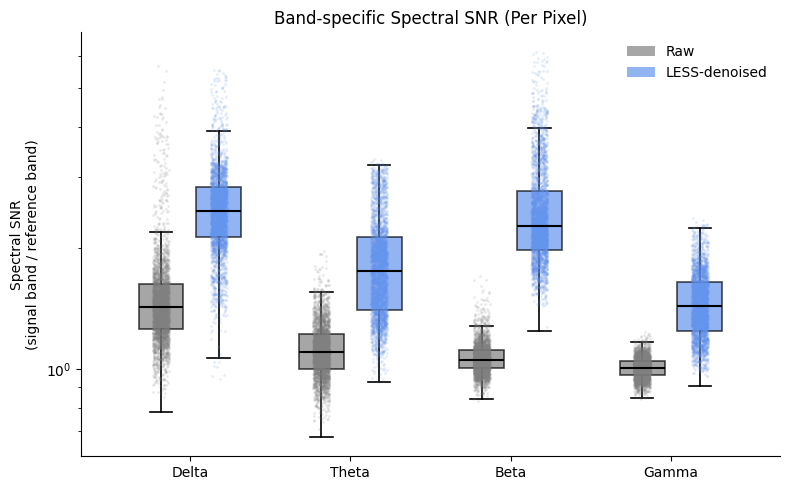

In [53]:
fig, ax = plot_pixelwise_band_snr_boxplot(
    snr_pixelwise_results,
    title="Band-specific Spectral SNR (Per Pixel)",
    show_points=True,
    point_alpha=0.10,
    point_size=2.5,
    jitter=0.05,
    showfliers=False,
    random_seed=0,
)
plt.show()

In [47]:
def compute_residual_movie(movie_raw, movie_denoised):
    """
    Compute the residual movie (raw - denoised).

    Parameters
    ----------
    movie_raw : np.ndarray
        Raw movie with shape (t, x, y).
    movie_denoised : np.ndarray
        LESS-denoised movie with shape (t, x, y).

    Returns
    -------
    residual : np.ndarray
        Residual movie with shape (t, x, y).
    """
    if movie_raw.shape != movie_denoised.shape:
        raise ValueError("Raw and denoised movies must have the same shape.")

    return movie_raw - movie_denoised

def plot_residual_frames(
    residual,
    n_frames=6,
    percentiles=(1, 99),
    title="Residual frames (Raw − LESS)",
    cmap="RdBu_r",
):
    """
    Plot representative frames from the residual movie.

    Parameters
    ----------
    residual : np.ndarray
        Residual movie with shape (t, x, y).
    n_frames : int
        Number of frames to show.
    percentiles : tuple
        Percentile range for symmetric color scaling.
    title : str
        Figure title.
    cmap : str
        Colormap.

    Returns
    -------
    fig, axes
    """
    t = residual.shape[0]

    # choose evenly spaced frames
    frame_idx = np.linspace(0, t - 1, n_frames).astype(int)

    # compute symmetric color limits
    v = np.nanpercentile(np.abs(residual), percentiles[1])
    vmin, vmax = -v, v

    fig, axes = plt.subplots(1, n_frames, figsize=(2.8 * n_frames, 3))

    for ax, i in zip(axes, frame_idx):
        im = ax.imshow(residual[i], cmap=cmap, vmin=vmin, vmax=vmax)
        ax.set_title(f"t = {i}")
        ax.axis("off")

    fig.suptitle(title)

    cbar = fig.colorbar(im, ax=axes.ravel().tolist(), shrink=0.8)
    cbar.set_label("Residual signal")

    fig.tight_layout()

    return fig, axes

def plot_raw_denoised_residual_comparison(
    movie_raw,
    movie_denoised,
    frame_index=None,
    percentiles=(1, 99),
):
    """
    Plot raw, denoised, and residual frames side-by-side.

    Parameters
    ----------
    movie_raw : np.ndarray
        Raw movie (t, x, y).
    movie_denoised : np.ndarray
        Denoised movie (t, x, y).
    frame_index : int or None
        Frame to plot. If None, use middle frame.
    percentiles : tuple
        Percentiles used for color scaling.

    Returns
    -------
    fig, axes
    """
    residual = movie_raw - movie_denoised

    if frame_index is None:
        frame_index = movie_raw.shape[0] // 2

    raw_frame = movie_raw[frame_index]
    den_frame = movie_denoised[frame_index]
    res_frame = residual[frame_index]

    v = np.nanpercentile(np.abs(raw_frame), percentiles[1])

    fig, axes = plt.subplots(1, 3, figsize=(9, 3))

    im0 = axes[0].imshow(raw_frame, cmap="RdBu_r", vmin=-v, vmax=v)
    axes[0].set_title("Raw")
    axes[0].axis("off")

    im1 = axes[1].imshow(den_frame, cmap="RdBu_r", vmin=-v, vmax=v)
    axes[1].set_title("LESS-denoised")
    axes[1].axis("off")

    v_res = np.nanpercentile(np.abs(res_frame), percentiles[1])

    im2 = axes[2].imshow(res_frame, cmap="RdBu_r", vmin=-v_res, vmax=v_res)
    axes[2].set_title("Residual")
    axes[2].axis("off")

    fig.colorbar(im2, ax=axes.ravel().tolist(), shrink=0.8)

    fig.tight_layout()

    return fig, axes

def plot_residual_variance_map(residual):
    """
    Plot spatial variance of the residual across time.

    Parameters
    ----------
    residual : np.ndarray
        Residual movie (t, x, y).

    Returns
    -------
    fig, ax
    """
    var_map = np.nanvar(residual, axis=0)

    fig, ax = plt.subplots(figsize=(5, 4))

    #var_map = np.log10(var_map)
    im = ax.imshow(var_map, cmap="magma")
    ax.set_title("Residual variance map")
    ax.axis("off")

    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label("Variance")

    fig.tight_layout()

    return fig, ax

def plot_normalized_residual_variance_map(movie_raw, residual):
    """
    Plot the pixelwise residual variance normalized by the raw-movie variance.

    Parameters
    ----------
    movie_raw : np.ndarray
        Raw movie with shape (t, x, y).
    residual : np.ndarray
        Residual movie with shape (t, x, y).

    Returns
    -------
    fig, ax
        Matplotlib figure and axes.
    """
    if movie_raw.shape != residual.shape:
        raise ValueError("`movie_raw` and `residual` must have the same shape.")

    raw_var_map = np.nanvar(movie_raw, axis=0)
    residual_var_map = np.nanvar(residual, axis=0)

    # Compute normalized variance safely
    norm_var_map = np.full_like(raw_var_map, np.nan, dtype=float)
    valid = raw_var_map > 0
    norm_var_map[valid] = residual_var_map[valid] / raw_var_map[valid]

    fig, ax = plt.subplots(figsize=(5, 4))

    # Log scale helps visualize spatial structure over a wide dynamic range
    norm_var_map_log = np.log10(norm_var_map)
    im = ax.imshow(norm_var_map_log, cmap="magma")

    ax.set_title("Residual variance / raw variance")
    ax.axis("off")

    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label("log10(residual variance / raw variance)")

    fig.tight_layout()

    return fig, ax


C:\Users\Katie\AppData\Local\Temp\ipykernel_18588\2275516598.py:127: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()
C:\Users\Katie\AppData\Local\Temp\ipykernel_18588\2275516598.py:144: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var_map = np.nanvar(residual, axis=0)


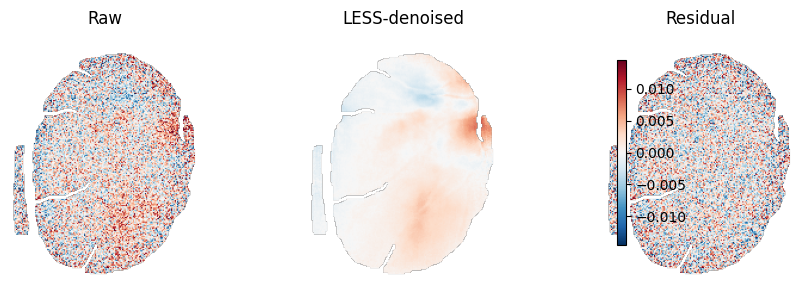

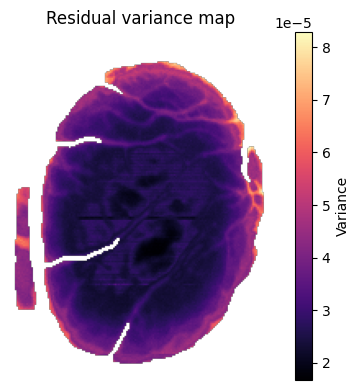

C:\Users\Katie\AppData\Local\Temp\ipykernel_18588\2275516598.py:179: RuntimeWarning: Degrees of freedom <= 0 for slice.
  raw_var_map = np.nanvar(movie_raw, axis=0)
C:\Users\Katie\AppData\Local\Temp\ipykernel_18588\2275516598.py:180: RuntimeWarning: Degrees of freedom <= 0 for slice.
  residual_var_map = np.nanvar(residual, axis=0)


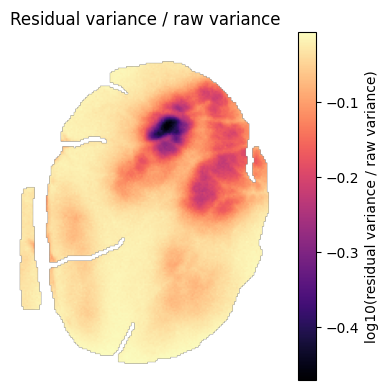

In [48]:
# Compute residual
residual = compute_residual_movie(movie_noisy, movie_denoised)

# 1) Raw / denoised / residual comparison
plot_raw_denoised_residual_comparison(
    movie_noisy,
    movie_denoised,
    frame_index=movie_noisy.shape[0] // 2,
)

# 3) Residual spatial variance
plot_residual_variance_map(residual)

plt.show()

# 4) Normalized residual spatial variance
fig, ax = plot_normalized_residual_variance_map(movie_noisy, residual)
plt.show()

In [63]:
def temporal_autocorrelation(signal, max_lag):
    """
    Compute normalized autocorrelation of a 1D signal.

    Parameters
    ----------
    signal : np.ndarray
        Time series.
    max_lag : int
        Maximum lag to compute.

    Returns
    -------
    acorr : np.ndarray
        Autocorrelation for lags 0..max_lag
    """

    corr = sp.signal.correlate(signal, signal, mode="full")
    mid = len(corr) // 2

    corr = corr[mid:mid + max_lag + 1]
    corr /= corr[0]

    return corr

def compute_residual_autocorrelation(residual, mask=None, max_lag=50, max_pixels=5000):
    """
    Compute mean temporal autocorrelation of residual pixels.

    Parameters
    ----------
    residual : np.ndarray
        Residual movie (t, x, y)
    mask : np.ndarray or None
        Boolean spatial mask
    max_lag : int
        Maximum lag (frames)
    max_pixels : int
        Number of pixels to sample

    Returns
    -------
    lags : np.ndarray
    mean_acorr : np.ndarray
    sem_acorr : np.ndarray
    """

    traces, _ = _flatten_valid_pixels(residual, mask)

    rng = np.random.default_rng(0)

    if traces.shape[1] > max_pixels:
        idx = rng.choice(traces.shape[1], max_pixels, replace=False)
        traces = traces[:, idx]

    acorrs = []

    for i in range(traces.shape[1]):
        ac = temporal_autocorrelation(traces[:, i], max_lag)
        acorrs.append(ac)

    acorrs = np.array(acorrs)

    mean_acorr = np.nanmean(acorrs, axis=0)
    sem_acorr = np.nanstd(acorrs, axis=0) / np.sqrt(acorrs.shape[0])

    lags = np.arange(max_lag + 1)

    return lags, mean_acorr, sem_acorr

def plot_residual_autocorrelation(lags, mean_acorr, sem_acorr, fps=157):
    """
    Plot residual temporal autocorrelation.
    """

    time = lags / fps

    fig, ax = plt.subplots(figsize=(5,4))

    ax.plot(time, mean_acorr, color="black")
    ax.fill_between(time,
                    mean_acorr-sem_acorr,
                    mean_acorr+sem_acorr,
                    alpha=0.3)

    #ax.axhline(0, color="grey", linestyle="--")

    ax.set_xlabel("Lag (s)")
    ax.set_ylabel("Autocorrelation")
    ax.set_title("Residual temporal autocorrelation")

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    plt.tight_layout()

    return fig, ax


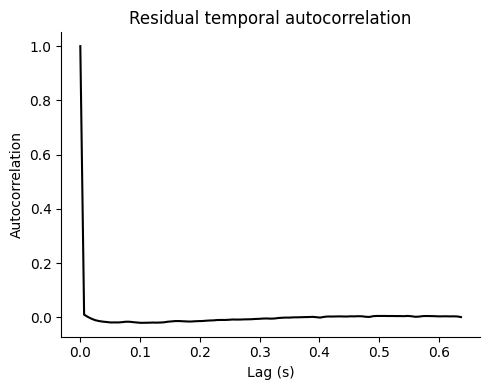

In [64]:
lags, mean_acorr, sem_acorr = compute_residual_autocorrelation(
    residual,
    mask=None,
    max_lag=100
)

fig, ax = plot_residual_autocorrelation(lags, mean_acorr, sem_acorr, fps=157)

In [14]:
def compute_residual_psd_comparison(
    movie_raw,
    movie_denoised,
    fps,
    mask=None,
    nperseg=None,
    noverlap=None,
    detrend="constant",
    window="hann",
    max_pixels=None,
    random_seed=0,
):
    """
    Compute mean pixelwise PSDs for the raw movie, denoised movie, and residual.

    Parameters
    ----------
    movie_raw : np.ndarray
        Raw movie with shape (t, x, y).
    movie_denoised : np.ndarray
        LESS-denoised movie with shape (t, x, y).
    fps : float
        Sampling rate in Hz.
    mask : np.ndarray or None, optional
        Boolean spatial mask with shape (x, y). True = include pixel.
    nperseg : int or None, optional
        Segment length for Welch PSD. If None, uses min(1024, n_timepoints).
    noverlap : int or None, optional
        Overlap between Welch segments. If None, defaults to nperseg // 2.
    detrend : str or callable, optional
        Detrending passed to scipy.signal.welch.
    window : str or tuple or array_like, optional
        Window passed to scipy.signal.welch.
    max_pixels : int or None, optional
        If provided, randomly subsample up to this many valid pixels.
    random_seed : int, optional
        Random seed used if `max_pixels` is not None.

    Returns
    -------
    results : dict
        Dictionary containing frequency axis and mean/SEM PSDs for
        raw, denoised, and residual movies.
    """
    if movie_raw.shape != movie_denoised.shape:
        raise ValueError(
            f"`movie_raw` and `movie_denoised` must have the same shape, "
            f"got {movie_raw.shape} and {movie_denoised.shape}"
        )

    movie_residual = compute_residual_movie(movie_raw, movie_denoised)

    freqs, mean_psd_raw, sem_psd_raw, n_pixels_raw = compute_mean_pixel_psd(
        movie_raw,
        fps=fps,
        mask=mask,
        nperseg=nperseg,
        noverlap=noverlap,
        detrend=detrend,
        window=window,
        max_pixels=max_pixels,
        random_seed=random_seed,
    )

    freqs_den, mean_psd_denoised, sem_psd_denoised, n_pixels_denoised = compute_mean_pixel_psd(
        movie_denoised,
        fps=fps,
        mask=mask,
        nperseg=nperseg,
        noverlap=noverlap,
        detrend=detrend,
        window=window,
        max_pixels=max_pixels,
        random_seed=random_seed,
    )

    freqs_res, mean_psd_residual, sem_psd_residual, n_pixels_residual = compute_mean_pixel_psd(
        movie_residual,
        fps=fps,
        mask=mask,
        nperseg=nperseg,
        noverlap=noverlap,
        detrend=detrend,
        window=window,
        max_pixels=max_pixels,
        random_seed=random_seed,
    )

    if not (np.allclose(freqs, freqs_den) and np.allclose(freqs, freqs_res)):
        raise RuntimeError("Frequency axes do not match across PSD calculations.")

    return {
        "freqs": freqs,
        "mean_psd_raw": mean_psd_raw,
        "sem_psd_raw": sem_psd_raw,
        "n_pixels_raw": n_pixels_raw,
        "mean_psd_denoised": mean_psd_denoised,
        "sem_psd_denoised": sem_psd_denoised,
        "n_pixels_denoised": n_pixels_denoised,
        "mean_psd_residual": mean_psd_residual,
        "sem_psd_residual": sem_psd_residual,
        "n_pixels_residual": n_pixels_residual,
    }


def plot_residual_psd_vs_raw(
    residual_psd_results,
    fmin=0,
    fmax=None,
    show_sem=False,
    logy=True,
    raw_color="grey",
    denoised_color="cornflowerblue",
    residual_color="black",
    title="Mean pixelwise PSD: raw, LESS-denoised, and residual",
    ax=None,
):
    """
    Plot mean PSDs for raw, denoised, and residual movies.

    Parameters
    ----------
    residual_psd_results : dict
        Output from `compute_residual_psd_comparison`.
    fmin : float, optional
        Minimum frequency to display.
    fmax : float or None, optional
        Maximum frequency to display.
    show_sem : bool, optional
        If True, add shaded SEM bands.
    logy : bool, optional
        If True, use a log scale for the y-axis.
    raw_color : str, optional
        Color for raw PSD.
    denoised_color : str, optional
        Color for denoised PSD.
    residual_color : str, optional
        Color for residual PSD.
    title : str, optional
        Plot title.
    ax : matplotlib.axes.Axes or None, optional
        Existing axes to plot on. If None, a new figure is created.

    Returns
    -------
    fig, ax : matplotlib Figure and Axes
    """
    freqs = residual_psd_results["freqs"]

    keep = freqs >= fmin
    if fmax is not None:
        keep &= freqs <= fmax

    freqs_plot = freqs[keep]

    raw_plot = residual_psd_results["mean_psd_raw"][keep]
    raw_sem_plot = residual_psd_results["sem_psd_raw"][keep]

    den_plot = residual_psd_results["mean_psd_denoised"][keep]
    den_sem_plot = residual_psd_results["sem_psd_denoised"][keep]

    res_plot = residual_psd_results["mean_psd_residual"][keep]
    res_sem_plot = residual_psd_results["sem_psd_residual"][keep]

    if ax is None:
        fig, ax = plt.subplots(figsize=(7, 4.5))
    else:
        fig = ax.figure

    ax.plot(freqs_plot, raw_plot, linewidth=2, color=raw_color, label="Raw")
    ax.plot(freqs_plot, den_plot, linewidth=2, color=denoised_color, label="LESS-denoised")
    ax.plot(freqs_plot, res_plot, linewidth=2, color=residual_color, label="Residual")

    if show_sem:
        ax.fill_between(freqs_plot, raw_plot - raw_sem_plot, raw_plot + raw_sem_plot,
                        color=raw_color, alpha=0.15)
        ax.fill_between(freqs_plot, den_plot - den_sem_plot, den_plot + den_sem_plot,
                        color=denoised_color, alpha=0.15)
        ax.fill_between(freqs_plot, res_plot - res_sem_plot, res_plot + res_sem_plot,
                        color=residual_color, alpha=0.12)

    ax.set_xlabel("Frequency (Hz)")
    ax.set_ylabel("Power spectral density")
    ax.set_title(title)
    ax.legend(frameon=False)

    if logy:
        ax.set_yscale("log")

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    fig.tight_layout()

    return fig, ax


def plot_residual_fraction_of_raw_psd(
    residual_psd_results,
    fmin=0,
    fmax=None,
    raw_color="grey",
    residual_color="black",
    title="Residual PSD as a fraction of raw PSD",
    ax=None,
):
    """
    Plot the fraction of the raw PSD that remains in the residual:
        residual PSD / raw PSD

    Parameters
    ----------
    residual_psd_results : dict
        Output from `compute_residual_psd_comparison`.
    fmin : float, optional
        Minimum frequency to display.
    fmax : float or None, optional
        Maximum frequency to display.
    raw_color : str, optional
        Unused here, included only for style consistency.
    residual_color : str, optional
        Color for the fraction curve.
    title : str, optional
        Plot title.
    ax : matplotlib.axes.Axes or None, optional
        Existing axes to plot on. If None, a new figure is created.

    Returns
    -------
    fig, ax : matplotlib Figure and Axes
    """
    freqs = residual_psd_results["freqs"]
    raw_psd = residual_psd_results["mean_psd_raw"]
    residual_psd = residual_psd_results["mean_psd_residual"]

    keep = freqs >= fmin
    if fmax is not None:
        keep &= freqs <= fmax

    freqs_plot = freqs[keep]
    raw_plot = raw_psd[keep]
    residual_plot = residual_psd[keep]

    frac = np.full_like(raw_plot, np.nan, dtype=float)
    valid = raw_plot > 0
    frac[valid] = residual_plot[valid] / raw_plot[valid]

    if ax is None:
        fig, ax = plt.subplots(figsize=(7, 3.8))
    else:
        fig = ax.figure

    ax.plot(freqs_plot, frac, color=residual_color, linewidth=2)
    ax.axhline(1.0, color="grey", linestyle="--", linewidth=1)

    ax.set_xlabel("Frequency (Hz)")
    ax.set_ylabel("Residual / Raw PSD")
    ax.set_title(title)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    fig.tight_layout()

    return fig, ax

In [ ]:
# ---- Compute PSDs for raw, denoised, and residual movies ----
residual_psd_results = compute_residual_psd_comparison(
    movie_raw=movie_noisy,
    movie_denoised=movie_denoised,
    fps=157,
    mask=None,          # replace with cortex mask if available
    nperseg=1024,
    noverlap=512,
    detrend="constant",
    window="hann",
    max_pixels=None,
    random_seed=0,
)

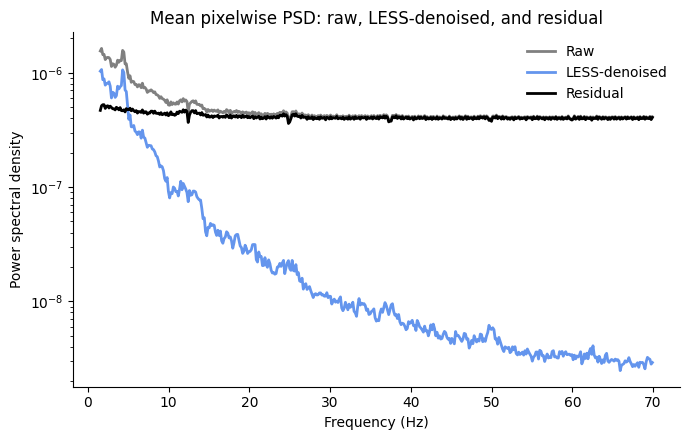

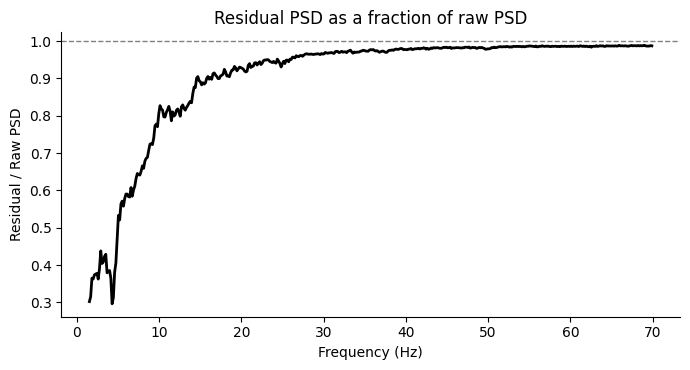

In [100]:
# ---- Plot PSD comparison ----
fig, ax = plot_residual_psd_vs_raw(
    residual_psd_results,
    fmin=1.5,
    fmax=70,
    show_sem=False,
    logy=True,
    raw_color="grey",
    denoised_color="cornflowerblue",
    residual_color="black",
    title="Mean pixelwise PSD: raw, LESS-denoised, and residual",
)
plt.show()

# ---- Optional: plot residual PSD as a fraction of raw PSD ----
fig, ax = plot_residual_fraction_of_raw_psd(
    residual_psd_results,
    fmin=1.5,
    fmax=70,
    residual_color="black",
    title="Residual PSD as a fraction of raw PSD",
)
plt.show()

### Semi-Synthetic Validation (Adding Noise to Real Movie)

In [ ]:
def compute_residual_noise_from_movies(movie_raw, movie_denoised):
    """
    Compute residual noise directly from an already-loaded raw movie and its
    already-loaded LESS-denoised version.

    Parameters
    ----------
    movie_raw : np.ndarray
        Raw movie, shape (T, X, Y).
    movie_denoised : np.ndarray
        LESS-denoised movie, shape (T, X, Y).

    Returns
    -------
    residual_noise : np.ndarray
        Residual movie, shape (T, X, Y).
    """
    if movie_raw.shape != movie_denoised.shape:
        raise ValueError("`movie_raw` and `movie_denoised` must have the same shape.")

    return movie_raw - movie_denoised


def sample_residual_noise_like(residual_noise, random_seed=0):
    """
    Generate a new synthetic noise movie by resampling values from the residual.

    Parameters
    ----------
    residual_noise : np.ndarray
        Residual noise movie, shape (T, X, Y).
    random_seed : int, optional
        Random seed.

    Returns
    -------
    sampled_noise : np.ndarray
        Synthetic noise movie with the same shape as `residual_noise`.

    Notes
    -----
    This preserves the marginal distribution of residual values but destroys
    spatial and temporal correlations.
    """
    rng = np.random.default_rng(random_seed)

    residual_flat = residual_noise[np.isfinite(residual_noise)]
    if residual_flat.size == 0:
        raise ValueError("Residual contains no finite values.")

    sampled_flat = rng.choice(residual_flat, size=residual_noise.size, replace=True)
    sampled_noise = sampled_flat.reshape(residual_noise.shape)

    # Preserve NaN mask if present
    sampled_noise[~np.isfinite(residual_noise)] = np.nan

    return sampled_noise


def make_semi_synthetic_movie_from_residual(
    movie_clean_proxy,
    residual_noise,
    raw_mask,
    binning,
    noise_scale,
    random_seed=0,
):
    """
    Create a semi-synthetic corrupted movie by adding scaled, resampled residual
    noise to a high-SNR movie.

    Parameters
    ----------
    movie_clean_proxy : np.ndarray
        High-SNR movie treated as pseudo-ground-truth, shape (T, X, Y).
    residual_noise : np.ndarray
        Residual-based native noise estimate, shape (T, X, Y).
    noise_scale : float
        Noise scaling factor (e.g. 2, 4, 8).
    random_seed : int, optional
        Random seed.

    Returns
    -------
    movie_corrupted : np.ndarray
        Corrupted movie.
    sampled_noise : np.ndarray
        Resampled noise movie before scaling.
    """
    if movie_clean_proxy.shape != residual_noise.shape:
        raise ValueError("`movie_clean_proxy` and `residual_noise` must have the same shape.")

    rng = np.random.default_rng(random_seed)

    valid_noise = residual_noise[np.isfinite(residual_noise)]
    if valid_noise.size == 0:
        raise ValueError("`residual_noise` contains no finite values.")

    sampled_noise = rng.choice(valid_noise, size=residual_noise.shape, replace=True).astype(float)

    # Preserve NaN mask from the clean movie if present
    invalid_mask = ~np.isfinite(movie_clean_proxy)
    sampled_noise[invalid_mask] = np.nan

    movie_corrupted = movie_clean_proxy + noise_scale * sampled_noise

    movie_corrupted = movie_corrupted*mask # had to change code, not certain this will work

    return movie_corrupted, sampled_noise


def summarize_noise_levels(movie_clean_proxy, residual_noise):
    """
    Print simple summary statistics for the proxy-clean movie and residual noise.

    Parameters
    ----------
    movie_clean_proxy : np.ndarray
        High-SNR movie.
    residual_noise : np.ndarray
        Residual noise movie.
    """
    clean_vals = movie_clean_proxy[np.isfinite(movie_clean_proxy)]
    noise_vals = residual_noise[np.isfinite(residual_noise)]

    clean_std = np.std(clean_vals)
    noise_std = np.std(noise_vals)

    print(f"Clean-proxy global std: {clean_std:.6g}")
    print(f"Residual-noise global std: {noise_std:.6g}")
    if clean_std > 0:
        print(f"Noise / clean std ratio: {noise_std / clean_std:.6g}")

In [ ]:
frames_to_crop = 10000

# Choose your highest-SNR movie
movie_clean_proxy = np.nan_to_num(movie_noisy)[:frames_to_crop]

# Compute residual directly from the movies you already have
residual_noise = compute_residual_noise_from_movies(movie_clean_proxy, movie_denoised[:frames_to_crop])

# Generate corrupted movies

movie_4x, sampled_noise_4x = make_semi_synthetic_movie_from_residual(
    movie_clean_proxy,
    residual_noise,
    mask,
    noise_scale=4,
    random_seed=1,
)

movie_6x, sampled_noise_6x = make_semi_synthetic_movie_from_residual(
    movie_clean_proxy,
    residual_noise,
    mask,
    noise_scale=6,
    random_seed=2,
)

movie_8x, sampled_noise_8x = make_semi_synthetic_movie_from_residual(
    movie_clean_proxy,
    residual_noise,
    mask
    noise_scale=8,
    random_seed=2,
)

movie_12x, sampled_noise_12x = make_semi_synthetic_movie_from_residual(
    movie_clean_proxy,
    residual_noise,
    mask
    noise_scale=12,
    random_seed=2,
)

In [29]:
def summarize_movie_basic_stats(movie, name="movie"):
    """
    Print simple summary statistics for a movie.

    Parameters
    ----------
    movie : np.ndarray
        Movie with shape (T, X, Y).
    name : str, optional
        Name used in printed output.
    """
    vals = movie[np.isfinite(movie)]

    print(f"{name}:")
    print(f"  shape        = {movie.shape}")
    print(f"  mean         = {np.mean(vals):.6g}")
    print(f"  std          = {np.std(vals):.6g}")
    print(f"  min / max    = {np.min(vals):.6g} / {np.max(vals):.6g}")
    print(f"  p1 / p99     = {np.percentile(vals, 1):.6g} / {np.percentile(vals, 99):.6g}")
    print()


def summarize_movie_set(movies, names):
    """
    Print summary statistics for a list of movies.

    Parameters
    ----------
    movies : list of np.ndarray
        Movies to summarize.
    names : list of str
        Names corresponding to each movie.
    """
    if len(movies) != len(names):
        raise ValueError("`movies` and `names` must have the same length.")

    for movie, name in zip(movies, names):
        summarize_movie_basic_stats(movie, name=name)


def plot_matched_frame_comparison(
    movies,
    names,
    frame_index=None,
    cmap="RdBu_r",
    shared_scale=True,
    percentile_clip=(1, 99),
    figsize_per_panel=(3.2, 3.2),
):
    """
    Plot one matched frame from several movies side by side.

    Parameters
    ----------
    movies : list of np.ndarray
        Movies with shape (T, X, Y).
    names : list of str
        Labels for each movie.
    frame_index : int or None, optional
        Frame to display. If None, uses the middle frame.
    cmap : str, optional
        Colormap.
    shared_scale : bool, optional
        If True, use the same color scale across panels.
    percentile_clip : tuple, optional
        Percentiles used for robust color scaling.
    figsize_per_panel : tuple, optional
        Figure size per panel.

    Returns
    -------
    fig, axes
    """
    if len(movies) != len(names):
        raise ValueError("`movies` and `names` must have the same length.")

    n = len(movies)
    T = movies[0].shape[0]

    if frame_index is None:
        frame_index = T // 2

    frames = [movie[frame_index] for movie in movies]

    if shared_scale:
        all_vals = np.concatenate([f[np.isfinite(f)] for f in frames])
        vmin, vmax = np.percentile(all_vals, percentile_clip)
        limits = [(vmin, vmax)] * n
    else:
        limits = [tuple(np.percentile(f[np.isfinite(f)], percentile_clip)) for f in frames]

    fig, axes = plt.subplots(
        1, n,
        figsize=(figsize_per_panel[0] * n, figsize_per_panel[1]),
        constrained_layout=True
    )

    if n == 1:
        axes = [axes]

    for ax, frame, name, (vmin, vmax) in zip(axes, frames, names, limits):
        im = ax.imshow(frame, cmap=cmap, vmin=vmin, vmax=vmax)
        ax.set_title(name)
        ax.axis("off")

    fig.colorbar(im, ax=axes, shrink=0.85)
    return fig, axes


def plot_frame_sequence_comparison(
    movies,
    names,
    n_frames=5,
    frame_start=None,
    frame_end=None,
    cmap="RdBu_r",
    shared_scale=True,
    percentile_clip=(1, 99),
):
    """
    Plot a short frame sequence for several movies.

    Rows = movies, columns = frames.

    Parameters
    ----------
    movies : list of np.ndarray
        Movies with shape (T, X, Y).
    names : list of str
        Labels for each movie.
    n_frames : int, optional
        Number of frames to display.
    frame_start : int or None, optional
        Start frame. If None, chooses a centered window.
    frame_end : int or None, optional
        End frame (exclusive). If None, chooses a centered window.
    cmap : str, optional
        Colormap.
    shared_scale : bool, optional
        If True, use one common color scale across all panels.
    percentile_clip : tuple, optional
        Percentiles used for robust color scaling.

    Returns
    -------
    fig, axes
    """
    if len(movies) != len(names):
        raise ValueError("`movies` and `names` must have the same length.")

    T = movies[0].shape[0]

    if frame_start is None or frame_end is None:
        center = T // 2
        half_span = max(n_frames // 2, 1)
        frame_start = max(0, center - half_span)
        frame_end = min(T, frame_start + n_frames)

    frame_idx = np.linspace(frame_start, frame_end - 1, n_frames).astype(int)

    panel_vals = []
    for movie in movies:
        for idx in frame_idx:
            panel_vals.append(movie[idx][np.isfinite(movie[idx])])

    if shared_scale:
        all_vals = np.concatenate(panel_vals)
        vmin, vmax = np.percentile(all_vals, percentile_clip)

    fig, axes = plt.subplots(
        len(movies), n_frames,
        figsize=(2.4 * n_frames, 2.6 * len(movies)),
        constrained_layout=True
    )

    if len(movies) == 1:
        axes = axes[None, :]
    if n_frames == 1:
        axes = axes[:, None]

    last_im = None
    for i, (movie, name) in enumerate(zip(movies, names)):
        for j, idx in enumerate(frame_idx):
            frame = movie[idx]

            if shared_scale:
                this_vmin, this_vmax = vmin, vmax
            else:
                this_vmin, this_vmax = np.percentile(frame[np.isfinite(frame)], percentile_clip)

            im = axes[i, j].imshow(frame, cmap=cmap, vmin=this_vmin, vmax=this_vmax)
            last_im = im
            axes[i, j].axis("off")

            if i == 0:
                axes[i, j].set_title(f"t = {idx}")
            if j == 0:
                axes[i, j].set_ylabel(name)

    fig.colorbar(last_im, ax=axes, shrink=0.85)
    return fig, axes


def compare_movies_to_reference(movie_reference, movies, names):
    """
    Print simple difference statistics relative to a reference movie.

    Parameters
    ----------
    movie_reference : np.ndarray
        Reference movie, shape (T, X, Y).
    movies : list of np.ndarray
        Movies to compare against the reference.
    names : list of str
        Labels for each comparison movie.
    """
    if len(movies) != len(names):
        raise ValueError("`movies` and `names` must have the same length.")

    ref_vals = movie_reference[np.isfinite(movie_reference)]
    ref_std = np.std(ref_vals)

    print("Difference relative to reference:")
    for movie, name in zip(movies, names):
        diff = movie - movie_reference
        vals = diff[np.isfinite(diff)]

        print(f"{name}:")
        print(f"  diff mean     = {np.mean(vals):.6g}")
        print(f"  diff std      = {np.std(vals):.6g}")
        print(f"  diff RMS      = {np.sqrt(np.mean(vals**2)):.6g}")
        if ref_std > 0:
            print(f"  diff std / ref std = {np.std(vals) / ref_std:.6g}")
        print()


def quick_psd_check(
    movies,
    names,
    fps,
    mask=None,
    fmax=80,
    nperseg=1024,
    noverlap=512,
    max_pixels=None,
):
    """
    Plot mean pixelwise PSDs for a set of movies for quick comparison.

    Parameters
    ----------
    movies : list of np.ndarray
        Movies with shape (T, X, Y).
    names : list of str
        Labels for each movie.
    fps : float
        Sampling rate in Hz.
    mask : np.ndarray or None, optional
        Boolean mask with shape (X, Y).
    fmax : float, optional
        Maximum frequency to display.
    nperseg, noverlap, max_pixels
        Passed to `compute_mean_pixel_psd`.

    Returns
    -------
    fig, ax
    """
    if len(movies) != len(names):
        raise ValueError("`movies` and `names` must have the same length.")

    fig, ax = plt.subplots(figsize=(7, 4.5))

    colors = ["black", "grey", "cornflowerblue", "tomato", "mediumseagreen", "mediumpurple"]

    for i, (movie, name) in enumerate(zip(movies, names)):
        freqs, mean_psd, _, _ = compute_mean_pixel_psd(
            movie,
            fps=fps,
            mask=mask,
            nperseg=nperseg,
            noverlap=noverlap,
            max_pixels=max_pixels,
        )

        keep = freqs <= fmax
        ax.plot(freqs[keep], mean_psd[keep], linewidth=2, color=colors[i % len(colors)], label=name)

    ax.set_xlabel("Frequency (Hz)")
    ax.set_ylabel("Power spectral density")
    ax.set_title("Quick PSD comparison")
    ax.set_yscale("log")
    ax.legend(frameon=False)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    fig.tight_layout()

    return fig, ax

Clean proxy:
  shape        = (10000, 213, 160)
  mean         = -1.08815e-06
  std          = 0.00470052
  min / max    = -0.0604201 / 0.138763
  p1 / p99     = -0.0131254 / 0.0133097

4x noise:
  shape        = (10000, 213, 160)
  mean         = -1.88747e-06
  std          = 0.0234263
  min / max    = -0.220422 / 0.540789
  p1 / p99     = -0.055546 / 0.055792

6x noise:
  shape        = (10000, 213, 160)
  mean         = -1.31952e-06
  std          = 0.0344639
  min / max    = -0.260742 / 0.425789
  p1 / p99     = -0.081823 / 0.0821993

8x noise:
  shape        = (10000, 213, 160)
  mean         = -1.14296e-06
  std          = 0.0456329
  min / max    = -0.346124 / 0.566785
  p1 / p99     = -0.108409 / 0.108907

12x noise:
  shape        = (10000, 213, 160)
  mean         = -7.89826e-07
  std          = 0.0681056
  min / max    = -0.516886 / 0.848777
  p1 / p99     = -0.161875 / 0.162624

Difference relative to reference:
4x noise:
  diff mean     = -3.82466e-08
  diff std      = 0.0

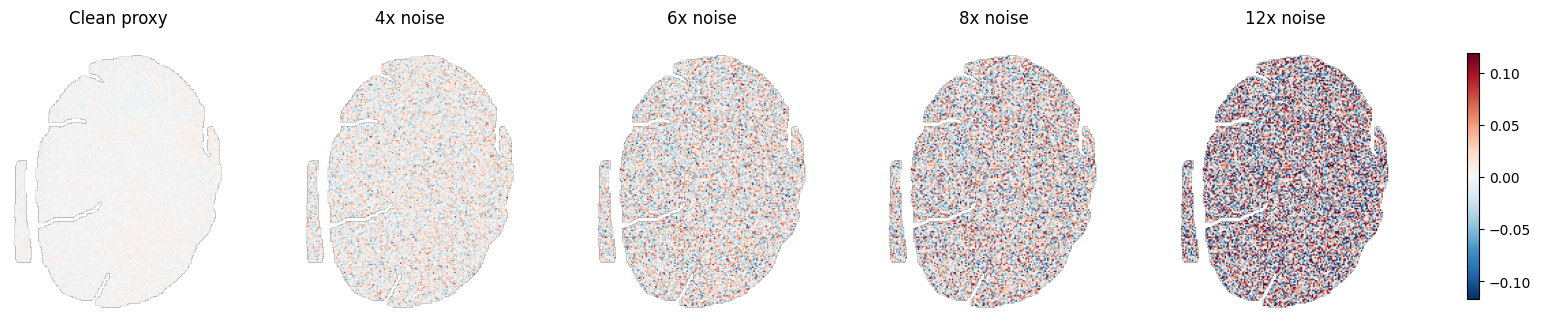

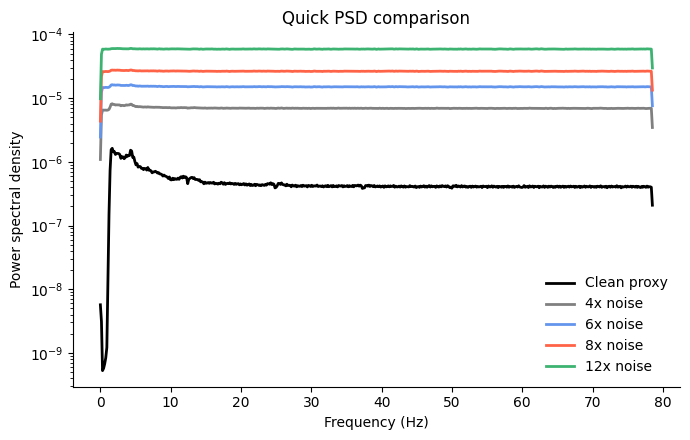

In [20]:
movies = [movie_clean_proxy, movie_4x, movie_6x, movie_8x, movie_12x]
movies_1 = [movie_noisy, movie_4x, movie_6x, movie_8x, movie_12x]
names = ["Clean proxy", "4x noise", "6x noise", "8x noise", "12x noise"]

# 1) Basic summary stats
summarize_movie_set(movies, names)

# 2) Difference relative to clean proxy
compare_movies_to_reference(movie_clean_proxy, movies[1:], names[1:])

# 3) One matched frame
plot_matched_frame_comparison(
    movies_1,
    names,
    frame_index=movie_clean_proxy.shape[0] // 2,
    shared_scale=True,
    percentile_clip=(1, 99),
)
plt.show()

# 5) PSD sanity check
quick_psd_check(
    movies,
    names,
    fps=157,
    mask=None,      # replace with cortex mask if you have one
    fmax=80,
    nperseg=1024,
    noverlap=512,
    max_pixels=5000,
)
plt.show()

In [9]:
F0_map = np.loadtxt('Y:/Voltage/VisualConsciousness/Preprocessed/Visual/cfm005mjr/20251202/meas01/diagnostic/movieDFF/F0.csv', delimiter=",")
F0_map = np.rot90(F0_map)

In [10]:
def make_gaussian_noise_from_F0(
    F0_map,
    movie_shape,
    mask,
    a=0.2535,
    b=0.0,
    noise_scale=1.0,
    random_seed=0,
    min_F0=1e-8,
):
    """
    Generate a synthetic noise movie from an intensity-dependent Gaussian model:

        n(x,y,t) ~ N(0, (a * F0(x,y) + b) / F0(x,y)^2)

    Parameters
    ----------
    F0_map : np.ndarray
        2D baseline fluorescence map, shape (X, Y).
    movie_shape : tuple
        Shape of output movie, must be (T, X, Y).
    mask : np.ndarray
        Boolean or 0/1 spatial mask, shape (X, Y). This should already be
        correctly rescaled to match the movie.
    a : float, optional
        Coefficient from variance-mean fit.
    b : float, optional
        Offset from variance-mean fit.
    noise_scale : float, optional
        Additional multiplicative scaling factor for the generated noise.
    random_seed : int, optional
        Random seed.
    min_F0 : float, optional
        Minimum allowed F0 value to avoid division by zero / exploding variance.

    Returns
    -------
    noise_movie : np.ndarray
        Noise movie of shape (T, X, Y).
    sigma_map : np.ndarray
        Per-pixel standard deviation map, shape (X, Y).
    var_map : np.ndarray
        Per-pixel variance map, shape (X, Y).
    """
    if len(movie_shape) != 3:
        raise ValueError("`movie_shape` must be (T, X, Y).")

    T, X, Y = movie_shape

    if F0_map.shape != (X, Y):
        raise ValueError(
            f"`F0_map` shape {F0_map.shape} does not match spatial movie shape {(X, Y)}."
        )

    if mask.shape != (X, Y):
        raise ValueError(
            f"`mask` shape {mask.shape} does not match spatial movie shape {(X, Y)}."
        )

    rng = np.random.default_rng(random_seed)

    mask_bool = mask.astype(bool)

    # Safe F0 to avoid division by zero or huge variances
    F0_safe = np.array(F0_map, dtype=float, copy=True)
    F0_safe[~np.isfinite(F0_safe)] = np.nan
    F0_safe[F0_safe < min_F0] = min_F0

    # Variance model
    var_map = (a * F0_safe + b) / (F0_safe ** 2)

    # Clean up any pathological values
    var_map[~np.isfinite(var_map)] = np.nan
    var_map[var_map < 0] = np.nan

    sigma_map = np.sqrt(var_map)

    # Generate independent Gaussian noise for each pixel over time
    noise_movie = rng.standard_normal(size=movie_shape) * sigma_map[None, :, :]

    # Apply user-provided scale
    noise_movie = noise_scale * noise_movie

    # Apply mask
    noise_movie[:, ~mask_bool] = np.nan

    return noise_movie, sigma_map, var_map


def make_semi_synthetic_movie_from_F0_noise(
    movie_clean_proxy,
    F0_map,
    mask,
    a=0.2535,
    b=0.0,
    noise_scale=1.0,
    random_seed=0,
    min_F0=1e-8,
):
    """
    Create a semi-synthetic corrupted movie by adding intensity-dependent
    Gaussian noise to a high-SNR clean proxy movie.

    Parameters
    ----------
    movie_clean_proxy : np.ndarray
        High-SNR movie treated as pseudo-ground-truth, shape (T, X, Y).
    F0_map : np.ndarray
        2D baseline fluorescence map, shape (X, Y).
    mask : np.ndarray
        Boolean or 0/1 spatial mask, shape (X, Y), already correctly rescaled.
    a : float, optional
        Coefficient from variance-mean fit.
    b : float, optional
        Offset from variance-mean fit.
    noise_scale : float, optional
        Multiplicative factor applied to the modeled noise.
    random_seed : int, optional
        Random seed.
    min_F0 : float, optional
        Minimum allowed F0 to avoid division by zero.

    Returns
    -------
    movie_corrupted : np.ndarray
        Corrupted movie, shape (T, X, Y).
    noise_movie : np.ndarray
        Added synthetic noise movie, shape (T, X, Y).
    sigma_map : np.ndarray
        Per-pixel std map, shape (X, Y).
    var_map : np.ndarray
        Per-pixel variance map, shape (X, Y).
    """
    if movie_clean_proxy.ndim != 3:
        raise ValueError("`movie_clean_proxy` must have shape (T, X, Y).")

    T, X, Y = movie_clean_proxy.shape

    if F0_map.shape != (X, Y):
        raise ValueError(
            f"`F0_map` shape {F0_map.shape} does not match movie spatial shape {(X, Y)}."
        )

    if mask.shape != (X, Y):
        raise ValueError(
            f"`mask` shape {mask.shape} does not match movie spatial shape {(X, Y)}."
        )

    mask_bool = mask.astype(bool)

    noise_movie, sigma_map, var_map = make_gaussian_noise_from_F0(
        F0_map=F0_map,
        movie_shape=movie_clean_proxy.shape,
        mask=mask_bool,
        a=a,
        b=b,
        noise_scale=noise_scale,
        random_seed=random_seed,
        min_F0=min_F0,
    )

    movie_corrupted = movie_clean_proxy.astype(float) + noise_movie

    # Keep outside-mask region invalid
    movie_corrupted[:, ~mask_bool] = np.nan

    # Also preserve any NaNs already present in clean proxy
    invalid_clean = ~np.isfinite(movie_clean_proxy)
    movie_corrupted[invalid_clean] = np.nan
    noise_movie[invalid_clean] = np.nan

    return movie_corrupted, noise_movie, sigma_map, var_map


def summarize_F0_noise_model(F0_map, mask, a=0.2535, b=0.0, min_F0=1e-8):
    """
    Print summary statistics of the intensity-dependent Gaussian noise model.
    """
    if F0_map.shape != mask.shape:
        raise ValueError("`F0_map` and `mask` must have the same shape.")

    mask_bool = mask.astype(bool)

    F0_safe = np.array(F0_map, dtype=float, copy=True)
    F0_safe[~np.isfinite(F0_safe)] = np.nan
    F0_safe[F0_safe < min_F0] = min_F0

    var_map = (a * F0_safe + b) / (F0_safe ** 2)
    sigma_map = np.sqrt(var_map)

    vals_F0 = F0_safe[mask_bool & np.isfinite(F0_safe)]
    vals_var = var_map[mask_bool & np.isfinite(var_map)]
    vals_sigma = sigma_map[mask_bool & np.isfinite(sigma_map)]

    print(f"a = {a}")
    print(f"b = {b}")
    print(f"F0 in mask: min={np.min(vals_F0):.6g}, median={np.median(vals_F0):.6g}, max={np.max(vals_F0):.6g}")
    print(f"Noise variance in mask: min={np.min(vals_var):.6g}, median={np.median(vals_var):.6g}, max={np.max(vals_var):.6g}")
    print(f"Noise std in mask: min={np.min(vals_sigma):.6g}, median={np.median(vals_sigma):.6g}, max={np.max(vals_sigma):.6g}")

In [39]:
frames_to_crop = 500

# High-SNR movie used as pseudo-ground-truth
movie_clean_proxy = np.array(movie_noisy[:frames_to_crop], dtype=float)

# Make sure outside-mask region is invalid
movie_clean_proxy[:, ~mask.astype(bool)] = np.nan

# Optional: inspect model-implied noise levels
summarize_F0_noise_model(F0_map, mask, a=0.2535, b=0.0)

movie_2x, noise_2x, sigma_map, var_map = make_semi_synthetic_movie_from_F0_noise(
    movie_clean_proxy=movie_clean_proxy,
    F0_map=F0_map,
    mask=mask,
    a=0.2535,
    b=0.0,
    noise_scale=2,
    random_seed=1,
)

movie_4x, noise_4x, sigma_map, var_map = make_semi_synthetic_movie_from_F0_noise(
    movie_clean_proxy=movie_clean_proxy,
    F0_map=F0_map,
    mask=mask,
    a=0.2535,
    b=0.0,
    noise_scale=4,
    random_seed=1,
)

movie_6x, noise_6x, _, _ = make_semi_synthetic_movie_from_F0_noise(
    movie_clean_proxy=movie_clean_proxy,
    F0_map=F0_map,
    mask=mask,
    a=0.2535,
    b=0.0,
    noise_scale=6,
    random_seed=2,
)

movie_8x, noise_8x, _, _ = make_semi_synthetic_movie_from_F0_noise(
    movie_clean_proxy=movie_clean_proxy,
    F0_map=F0_map,
    mask=mask,
    a=0.2535,
    b=0.0,
    noise_scale=8,
    random_seed=3,
)

movie_12x, noise_12x, _, _ = make_semi_synthetic_movie_from_F0_noise(
    movie_clean_proxy=movie_clean_proxy,
    F0_map=F0_map,
    mask=mask,
    a=0.2535,
    b=0.0,
    noise_scale=12,
    random_seed=4,
)

a = 0.2535
b = 0.0
F0 in mask: min=2015.81, median=7284.37, max=12827.6
Noise variance in mask: min=1.97621e-05, median=3.48005e-05, max=0.000125756
Noise std in mask: min=0.00444545, median=0.0058992, max=0.0112141


Clean proxy:
  shape        = (500, 213, 160)
  mean         = -4.85861e-05
  std          = 0.00673172
  min / max    = -0.0604201 / 0.0625569
  p1 / p99     = -0.0161756 / 0.0162465

4x noise:
  shape        = (500, 213, 160)
  mean         = -4.1572e-05
  std          = 0.0260748
  min / max    = -0.172829 / 0.188232
  p1 / p99     = -0.062977 / 0.0629202

6x noise:
  shape        = (500, 213, 160)
  mean         = -5.125e-05
  std          = 0.0384057
  min / max    = -0.262663 / 0.269927
  p1 / p99     = -0.0929251 / 0.0927997

8x noise:
  shape        = (500, 213, 160)
  mean         = -3.93372e-05
  std          = 0.0508433
  min / max    = -0.333375 / 0.349072
  p1 / p99     = -0.123053 / 0.122918

12x noise:
  shape        = (500, 213, 160)
  mean         = -5.23972e-05
  std          = 0.075866
  min / max    = -0.533833 / 0.557077
  p1 / p99     = -0.183325 / 0.183298

Difference relative to reference:
4x noise:
  diff mean     = 7.01408e-06
  diff std      = 0.0251927
  dif

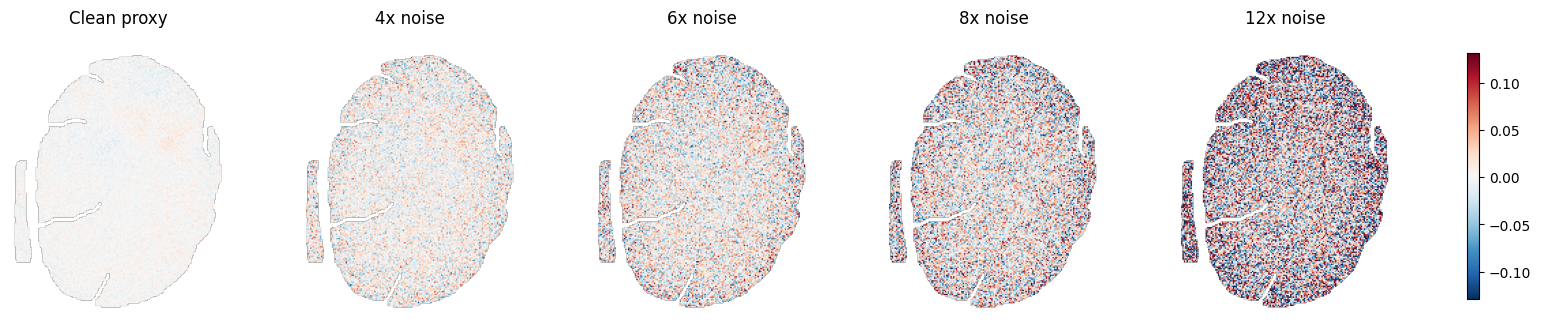

C:\Users\Katie\AppData\Local\Temp\ipykernel_18588\3617716725.py:149: UserWarning: nperseg=1024 is greater than signal length max(len(x), len(y)) = 500, using nperseg = 500
  freqs, psd = sp.signal.welch(


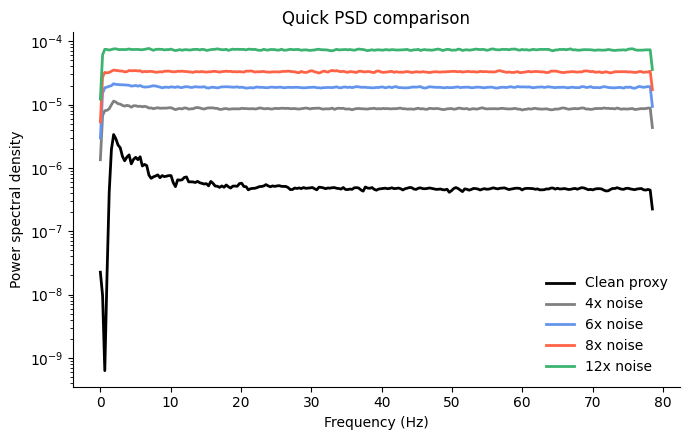

In [31]:
movies = [movie_clean_proxy, movie_4x, movie_6x, movie_8x, movie_12x]
movies_1 = [movie_noisy, movie_4x, movie_6x, movie_8x, movie_12x]
names = ["Clean proxy", "4x noise", "6x noise", "8x noise", "12x noise"]

# 1) Basic summary stats
summarize_movie_set(movies, names)

# 2) Difference relative to clean proxy
compare_movies_to_reference(movie_clean_proxy, movies[1:], names[1:])

# 3) One matched frame
plot_matched_frame_comparison(
    movies_1,
    names,
    frame_index=movie_clean_proxy.shape[0] // 2,
    shared_scale=True,
    percentile_clip=(1, 99),
)
plt.show()

# 5) PSD sanity check
quick_psd_check(
    movies,
    names,
    fps=157,
    mask=None,      # replace with cortex mask if you have one
    fmax=80,
    nperseg=1024,
    noverlap=256,
    max_pixels=5000,
)
plt.show()

In [37]:
def per_frame_correlation(clean_mov: np.ndarray, test_mov: np.ndarray) -> np.ndarray:
    """
    Compute Pearson correlation per frame between a reference movie and a test movie.

    Parameters
    ----------
    clean_mov : np.ndarray
        Reference movie with shape (T, H, W) or (H, W, T).
    test_mov : np.ndarray
        Test movie with shape matching `clean_mov`.

    Returns
    -------
    corr_t : np.ndarray
        Per-frame Pearson correlation, shape (T,).

    Notes
    -----
    Each frame is flattened to 1D before correlation is computed.
    Frames with zero variance in either movie are assigned NaN.
    """
    clean_mov = _to_THW(clean_mov)
    test_mov = _to_THW(test_mov)

    if clean_mov.shape != test_mov.shape:
        raise ValueError(f"Shape mismatch: clean {clean_mov.shape} vs test {test_mov.shape}")

    T = clean_mov.shape[0]
    corr_t = np.empty(T, dtype=float)

    for t in range(T):
        c = clean_mov[t].ravel().astype(np.float64, copy=False)
        x = test_mov[t].ravel().astype(np.float64, copy=False)

        valid = np.isfinite(c) & np.isfinite(x)
        c = c[valid]
        x = x[valid]

        if c.size < 2 or np.std(c) == 0 or np.std(x) == 0:
            corr_t[t] = np.nan
        else:
            corr_t[t] = np.corrcoef(c, x)[0, 1]

    return corr_t


def evaluate_single_semi_synthetic_movie(
    clean_mov: np.ndarray,
    corrupted_mov: np.ndarray,
    denoise_fn,
    *,
    data_range: float | None = None,
    clip: tuple[float, float] | None = None,
):
    """
    Denoise one corrupted movie and compare both the corrupted input and denoised
    output to the clean reference movie.

    Parameters
    ----------
    clean_mov : np.ndarray
        Pseudo-ground-truth movie.
    corrupted_mov : np.ndarray
        Corrupted movie to denoise and evaluate.
    denoise_fn : callable
        Function that takes a movie and returns a denoised movie.
    data_range : float or None, optional
        Data range used for PSNR/SSIM. If None, estimated robustly from clean movie.
    clip : tuple[float, float] or None, optional
        If provided, clip denoised output to this range before metric computation.

    Returns
    -------
    result : dict
        Dictionary containing input/output movies, per-frame metrics, and summary metrics.
    """
    clean_mov = _to_THW(clean_mov)
    corrupted_mov = _to_THW(corrupted_mov)

    if clean_mov.shape != corrupted_mov.shape:
        raise ValueError(f"Shape mismatch: clean {clean_mov.shape} vs corrupted {corrupted_mov.shape}")

    if data_range is None:
        lo = float(np.nanpercentile(clean_mov, 0.1))
        hi = float(np.nanpercentile(clean_mov, 99.9))
        data_range = max(hi - lo, 1e-12)

    denoised_mov = denoise_fn(corrupted_mov)

    if clip is not None:
        denoised_mov = np.clip(denoised_mov, clip[0], clip[1])

    # Per-frame metrics: corrupted input vs clean
    psnr_in_t, ssim_in_t = per_frame_psnr_ssim(clean_mov, corrupted_mov, data_range=data_range)
    lfd_in_t = per_frame_lfd(clean_mov, corrupted_mov)
    corr_in_t = per_frame_correlation(clean_mov, corrupted_mov)

    # Per-frame metrics: denoised output vs clean
    psnr_out_t, ssim_out_t = per_frame_psnr_ssim(clean_mov, denoised_mov, data_range=data_range)
    lfd_out_t = per_frame_lfd(clean_mov, denoised_mov)
    corr_out_t = per_frame_correlation(clean_mov, denoised_mov)

    result = {
        "clean_movie": clean_mov,
        "corrupted_movie": corrupted_mov,
        "denoised_movie": denoised_mov,
        "data_range_used": float(data_range),

        "psnr_in_t": psnr_in_t,
        "psnr_out_t": psnr_out_t,
        "ssim_in_t": ssim_in_t,
        "ssim_out_t": ssim_out_t,
        "lfd_in_t": lfd_in_t,
        "lfd_out_t": lfd_out_t,
        "corr_in_t": corr_in_t,
        "corr_out_t": corr_out_t,
    }

    # Mean ± SEM summaries
    for key in ["psnr", "ssim", "lfd", "corr"]:
        in_vals = result[f"{key}_in_t"]
        out_vals = result[f"{key}_out_t"]

        in_vals = in_vals[np.isfinite(in_vals)]
        out_vals = out_vals[np.isfinite(out_vals)]

        result[f"{key}_in_mean"], result[f"{key}_in_sem"] = mean_and_sem(in_vals)
        result[f"{key}_out_mean"], result[f"{key}_out_sem"] = mean_and_sem(out_vals)

    return result


def evaluate_semi_synthetic_set(
    clean_mov: np.ndarray,
    corrupted_movies: dict,
    denoise_fn,
    *,
    data_range: float | None = None,
    clip: tuple[float, float] | None = None,
):
    """
    Evaluate a set of semi-synthetic corrupted movies against the same clean reference.

    Parameters
    ----------
    clean_mov : np.ndarray
        Pseudo-ground-truth movie.
    corrupted_movies : dict
        Dictionary mapping condition names to corrupted movies, e.g.
        {"2x": movie_2x, "4x": movie_4x, "8x": movie_8x}
    denoise_fn : callable
        Function that takes a movie and returns a denoised movie.
    data_range : float or None, optional
        Data range used for PSNR/SSIM. If None, estimated from clean movie.
    clip : tuple[float, float] or None, optional
        Optional clipping range applied to denoised outputs.

    Returns
    -------
    results : dict
        Dictionary keyed by condition name. Each value is the output of
        `evaluate_single_semi_synthetic_movie`.
    """
    results = {}

    if data_range is None:
        lo = float(np.nanpercentile(clean_mov, 0.1))
        hi = float(np.nanpercentile(clean_mov, 99.9))
        data_range = max(hi - lo, 1e-12)

    for condition, corrupted_mov in corrupted_movies.items():
        print(f"Evaluating {condition}...")
        results[condition] = evaluate_single_semi_synthetic_movie(
            np.nan_to_num(clean_mov),
            np.nan_to_num(corrupted_mov),
            denoise_fn=denoise_fn,
            data_range=data_range,
            clip=clip,
        )

    return results


def make_semi_synthetic_summary_table(results: dict) -> dict:
    """
    Convert semi-synthetic evaluation results into a compact summary dictionary.

    Parameters
    ----------
    results : dict
        Output of `evaluate_semi_synthetic_set`.

    Returns
    -------
    summary : dict
        Dictionary of arrays convenient for plotting.
    """
    conditions = list(results.keys())

    summary = {
        "conditions": conditions,

        "psnr_in_mean": [],
        "psnr_out_mean": [],
        "psnr_in_sem": [],
        "psnr_out_sem": [],

        "ssim_in_mean": [],
        "ssim_out_mean": [],
        "ssim_in_sem": [],
        "ssim_out_sem": [],

        "lfd_in_mean": [],
        "lfd_out_mean": [],
        "lfd_in_sem": [],
        "lfd_out_sem": [],

        "corr_in_mean": [],
        "corr_out_mean": [],
        "corr_in_sem": [],
        "corr_out_sem": [],
    }

    for condition in conditions:
        r = results[condition]

        for key in ["psnr", "ssim", "lfd", "corr"]:
            summary[f"{key}_in_mean"].append(r[f"{key}_in_mean"])
            summary[f"{key}_out_mean"].append(r[f"{key}_out_mean"])
            summary[f"{key}_in_sem"].append(r[f"{key}_in_sem"])
            summary[f"{key}_out_sem"].append(r[f"{key}_out_sem"])

    for k, v in summary.items():
        if isinstance(v, list) and k != "conditions":
            summary[k] = np.asarray(v, dtype=float)

    return summary


def print_semi_synthetic_summary(results: dict):
    """
    Print a compact summary of semi-synthetic validation metrics.
    """
    for condition, r in results.items():
        print(condition)
        print(f"  PSNR: input = {r['psnr_in_mean']:.4f}, output = {r['psnr_out_mean']:.4f}")
        print(f"  SSIM: input = {r['ssim_in_mean']:.4f}, output = {r['ssim_out_mean']:.4f}")
        print(f"  LFD:  input = {r['lfd_in_mean']:.4f}, output = {r['lfd_out_mean']:.4f}")
        print(f"  Corr: input = {r['corr_in_mean']:.4f}, output = {r['corr_out_mean']:.4f}")
        print()


def plot_semi_synthetic_metrics(summary: dict, title: str | None = None):
    """
    Plot semi-synthetic validation metrics across corruption levels.

    Panels:
      1) PSNR
      2) SSIM
      3) LFD
      4) Correlation

    Parameters
    ----------
    summary : dict
        Output of `make_semi_synthetic_summary_table`.
    title : str or None, optional
        Figure title.

    Returns
    -------
    fig, axes
    """
    conditions = summary["conditions"]
    x = np.arange(len(conditions))

    fig, axes = plt.subplots(1, 4, figsize=(16, 4), constrained_layout=True)

    metric_specs = [
        ("psnr", "PSNR (dB)"),
        ("ssim", "SSIM"),
        ("lfd", "LFD"),
        ("corr", "Correlation"),
    ]

    for ax, (metric, ylabel) in zip(axes, metric_specs):
        ax.plot(x, summary[f"{metric}_in_mean"], "o-", color="grey", label="Input")
        ax.plot(x, summary[f"{metric}_out_mean"], "o-", color="cornflowerblue", label="LESS-denoised")

        ax.fill_between(
            x,
            summary[f"{metric}_in_mean"] - summary[f"{metric}_in_sem"],
            summary[f"{metric}_in_mean"] + summary[f"{metric}_in_sem"],
            color="grey",
            alpha=0.15,
        )
        ax.fill_between(
            x,
            summary[f"{metric}_out_mean"] - summary[f"{metric}_out_sem"],
            summary[f"{metric}_out_mean"] + summary[f"{metric}_out_sem"],
            color="cornflowerblue",
            alpha=0.15,
        )

        ax.set_xticks(x)
        ax.set_xticklabels(conditions)
        ax.set_xlabel("Added noise level")
        ax.set_ylabel(ylabel)
        ax.grid(True, alpha=0.25)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

    axes[0].legend(frameon=False)

    if title is not None:
        fig.suptitle(title)

    return fig, axes


def plot_semi_synthetic_input_vs_output(summary: dict, title: str | None = None):
    """
    Make a 3-panel input-vs-output plot for PSNR, SSIM, and LFD.

    Parameters
    ----------
    summary : dict
        Output of `make_semi_synthetic_summary_table`.
    title : str or None, optional
        Figure title.

    Returns
    -------
    fig, axes
    """
    fig, axes = plt.subplots(1, 3, figsize=(12, 4), constrained_layout=True)

    metric_specs = [
        ("psnr", "Input PSNR (dB)", "Output PSNR (dB)"),
        ("ssim", "Input SSIM", "Output SSIM"),
        ("lfd", "Input LFD", "Output LFD"),
    ]

    for ax, (metric, xlabel, ylabel) in zip(axes, metric_specs):
        x = summary[f"{metric}_in_mean"]
        y = summary[f"{metric}_out_mean"]

        x0 = float(np.nanmin(x))
        x1 = float(np.nanmax(x))
        ax.plot([x0, x1], [x0, x1], "--", color="mediumpurple", alpha=0.35, linewidth=1)

        for i in range(len(x)):
            ax.annotate(
                "",
                xy=(x[i], y[i]),
                xytext=(x[i], x[i]),
                arrowprops=dict(
                    arrowstyle="-|>",
                    linestyle="--",
                    linewidth=0.9,
                    color="0.75",
                    alpha=0.8,
                    shrinkA=0,
                    shrinkB=4,
                    mutation_scale=10,
                ),
                zorder=2,
            )

        ax.plot(x, x, "o", color="mediumpurple", label="Input", zorder=3)
        ax.plot(x, y, "o", color="mediumseagreen", label="LESS-denoised", zorder=4)

        # Add condition labels
        for i, cond in enumerate(summary["conditions"]):
            ax.text(x[i], y[i], f"  {cond}", fontsize=9, va="center")

        ax.set_xlabel(xlabel)
        ax.set_ylabel(ylabel)
        ax.grid(True, alpha=0.25)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

    axes[0].legend(frameon=False)

    if title is not None:
        fig.suptitle(title)

    return fig, axes

In [40]:
corrupted_movies = {
    "2x": movie_2x,
    "4x": movie_4x,
    "6x": movie_6x,
    "8x": movie_8x,
    "12x": movie_12x
}

results = evaluate_semi_synthetic_set(
    clean_mov=movie_clean_proxy,
    corrupted_movies=corrupted_movies,
    denoise_fn=run_less_denoising,
    data_range=None,   # estimated robustly from clean movie
    clip=None,
)


summary = make_semi_synthetic_summary_table(results)

Evaluating 2x...
Evaluating 4x...
Evaluating 6x...
Evaluating 8x...
Evaluating 12x...


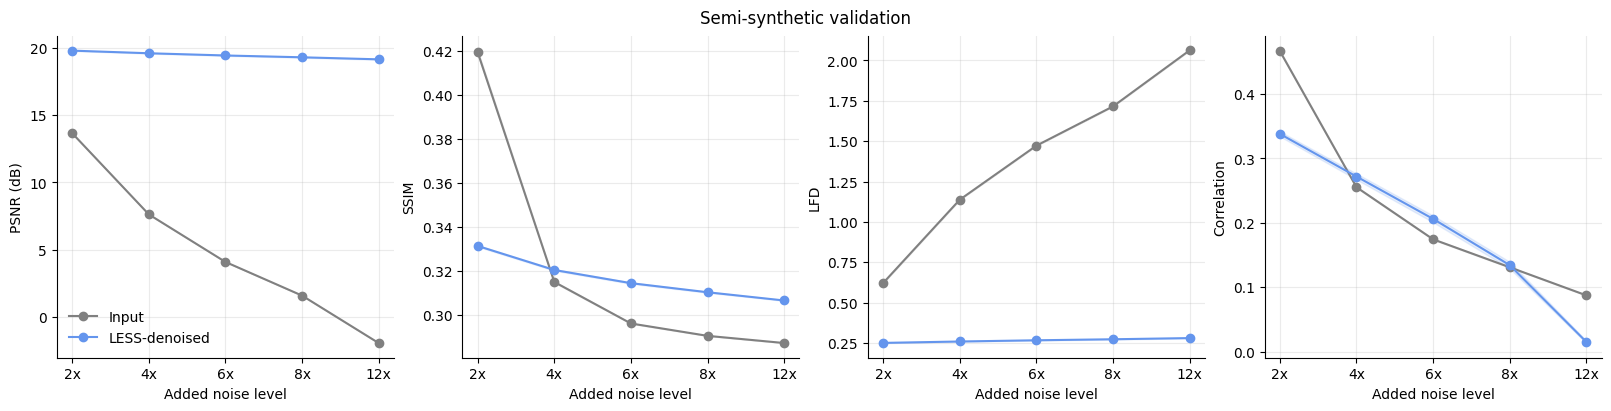

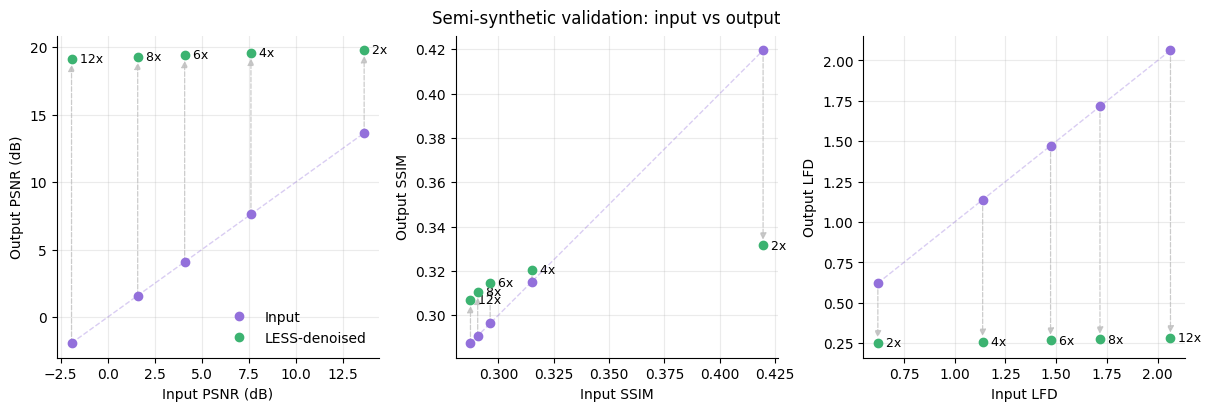

In [41]:
fig, axes = plot_semi_synthetic_metrics(
    summary,
    title="Semi-synthetic validation",
)
plt.show()

fig, axes = plot_semi_synthetic_input_vs_output(
    summary,
    title="Semi-synthetic validation: input vs output",
)
plt.show()

# SVD Spectrum Analysis

In [117]:

def prepare_shared_mask(raw_mask, movie_shape):
    """
    Prepare a shared boolean spatial mask.

    Parameters
    ----------
    raw_mask : np.ndarray
        Spatial mask of shape (y, x). Truthy values indicate valid pixels.
    movie_shape : tuple
        Shape of movie, expected (t, y, x).

    Returns
    -------
    shared_mask : np.ndarray
        Boolean mask of shape (y, x).
    """
    if raw_mask is None:
        raise ValueError("Please provide raw_mask so all conditions use the same spatial mask.")

    shared_mask = raw_mask.astype(bool)

    if shared_mask.shape != movie_shape[1:]:
        raise ValueError(
            f"raw_mask shape {shared_mask.shape} does not match movie spatial shape {movie_shape[1:]}"
        )

    return shared_mask


def masked_movie_std(movie, shared_mask):
    """
    Compute standard deviation over all in-mask pixels and timepoints.

    Parameters
    ----------
    movie : np.ndarray
        Movie of shape (t, y, x)
    shared_mask : np.ndarray
        Boolean mask of shape (y, x)

    Returns
    -------
    std_val : float
        Standard deviation over movie[:, shared_mask]
    """
    vals = movie[:, shared_mask]
    return np.std(vals)


def bandpass_movie(movie, fps, f_lo, f_hi, axis=0, order=4):
    """
    Zero-phase Butterworth bandpass filter applied along the time axis.
    """
    nyq = 0.5 * fps
    if not (0 < f_lo < f_hi < nyq):
        raise ValueError(f"Band must satisfy 0 < f_lo < f_hi < {nyq:.3f} Hz")

    b, a = sp.signal.butter(order, [f_lo / nyq, f_hi / nyq], btype="bandpass")
    return sp.signal.filtfilt(b, a, movie, axis=axis)


def movie_to_matrix(movie, shared_mask):
    """
    Convert movie (t, y, x) to matrix X of shape (pixels, time),
    keeping only pixels inside shared_mask.

    Parameters
    ----------
    movie : np.ndarray
        Movie of shape (t, y, x).
    shared_mask : np.ndarray
        Boolean mask of shape (y, x).

    Returns
    -------
    X : np.ndarray
        Matrix of shape (n_pixels_kept, t).
    """
    X = movie[:, shared_mask].T
    return X


def compute_truncated_svd(X, n_modes=200):
    """
    Compute truncated SVD of X (pixels x time).

    Returns
    -------
    U : np.ndarray
        Left singular vectors, shape (pixels, k)
    s : np.ndarray
        Singular values, shape (k,)
    Vt : np.ndarray
        Right singular vectors, shape (k, time)
    """
    n_pix, n_t = X.shape
    k = min(n_modes, min(n_pix, n_t) - 1)

    if k < 1:
        raise ValueError("Not enough pixels/timepoints to compute SVD.")

    try:
        U, s, Vt = sp.sparse.linalg.svds(X, k=k)
        order = np.argsort(s)[::-1]
        U = U[:, order]
        s = s[order]
        Vt = Vt[order, :]
    except Exception:
        U_full, s_full, Vt_full = np.linalg.svd(X, full_matrices=False)
        U = U_full[:, :k]
        s = s_full[:k]
        Vt = Vt_full[:k, :]

    return U, s, Vt


def compute_cumulative_variance(s):
    """
    Compute cumulative variance explained from singular values.
    """
    power = s**2
    return np.cumsum(power) / np.sum(power)


def reconstruct_spatial_mode_image(u_k, shared_mask, fill_value=np.nan):
    """
    Put a spatial mode back into image shape.
    """
    img = np.full(shared_mask.shape, fill_value, dtype=float)
    img[shared_mask] = u_k
    return img


def generate_gaussian_noise_movie(movie_shape, shared_mask, rng=None):
    """
    Generate Gaussian noise movie with the same shape as the real movie.

    Pixels outside shared_mask are set to zero so filtering behaves nicely.
    These pixels are discarded before SVD anyway.

    Parameters
    ----------
    movie_shape : tuple
        (t, y, x)
    shared_mask : np.ndarray
        Boolean mask of shape (y, x)
    rng : np.random.Generator or None
        Optional RNG for reproducibility.

    Returns
    -------
    noise_movie : np.ndarray
        Noise movie of shape (t, y, x)
    """
    if rng is None:
        rng = np.random.default_rng()

    noise_movie = rng.standard_normal(movie_shape)

    outside = ~shared_mask
    noise_movie[:, outside] = 0.0

    return noise_movie


def analyze_band_svd(movie,
                     fps,
                     band,
                     shared_mask,
                     n_modes=200,
                     crop_seconds=1.0,
                     target_std=None):
    """
    Optionally bandpass a movie, optionally crop edges, optionally scale to target std,
    then convert to matrix and compute SVD.

    Parameters
    ----------
    movie : np.ndarray
        Movie of shape (t, y, x)
    fps : float
        Frame rate
    band : tuple or None
        (f_lo, f_hi) for bandpass, or None for no bandpass
    shared_mask : np.ndarray
        Boolean spatial mask
    n_modes : int
        Number of modes
    crop_seconds : float
        Seconds to crop from beginning and end after filtering / preprocessing
    target_std : float or None
        If provided, scale the processed movie so its in-mask std matches this target before SVD.

    Returns
    -------
    result : dict
    """
    if band is None:
        movie_proc = movie.copy()
    else:
        f_lo, f_hi = band
        movie_proc = bandpass_movie(movie, fps, f_lo, f_hi, axis=0)

    n_crop = int(round(crop_seconds * fps))
    if 2 * n_crop >= movie_proc.shape[0]:
        raise ValueError("Cropping removes all frames. Reduce crop_seconds or use a longer movie.")

    if n_crop > 0:
        movie_proc = movie_proc[n_crop:-n_crop]

    pre_scale_std = masked_movie_std(movie_proc, shared_mask)

    scale_factor = 1.0
    if target_std is not None:
        if pre_scale_std == 0:
            raise ValueError("Processed movie has zero std inside mask; cannot scale to target_std.")
        scale_factor = target_std / pre_scale_std
        movie_proc = movie_proc * scale_factor

    post_scale_std = masked_movie_std(movie_proc, shared_mask)

    X = movie_to_matrix(movie_proc, shared_mask)
    U, s, Vt = compute_truncated_svd(X, n_modes=n_modes)
    cumvar = compute_cumulative_variance(s)

    return {
        "band": band,
        "movie_bp": movie_proc,   # keeping key name for compatibility with existing code
        "X": X,
        "U": U,
        "s": s,
        "Vt": Vt,
        "cumvar": cumvar,
        "pre_scale_std": pre_scale_std,
        "post_scale_std": post_scale_std,
        "scale_factor": scale_factor,
        "n_crop": n_crop,
    }


def analyze_all_bands(movie_noisy,
                      movie_denoised,
                      fps,
                      bands,
                      raw_mask,
                      n_modes=200,
                      random_seed=0,
                      crop_seconds=1.0):
    """
    Analyze raw, denoised, residual, and Gaussian-noise baseline across bands.

    If bands is None, perform one unfiltered analysis with no bandpass.

    Gaussian baseline is processed the same way as the real movies and then
    scaled so its in-mask std matches the raw movie in that same condition.

    Parameters
    ----------
    movie_noisy : np.ndarray
        Raw movie, shape (t, y, x)
    movie_denoised : np.ndarray
        Denoised movie, shape (t, y, x)
    fps : float
        Frame rate
    bands : dict or None
        Example:
        {
            "low": (1, 8),
            "mid": (8, 20),
            "high": (35, 60),
        }
        If None, run one unfiltered analysis.
    raw_mask : np.ndarray
        Spatial mask of shape (y, x)
    n_modes : int
        Number of SVD modes
    random_seed : int
        Seed for Gaussian baseline
    crop_seconds : float
        Seconds cropped from beginning and end after preprocessing

    Returns
    -------
    results : dict
        Nested dict: results[band_name][condition]
    """
    if movie_noisy.shape != movie_denoised.shape:
        raise ValueError("movie_noisy and movie_denoised must have the same shape.")

    shared_mask = prepare_shared_mask(raw_mask, movie_noisy.shape)

    movie_residual = movie_noisy - movie_denoised

    rng = np.random.default_rng(random_seed)
    movie_gaussian = generate_gaussian_noise_movie(movie_noisy.shape, shared_mask, rng=rng)

    # If no bands supplied, run one unfiltered condition
    if bands is None:
        bands_to_use = {"unfiltered": None}
    else:
        bands_to_use = bands

    results = {}

    for band_name, band in bands_to_use.items():
        results[band_name] = {}

        raw_result = analyze_band_svd(
            movie=movie_noisy,
            fps=fps,
            band=band,
            shared_mask=shared_mask,
            n_modes=n_modes,
            crop_seconds=crop_seconds,
            target_std=None,
        )
        raw_target_std = raw_result["post_scale_std"]

        denoised_result = analyze_band_svd(
            movie=movie_denoised,
            fps=fps,
            band=band,
            shared_mask=shared_mask,
            n_modes=n_modes,
            crop_seconds=crop_seconds,
            target_std=None,
        )

        residual_result = analyze_band_svd(
            movie=movie_residual,
            fps=fps,
            band=band,
            shared_mask=shared_mask,
            n_modes=n_modes,
            crop_seconds=crop_seconds,
            target_std=None,
        )

        gaussian_result = analyze_band_svd(
            movie=movie_gaussian,
            fps=fps,
            band=band,
            shared_mask=shared_mask,
            n_modes=n_modes,
            crop_seconds=crop_seconds,
            target_std=raw_target_std,
        )

        results[band_name]["raw"] = raw_result
        results[band_name]["denoised"] = denoised_result
        results[band_name]["residual"] = residual_result
        results[band_name]["gaussian"] = gaussian_result
        results[band_name]["shared_mask"] = shared_mask

    return results


def plot_overlaid_svd_spectra(results,
                              band_name,
                              normalize=False,
                              logy=True,
                              max_modes=None):
    """
    Plot overlaid singular value spectra.

    Parameters
    ----------
    normalize : bool
        If True, divide each spectrum by its own first singular value.
    logy : bool
        If True, use log y scale.
    """
    fig, ax = plt.subplots(figsize=(6, 4))

    conditions=("raw", "denoised", "residual", "gaussian")
    colors = {"raw": 'grey', "denoised": 'cornflowerblue', "residual": 'mediumseagreen', "gaussian": 'black'}
    ls = {"raw": '-', "denoised": '-', "residual": '-', "gaussian": ':'}

    for condition in conditions:
        s = results[band_name][condition]["s"].copy()

        if max_modes is not None:
            s = s[:max_modes]

        if normalize:
            if s[0] != 0:
                s = s / s[0]

        ax.plot(np.arange(1, len(s) + 1), s, label=condition, color=colors[condition], ls=ls[condition], lw=2)

    ax.set_xlabel("Mode index")
    ax.set_ylabel("Normalized singular value" if normalize else "Singular value")

    band = results[band_name]["raw"]["band"]
    if band is None:
        title = f"SVD spectrum"
    else:
        title = f"SVD spectrum ({band_name}: {band[0]}-{band[1]} Hz)"
    ax.set_title(title)

    if logy:
        ax.set_yscale("log")
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()


def plot_svd_spectra_row(results,
                         band_names=None,
                         normalize=False,
                         logy=True,
                         max_modes=None,
                         figsize_per_panel=(5, 4),
                         legend_loc="upper center",
                         legend_ncol=4):
    """
    Plot SVD spectra for multiple bands side-by-side in one row with a shared legend.

    Parameters
    ----------
    results : dict
        Output from analyze_all_bands().
    band_names : sequence of str or None
        Which keys from results to plot. If None, uses results.keys() in order.
    normalize : bool
        If True, divide each spectrum by its own first singular value.
    logy : bool
        If True, use log y-scale.
    max_modes : int or None
        Number of modes to display.
    figsize_per_panel : tuple
        Size per subplot as (width, height). Total width scales with number of panels.
    legend_loc : str
        Location for the shared legend.
    legend_ncol : int
        Number of legend columns.

    Returns
    -------
    fig, axes
        Matplotlib figure and axes array.
    """
    if band_names is None:
        band_names = list(results.keys())
    else:
        band_names = list(band_names)

    conditions=("raw", "denoised", "residual", "gaussian")
    colors = {"raw": 'grey', "denoised": 'cornflowerblue', "residual": 'mediumseagreen', "gaussian": 'black'}
    ls = {"raw": '-', "denoised": '-', "residual": '-', "gaussian": ':'}

    n_panels = len(band_names)
    fig_width = figsize_per_panel[0] * n_panels
    fig_height = figsize_per_panel[1]

    fig, axes = plt.subplots(1, n_panels, figsize=(fig_width, fig_height), sharey=True)

    if n_panels == 1:
        axes = [axes]

    legend_handles = None
    legend_labels = None

    for ax, band_name in zip(axes, band_names):
        for condition in conditions:
            s = results[band_name][condition]["s"].copy()

            if max_modes is not None:
                s = s[:max_modes]

            if normalize and s[0] != 0:
                s = s / s[0]

            line, = ax.plot(np.arange(1, len(s) + 1), s, label=condition, color=colors[condition], ls=ls[condition])

        band = results[band_name]["raw"]["band"]
        if band is None:
            title = f"{band_name}"
        else:
            title = f"{band_name}: {band[0]}-{band[1]} Hz"

        ax.set_title(title)
        ax.set_xlabel("Mode index")
        ax.grid(True, alpha=0.3)

        if logy:
            ax.set_yscale("log")

        if legend_handles is None:
            legend_handles, legend_labels = ax.get_legend_handles_labels()

    axes[0].set_ylabel("Normalized singular value" if normalize else "Singular value")

    fig.legend(
        legend_handles,
        legend_labels,
        loc=legend_loc,
        ncol=legend_ncol,
        frameon=True
    )

    plt.tight_layout(rect=[0, 0, 1, 0.90])
    return fig, axes


def plot_cumulative_variance(results,
                             band_name,
                             conditions=("raw", "denoised", "residual", "gaussian"),
                             max_modes=None):
    """
    Plot cumulative variance curves.
    """
    fig, ax = plt.subplots(figsize=(6, 4))

    for condition in conditions:
        cumvar = results[band_name][condition]["cumvar"]
        if max_modes is not None:
            cumvar = cumvar[:max_modes]
        ax.plot(np.arange(1, len(cumvar) + 1), cumvar, label=condition)

    band = results[band_name]["raw"]["band"]
    if band is None:
        title = f"Cumulative variance ({band_name})"
    else:
        title = f"Cumulative variance ({band_name}: {band[0]}-{band[1]} Hz)"

    ax.set_xlabel("Mode index")
    ax.set_ylabel("Cumulative variance explained")
    ax.set_title(title)
    ax.set_ylim(0, 1.02)
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()


def plot_spatial_modes(results,
                       band_name,
                       condition,
                       mode_indices=(1, 2, 5, 10, 25, 50),
                       cmap="seismic"):
    """
    Plot selected spatial SVD modes as images.
    """
    res = results[band_name][condition]
    U = res["U"]
    shared_mask = results[band_name]["shared_mask"]

    n = len(mode_indices)
    fig, axes = plt.subplots(1, n, figsize=(3 * n, 3))

    if n == 1:
        axes = [axes]

    for ax, mode_idx in zip(axes, mode_indices):
        k = mode_idx - 1
        if k >= U.shape[1]:
            ax.axis("off")
            continue

        img = reconstruct_spatial_mode_image(U[:, k], shared_mask, fill_value=np.nan)
        vmax = np.nanmax(np.abs(img))
        ax.imshow(img, cmap=cmap, vmin=-vmax, vmax=vmax)
        ax.set_title(f"Mode {mode_idx}")
        ax.axis("off")

    fig.suptitle(f"Spatial modes: {condition}, {band_name}", y=1.02)
    plt.tight_layout()


def plot_temporal_traces(results,
                         band_name,
                         condition,
                         mode_indices=(1, 2, 5, 10, 25, 50),
                         fps=None,
                         scale_by_sigma=True):
    """
    Plot temporal traces for selected modes.
    """
    res = results[band_name][condition]
    s = res["s"]
    Vt = res["Vt"]
    n_t = Vt.shape[1]

    if fps is None:
        x = np.arange(n_t)
        xlabel = "Frame"
    else:
        x = np.arange(n_t) / fps
        xlabel = "Time (s)"

    fig, axes = plt.subplots(len(mode_indices), 1, figsize=(8, 1.6 * len(mode_indices)), sharex=True)

    if len(mode_indices) == 1:
        axes = [axes]

    for ax, mode_idx in zip(axes, mode_indices):
        k = mode_idx - 1
        if k >= Vt.shape[0]:
            ax.axis("off")
            continue

        trace = Vt[k]
        if scale_by_sigma:
            trace = s[k] * trace

        ax.plot(x, trace, lw=1)
        ax.set_ylabel(f"M{mode_idx}")
        ax.grid(True, alpha=0.3)

    axes[-1].set_xlabel(xlabel)
    fig.suptitle(f"Temporal traces: {condition}, {band_name}", y=1.02)
    plt.tight_layout()


def summarize_band_stds(results, band_name):
    """
    Print in-mask stds after bandpass/crop (and scaling for Gaussian).
    """
    print(f"\nBand: {band_name}")
    for condition in ("raw", "denoised", "residual", "gaussian"):
        r = results[band_name][condition]
        print(
            f"  {condition:9s} "
            f"pre_std={r['pre_scale_std']:.6g}, "
            f"post_std={r['post_scale_std']:.6g}, "
            f"scale={r['scale_factor']:.6g}"
        )


def summarize_svd(results,
                  band_name,
                  conditions=("raw", "denoised", "residual", "gaussian"),
                  checkpoints=(5, 10, 25, 50, 100, 200)):
    """
    Print cumulative variance at selected mode counts.
    """
    band = results[band_name]["raw"]["band"]
    if band is None:
        print(f"\nCondition: {band_name} (unfiltered)")
    else:
        print(f"\nBand: {band_name} ({band[0]}-{band[1]} Hz)")

    for condition in conditions:
        cumvar = results[band_name][condition]["cumvar"]
        vals = []
        for n in checkpoints:
            idx = min(n, len(cumvar)) - 1
            vals.append(f"{n}: {cumvar[idx]:.3f}")
        print(f"  {condition:9s} -> " + " | ".join(vals))

In [93]:
bands = {
    "low": (1.5, 8),
    "mid": (8, 20),
    "high": (35, 60),
}

results = analyze_all_bands(
    movie_noisy=movie_noisy[:2000],
    movie_denoised=movie_denoised[:2000],
    fps=157,
    bands=bands,
    raw_mask=mask,
    n_modes=200,
    random_seed=0,
)

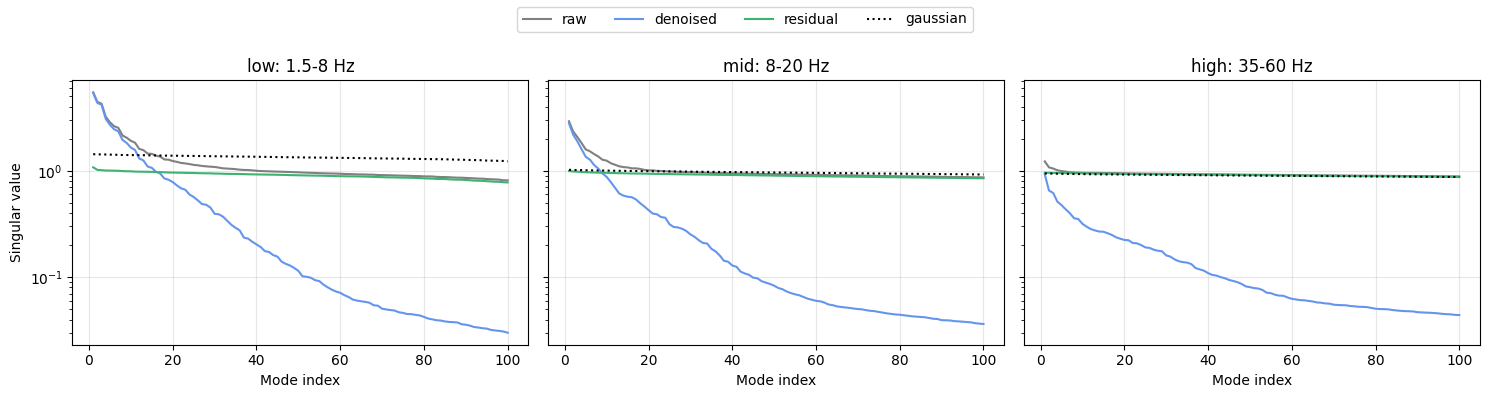

In [118]:
plot_svd_spectra_row(
    results,
    band_names=list(bands.keys()),
    normalize=False,
    logy=True,
    max_modes=100,
)
plt.show()

In [ ]:
mode_list = (1, 2, 5, 10, 25, 50)

for band_name in bands:
    for condition in ("raw", "denoised", "residual", "gaussian"):
        plot_spatial_modes(results, band_name, condition, mode_indices=mode_list)
        plt.show()
        plot_temporal_traces(results, band_name, condition, mode_indices=mode_list, fps=157)
        plt.show()

In [73]:
results_unfiltered = analyze_all_bands(
    movie_noisy=movie_noisy[:1000],
    movie_denoised=movie_denoised[:1000],
    fps=157,
    bands=None,
    raw_mask=mask,
    n_modes=100,
    random_seed=0,
    crop_seconds=0.0,
)

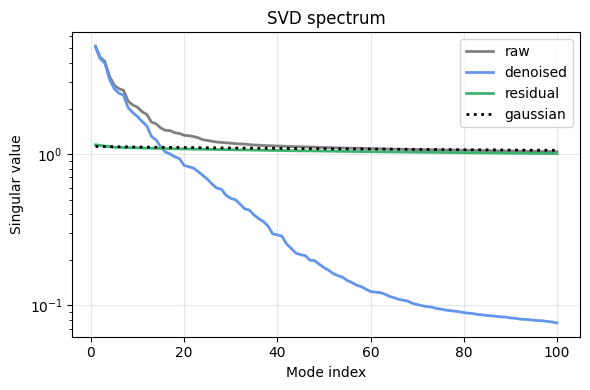

In [119]:
plot_overlaid_svd_spectra(
    results_unfiltered,
    "unfiltered",
    normalize=False,
    logy=True,
    max_modes=100,
)
plt.show()